# F3 - Autocorreção final das saídas Nile ainda inválidas

Este notebook executa a etapa complementar de **autocorreção final** prevista para as saídas que permaneceram sintaticamente inválidas após a primeira autocorreção. Ele não cria uma nova estratégia experimental e não altera as definições de F3-B, F3-C, F3-D ou F3-E.

A entrada da etapa é formada pelos resultados consolidados após a primeira autocorreção:

```text
F3-B: tradução direta após a primeira autocorreção
F3-C: NL → IR → Nile, variante primeira_ac
F3-D: NL + R3 → Nile, variante primeira_ac
F3-E: NL + R1 → IR; IR + R2 → Nile, variante primeira_ac
```

A F3-A não é processada novamente. Suas saídas inválidas já originaram a F3-B; incluí-las nesta etapa duplicaria as mesmas traduções diretas e confundiria a comparação entre primeira e segunda autocorreções.

A regra de elegibilidade é estrita:

```text
PSR = 0 após a primeira autocorreção
```

Para cada registro elegível, o notebook reutiliza o contexto compatível com sua estratégia de origem e solicita uma segunda correção da Nile. As saídas que já possuem `PSR=1` são preservadas sem nova chamada ao modelo.

A cadeia operacional é:

```text
F3-modelo + F3-B + F3-C + F3-D + F3-E
                    ↓
auditoria dos pacotes e dos 1.850 resultados de entrada
                    ↓
seleção dos registros com PSR = 0
                    ↓
montagem dos prompts específicos por estratégia
                    ↓
segunda autocorreção Nile com checkpoint
                    ↓
reavaliação por PSR, EM, ED, NED, SLA-S e SLA-F
                    ↓
comparação antes × depois da autocorreção final
                    ↓
f3_autocorrecao_final.zip
```

Com os pacotes oficiais atualmente congelados, são esperados 1.850 registros de entrada e 1.053 chamadas de autocorreção final:

| Estratégia de origem | Registros consolidados | Elegíveis esperados |
|---|---:|---:|
| F3-B | 500 | 372 |
| F3-C | 450 | 236 |
| F3-D | 450 | 256 |
| F3-E | 450 | 189 |
| **Total** | **1.850** | **1.053** |

O notebook está organizado em dez blocos:

| Bloco | Etapa | Resultado principal |
|---:|---|---|
| 1 | Configuração geral | Ambiente, caminhos, funções e parâmetros fixos |
| 2 | Localização e auditoria | Cadeia compatível de F3-modelo e F3-B/C/D/E |
| 3 | Carga dos resultados | 1.850 registros validados e métricas reproduzidas |
| 4 | Plano de autocorreção | 1.053 registros elegíveis identificados |
| 5 | Modelo aluno | Qwen2.5-1.5B-Instruct carregado uma única vez |
| 6 | Prompts | Prompts auditados, tokenizados e sem vazamento |
| 7 | Inferência | Segunda autocorreção incremental com checkpoint |
| 8 | Consolidação | 1.850 resultados finais e comparação pareada |
| 9 | Análises e gráficos | Resumos por estratégia, método, `k` e fold |
| 10 | Empacotamento | Manifesto, hashes e `f3_autocorrecao_final.zip` |

## Bloco 1 - Configuração geral

### Objetivo

Este bloco fixa o ambiente da autocorreção final. Ele concentra parâmetros, diretórios, nomes dos artefatos, padrões de exibição e funções de leitura e escrita.

### Escopo congelado

A etapa processa somente F3-B, F3-C, F3-D e F3-E. A variante de entrada de F3-C, F3-D e F3-E é `primeira_ac`; a F3-B já representa a primeira autocorreção da tradução direta.

### Quantidades esperadas

São definidos 1.850 registros consolidados e 1.053 registros elegíveis, distribuídos por estratégia conforme os resultados oficiais já produzidos. Essas quantidades funcionam como barreiras contra a seleção acidental de versões diferentes dos pacotes.

### Retomada

Cada geração é persistida imediatamente em checkpoint. Um registro anterior só é reutilizado quando o ID da execução e o fingerprint completo permanecem compatíveis.

### Resultado esperado

O bloco não produz tabelas. Ao final, todos os caminhos e auxiliares estarão disponíveis para localizar e auditar as entradas.

In [1]:
# ----------------------------------------------------------
# 1.1 Importação das bibliotecas principais
# ----------------------------------------------------------

import gc
import gzip
import hashlib
import importlib.metadata
import json
import os
import platform
import re
import shutil
import sys
import time
import traceback
import warnings
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, display


# ----------------------------------------------------------
# 1.2 Identificação da etapa complementar
# ----------------------------------------------------------

FASE = "F3-autocorrecao-final"
NOME_ETAPA = "Autocorreção final das saídas Nile ainda inválidas"
DATASET = "CAMPI"

ESTRATEGIAS_ORIGEM = ["F3-B", "F3-C", "F3-D", "F3-E"]
VARIANTE_ORIGEM = {
    "F3-B": "primeira_ac",
    "F3-C": "primeira_ac",
    "F3-D": "primeira_ac",
    "F3-E": "primeira_ac",
}
VARIANTE_FINAL = "autocorrecao_final"

TOTAL_EXEMPLOS_ESPERADO = 50
TOTAL_FOLDS_ESPERADO = 5
TOTAL_REGISTROS_BASE_ESPERADO = 1850
ELEGIVEIS_ESPERADOS = {
    "F3-B": 372,
    "F3-C": 236,
    "F3-D": 256,
    "F3-E": 189,
}
TOTAL_ELEGIVEIS_ESPERADO = sum(ELEGIVEIS_ESPERADOS.values())
SEED_GLOBAL = 42

METRICAS = ["psr", "em", "ed", "ned", "sla_s", "sla_f"]
ROTULOS_METRICAS = {
    "psr": "PSR",
    "em": "EM",
    "ed": "ED",
    "ned": "NED",
    "sla_s": "SLA-S",
    "sla_f": "SLA-F",
}

METODO_ZERO_SHOT = "zero_shot"
METODOS_FEWSHOT = [
    "random_seed42",
    "lexical_tfidf",
    "semantic_embeddings",
]
ORDEM_METODOS_EXIBICAO = [METODO_ZERO_SHOT, *METODOS_FEWSHOT]
ORDEM_METODOS_MAPA = {
    metodo: posicao
    for posicao, metodo in enumerate(ORDEM_METODOS_EXIBICAO)
}
ROTULOS_METODOS = {
    METODO_ZERO_SHOT: "Nenhum (zero-shot)",
    "random_seed42": "Aleatória",
    "lexical_tfidf": "Lexical",
    "semantic_embeddings": "Semântica",
}
CORES_METODOS = {
    METODO_ZERO_SHOT: "#d62728",
    "random_seed42": "#f2c94c",
    "lexical_tfidf": "#2ca02c",
    "semantic_embeddings": "#1f77b4",
}

DEMO_FORMAT_BY_STRATEGY = {
    "F3-B": "A",
    "F3-C": "C_IR_NILE",
    "F3-D": "D_R3",
    "F3-E": "E_R2",
}


# ----------------------------------------------------------
# 1.3 Modelo aluno e geração
# ----------------------------------------------------------

MODELO_ALUNO = "Qwen2.5-1.5B-Instruct"
MODELO_HF_ID = "Qwen/Qwen2.5-1.5B-Instruct"
MODELO_LOCAL_HINTS = ["qwen2.5", "1.5b", "instruct"]
USAR_CUDA = True
PERMITIR_DOWNLOAD_HUGGINGFACE = True
MAX_NEW_TOKENS_NILE = 256
DO_SAMPLE = False
LIMITE_CONTEXTO_FALLBACK = 32768


# ----------------------------------------------------------
# 1.4 Controle de execução
# ----------------------------------------------------------

REINICIAR_EXECUCAO = False
MODO_TESTE_RAPIDO = False
TOTAL_REGISTROS_TESTE_RAPIDO = 8
INTERVALO_SNAPSHOT = 25


# ----------------------------------------------------------
# 1.5 Diretórios principais
# ----------------------------------------------------------

KAGGLE_INPUT = Path("/kaggle/input")
RAIZ_TRABALHO = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path("/mnt/data/f3_autocorrecao_final_working")
)

ETAPA_DIR = RAIZ_TRABALHO / "f3_autocorrecao_final"
ENTRADAS_DIR = ETAPA_DIR / "entradas"
INTERMEDIARIOS_DIR = ETAPA_DIR / "intermediarios"
GRAFICOS_DIR = ETAPA_DIR / "graficos"
PACOTE_DIR = ETAPA_DIR / "pacote"

if REINICIAR_EXECUCAO and ETAPA_DIR.exists():
    shutil.rmtree(ETAPA_DIR)

for diretorio in [
    ETAPA_DIR,
    ENTRADAS_DIR,
    INTERMEDIARIOS_DIR,
    GRAFICOS_DIR,
    PACOTE_DIR,
]:
    diretorio.mkdir(parents=True, exist_ok=True)


# ----------------------------------------------------------
# 1.6 Caminhos dos artefatos
# ----------------------------------------------------------

CONFIG_PATH = PACOTE_DIR / "f3_autocorrecao_final_config.json"
INPUT_AUDIT_PATH = PACOTE_DIR / "f3_autocorrecao_final_input_audit.csv"
SOURCE_SUMMARY_PATH = PACOTE_DIR / "f3_autocorrecao_final_source_summary.csv"
BASELINE_PATH = PACOTE_DIR / "f3_autocorrecao_final_baseline.jsonl.gz"
PLANO_PATH = PACOTE_DIR / "f3_autocorrecao_final_plano.csv"
PROMPTS_PATH = PACOTE_DIR / "f3_autocorrecao_final_prompts.jsonl.gz"
TOKEN_AUDIT_PATH = PACOTE_DIR / "f3_autocorrecao_final_token_audit.csv"
PROMPT_AUDIT_PATH = PACOTE_DIR / "f3_autocorrecao_final_prompt_audit.csv"
CHECKPOINT_PATH = INTERMEDIARIOS_DIR / "f3_autocorrecao_final_checkpoint.jsonl"
GENERATIONS_PATH = PACOTE_DIR / "f3_autocorrecao_final_generations.jsonl.gz"
RESULTS_JSONL_PATH = PACOTE_DIR / "f3_autocorrecao_final_results.jsonl"
RESULTS_CSV_PATH = PACOTE_DIR / "f3_autocorrecao_final_results.csv"
SUMMARY_PATH = PACOTE_DIR / "f3_autocorrecao_final_summary.csv"
SUMMARY_FOLD_PATH = PACOTE_DIR / "f3_autocorrecao_final_summary_by_fold.csv"
COMPARISON_PATH = PACOTE_DIR / "f3_autocorrecao_final_comparison.csv"
GAINS_PATH = PACOTE_DIR / "f3_autocorrecao_final_gains.csv"
INVALID_PATH = PACOTE_DIR / "f3_autocorrecao_final_invalid_outputs.csv"
ANALYSIS_EXAMPLE_PATH = PACOTE_DIR / "f3_autocorrecao_final_analysis_by_example.csv"
EXECUTION_AUDIT_PATH = PACOTE_DIR / "f3_autocorrecao_final_execution_audit.csv"
STRATEGY_COMPARISON_PATH = (
    PACOTE_DIR
    / "f3_autocorrecao_final_comparison_by_strategy.csv"
)
RECOVERY_SUMMARY_PATH = (
    PACOTE_DIR
    / "f3_autocorrecao_final_recovery_by_strategy.csv"
)
MANIFEST_PATH = PACOTE_DIR / "manifest.json"
ZIP_FINAL_PATH = RAIZ_TRABALHO / "f3_autocorrecao_final.zip"


# ----------------------------------------------------------
# 1.7 Funções de serialização, hashing e empacotamento
# ----------------------------------------------------------

def canonical_json(data):
    return json.dumps(
        data,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    )


def sha256_text(text):
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()


def sha256_file(path, chunk_size=1024 * 1024):
    path = Path(path)
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as handle:
        return json.load(handle)


def json_safe(data):
    if isinstance(data, dict):
        return {str(key): json_safe(value) for key, value in data.items()}
    if isinstance(data, (list, tuple)):
        return [json_safe(value) for value in data]
    if isinstance(data, np.generic):
        return json_safe(data.item())
    if isinstance(data, float) and not np.isfinite(data):
        return None
    return data


def write_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(
            json_safe(data),
            handle,
            ensure_ascii=False,
            indent=2,
            allow_nan=False,
        )
        handle.write("\n")


def read_jsonl(path):
    path = Path(path)
    records = []
    if not path.is_file():
        return records
    opener = gzip.open if path.suffix == ".gz" else open
    with opener(path, "rt", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"JSONL inválido em {path}, linha {line_number}: {exc}"
                ) from exc
            if not isinstance(record, dict):
                raise TypeError(
                    f"Registro não é objeto em {path}, linha {line_number}."
                )
            records.append(record)
    return records


def write_jsonl(records, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        for record in records:
            handle.write(
                json.dumps(
                    json_safe(record),
                    ensure_ascii=False,
                    separators=(",", ":"),
                )
            )
            handle.write("\n")


def append_jsonl(record, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as handle:
        handle.write(
            json.dumps(
                json_safe(record),
                ensure_ascii=False,
                separators=(",", ":"),
            )
        )
        handle.write("\n")
        handle.flush()
        os.fsync(handle.fileno())


def write_jsonl_gz(records, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with gzip.open(path, "wt", encoding="utf-8") as handle:
        for record in records:
            handle.write(
                json.dumps(
                    json_safe(record),
                    ensure_ascii=False,
                    separators=(",", ":"),
                )
            )
            handle.write("\n")


def package_version(name):
    try:
        return importlib.metadata.version(name)
    except Exception:
        return None


def clean_runtime_caches(root):
    root = Path(root)
    for cache in root.rglob("__pycache__"):
        if cache.is_dir():
            shutil.rmtree(cache, ignore_errors=True)
    for suffix in ("*.pyc", "*.pyo"):
        for item in root.rglob(suffix):
            item.unlink(missing_ok=True)


# ----------------------------------------------------------
# 1.8 Padrão visual das tabelas
# ----------------------------------------------------------

CONTADOR_TABELAS = 0

ROTULOS_COLUNAS = {
    "phase": "fase",
    "strategy": "estratégia",
    "variant": "variante",
    "fold": "fold",
    "id": "ID",
    "k": "k",
    "selection_method": "método de seleção",
    "selection_label": "rótulo do método",
    "records": "registros",
    "eligible": "elegíveis",
    "preserved": "preservados",
    "requested": "solicitados",
    "generated": "gerados",
    "reused": "reutilizados",
    "stale_ignored": "incompatíveis ignorados",
    "prompt_tokens": "tokens do prompt",
    "generated_tokens": "tokens gerados",
    "elapsed_seconds": "tempo decorrido",
    "elapsed_autocorrection_seconds": "tempo médio da autocorreção final",
    "syntax_valid": "validade sintática",
    "autocorrection_applied": "autocorreção final aplicada",
    "eligible_for_final_autocorrection": "elegível à autocorreção final",
    "psr": "PSR",
    "em": "EM",
    "ed": "ED",
    "ned": "NED",
    "sla_s": "SLA-S",
    "sla_f": "SLA-F",
    "psr_before": "PSR antes",
    "psr_after": "PSR depois",
    "syntax_recovered": "validade sintática recuperada",
    "syntax_recovery_rate": "taxa de recuperação sintática",
    "syntax_valid_before": "validade sintática antes",
    "syntax_valid_after": "validade sintática depois",
    "em_before": "EM antes",
    "em_after": "EM depois",
    "ed_before": "ED antes",
    "ed_after": "ED depois",
    "ned_before": "NED antes",
    "ned_after": "NED depois",
    "sla_s_before": "SLA-S antes",
    "sla_s_after": "SLA-S depois",
    "sla_f_before": "SLA-F antes",
    "sla_f_after": "SLA-F depois",
    "file": "arquivo",
    "located_file": "arquivo localizado",
    "source_type": "tipo de fonte",
    "audit_mode": "modo de auditoria",
    "status": "status",
    "item": "item",
    "value": "valor",
    "size_bytes": "tamanho em bytes",
    "sha256": "SHA-256",
}


def _display_value(value):
    if isinstance(value, (bool, np.bool_)):
        return "sim" if value else "não"
    if value is None:
        return "-"
    try:
        if not isinstance(value, str) and pd.isna(value):
            return "-"
    except Exception:
        pass
    return value


def formatar_duracao(segundos):
    if segundos is None:
        return "-"
    try:
        if pd.isna(segundos):
            return "-"
    except Exception:
        pass
    total = max(0, int(round(float(segundos))))
    horas, restante = divmod(total, 3600)
    minutos, segundos_restantes = divmod(restante, 60)
    if horas > 0:
        return f"{horas:02d}h {minutos:02d}min {segundos_restantes:02d}s"
    if minutos > 0:
        return f"{minutos:02d}min {segundos_restantes:02d}s"
    return f"{segundos_restantes:02d}s"


def exibir_tabela(df, titulo=None, altura_px=None, mostrar_indice=False):
    global CONTADOR_TABELAS
    if df is None:
        print("Tabela não disponível.")
        return
    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)
    if df.empty:
        print("Tabela vazia.")
        return

    CONTADOR_TABELAS += 1
    tabela = df.copy()
    for coluna in tabela.columns:
        if str(coluna).endswith("_seconds"):
            tabela[coluna] = tabela[coluna].apply(formatar_duracao)
        else:
            tabela[coluna] = tabela[coluna].apply(_display_value)
    tabela = tabela.rename(
        columns={
            coluna: ROTULOS_COLUNAS.get(
                coluna,
                str(coluna).replace("_", " "),
            )
            for coluna in tabela.columns
        }
    )

    titulo_final = f"Tabela {CONTADOR_TABELAS}"
    if titulo:
        titulo_final += f". {titulo}"

    html_tabela = tabela.to_html(
        escape=True,
        index=mostrar_indice,
        border=0,
        justify="left",
        classes="tabela_saida",
    )
    altura_css = (
        "overflow-y: visible;"
        if altura_px is None
        else f"max-height: {altura_px}px; overflow-y: auto;"
    )

    display(HTML(f"""
    <div style="font-weight:600;font-size:15px;margin:8px 0 6px;color:#f1f1f1;">
        {titulo_final}
    </div>
    <div class="container_tabela_saida" style="display:inline-block;max-width:100%;overflow-x:auto;{altura_css}border:none;margin:8px 0 12px;">
        <style>
            .container_tabela_saida table.tabela_saida {{
                border-collapse:collapse !important;
                table-layout:auto !important;
                width:auto !important;
                font-family:Arial,sans-serif !important;
                font-size:13px !important;
                background:#111 !important;
                color:#f1f1f1 !important;
                border:1px solid #555 !important;
            }}
            .container_tabela_saida table.tabela_saida thead th {{
                position:sticky !important;
                top:0 !important;
                z-index:2 !important;
                background:#2b2b2b !important;
                color:#fff !important;
                padding:7px !important;
                text-align:left !important;
                white-space:nowrap !important;
                border:1px solid #777 !important;
                border-bottom:2px solid #888 !important;
            }}
            .container_tabela_saida table.tabela_saida tbody td {{
                padding:7px !important;
                vertical-align:top !important;
                text-align:left !important;
                white-space:nowrap !important;
                border:1px solid #555 !important;
            }}
            .container_tabela_saida table.tabela_saida tbody tr:nth-child(even) td {{background:#1b1b1b !important;}}
            .container_tabela_saida table.tabela_saida tbody tr:nth-child(odd) td {{background:#111 !important;}}
        </style>
        {html_tabela}
    </div>
    """))


# ----------------------------------------------------------
# 1.9 Configuração inicial persistida
# ----------------------------------------------------------

configuracao_inicial = {
    "phase": FASE,
    "description": NOME_ETAPA,
    "dataset": DATASET,
    "source_strategies": ESTRATEGIAS_ORIGEM,
    "source_variants": VARIANTE_ORIGEM,
    "final_variant": VARIANTE_FINAL,
    "expected_base_records": TOTAL_REGISTROS_BASE_ESPERADO,
    "expected_eligible_records": ELEGIVEIS_ESPERADOS,
    "expected_eligible_total": TOTAL_ELEGIVEIS_ESPERADO,
    "seed": SEED_GLOBAL,
    "student_model": {
        "name": MODELO_ALUNO,
        "model_id": MODELO_HF_ID,
        "do_sample": DO_SAMPLE,
        "max_new_tokens_nile": MAX_NEW_TOKENS_NILE,
    },
    "resume": {
        "restart": REINICIAR_EXECUCAO,
        "checkpoint": str(CHECKPOINT_PATH),
    },
    "quick_test": {
        "enabled": MODO_TESTE_RAPIDO,
        "eligible_records": TOTAL_REGISTROS_TESTE_RAPIDO,
    },
}
write_json(configuracao_inicial, CONFIG_PATH)

print("Bloco 1 concluído.")
print(f"Etapa: {NOME_ETAPA}")
print(f"Registros de entrada esperados: {TOTAL_REGISTROS_BASE_ESPERADO}")
print(f"Autocorreções finais esperadas: {TOTAL_ELEGIVEIS_ESPERADO}")
print(f"Execução oficial: {'não' if MODO_TESTE_RAPIDO else 'sim'}")
print(f"Diretório de trabalho: {ETAPA_DIR}")
print("Status: OK")

Bloco 1 concluído.
Etapa: Autocorreção final das saídas Nile ainda inválidas
Registros de entrada esperados: 1850
Autocorreções finais esperadas: 1053
Execução oficial: sim
Diretório de trabalho: /kaggle/working/f3_autocorrecao_final
Status: OK


## Bloco 2 - Localização e auditoria dos pacotes de entrada

### Objetivo

Este bloco localiza o F3-modelo e os pacotes oficiais de F3-B, F3-C, F3-D e F3-E. Cada candidato é identificado por seu `manifest.json`, e não apenas pelo nome da pasta.

### Formatos aceitos

O Kaggle pode montar um pacote como diretório ou disponibilizar o ZIP original. Também pode apresentar arquivos `JSONL.GZ` já descompactados como `JSONL`. A auditoria aceita essa transformação somente quando o manifesto declara o arquivo comprimido correspondente.

### Verificações

Para arquivos preservados, tamanho e SHA-256 devem coincidir com o manifesto. Para JSONL descompactado pelo Kaggle, o notebook realiza leitura integral e deixa a conferência semântica para o Bloco 3.

Também é verificado que os quatro pacotes experimentais apontam para o mesmo manifesto do F3-modelo.

### Resultado esperado

O bloco seleciona uma cadeia única e compatível e copia ou extrai seus artefatos para a área de trabalho, sem alterar as fontes.

In [2]:
# ----------------------------------------------------------
# 2.1 Especificações e caminhos opcionais
# ----------------------------------------------------------

SOURCE_ENV = {
    "F3-modelo": "F3_MODELO_INPUT",
    "F3-B": "F3B_INPUT",
    "F3-C": "F3C_INPUT",
    "F3-D": "F3D_INPUT",
    "F3-E": "F3E_INPUT",
}

SOURCE_HINTS = {
    "F3-modelo": ["f3-modelo", "f3_modelo"],
    "F3-B": ["f3b", "autocorrecao_traducao_direta"],
    "F3-C": ["f3c", "traducao_com_ir"],
    "F3-D": ["f3d", "traducao_com_r3"],
    "F3-E": ["f3e", "traducao_com_r1_r2"],
}

REQUIRED_LOGICAL_FILES = {
    "F3-modelo": [
        "f3_common.py",
        "f3_config.json",
        "f3_result_schema.json",
        "f3_exemplos_fewshot.jsonl",
        "f3_selecao_fewshot.csv",
        "inputs/campi_canonical.csv",
        "inputs/folds.csv",
        "inputs/ir_references.jsonl",
        "inputs/rationales_references.jsonl",
        "inputs/nile_core.py",
        "inputs/nile_metrics.py",
        "inputs/nile_subset.lark",
        "prompts/f3_autocorrecao_nile.txt",
    ],
    "F3-B": ["f3b_config.json", "f3b_results.jsonl"],
    "F3-C": ["f3c_config.json", "f3c_results.jsonl"],
    "F3-D": ["f3d_config.json", "f3d_results.jsonl"],
    "F3-E": ["f3e_config.json", "f3e_results.jsonl"],
}

SEARCH_ROOTS = []
for root in [KAGGLE_INPUT, Path("/mnt/data"), Path.cwd()]:
    if root.exists() and root not in SEARCH_ROOTS:
        SEARCH_ROOTS.append(root)


# ----------------------------------------------------------
# 2.2 Leitura de manifestos e descoberta de candidatos
# ----------------------------------------------------------

def manifest_from_zip(zip_path):
    with zipfile.ZipFile(zip_path, "r") as package:
        manifests = [
            name
            for name in package.namelist()
            if Path(name).name == "manifest.json"
            and not name.startswith("__MACOSX/")
        ]
        if not manifests:
            return None, None
        minimum_depth = min(name.count("/") for name in manifests)
        root_manifests = [
            name for name in manifests
            if name.count("/") == minimum_depth
        ]
        if len(root_manifests) != 1:
            return None, None
        manifest_member = root_manifests[0]
        return json.loads(package.read(manifest_member)), manifest_member


def candidate_manifest(candidate):
    candidate = Path(candidate)
    if candidate.is_dir():
        manifest_path = candidate / "manifest.json"
        if not manifest_path.is_file():
            return None, None
        try:
            return read_json(manifest_path), "manifest.json"
        except Exception:
            return None, None
    if candidate.is_file() and candidate.suffix.lower() == ".zip":
        try:
            return manifest_from_zip(candidate)
        except Exception:
            return None, None
    return None, None


def discover_candidates(expected_phase):
    candidates = []
    env_name = SOURCE_ENV[expected_phase]
    env_value = os.environ.get(env_name)
    if env_value:
        env_path = Path(env_value)
        if not env_path.exists():
            raise FileNotFoundError(
                f"O caminho informado em {env_name} não existe: {env_path}"
            )
        manifest, manifest_member = candidate_manifest(env_path)
        if manifest is None or manifest.get("phase") != expected_phase:
            raise ValueError(
                f"O caminho informado em {env_name} não pertence a {expected_phase}."
            )
        return [(env_path, manifest, manifest_member, 10000)]

    seen = set()
    for root in SEARCH_ROOTS:
        for manifest_path in root.rglob("manifest.json"):
            candidate = manifest_path.parent
            key = str(candidate.resolve())
            if key in seen or ETAPA_DIR in candidate.parents:
                continue
            seen.add(key)
            try:
                manifest = read_json(manifest_path)
            except Exception:
                continue
            if manifest.get("phase") != expected_phase:
                continue
            normalized = str(candidate).lower().replace("_", "-")
            score = 100
            score += 30 if str(candidate).startswith("/kaggle/input") else 0
            score += 10
            for hint in SOURCE_HINTS[expected_phase]:
                if hint.lower().replace("_", "-") in normalized:
                    score += 20
            candidates.append((candidate, manifest, "manifest.json", score))

        for zip_path in root.rglob("*.zip"):
            if ETAPA_DIR in zip_path.parents:
                continue
            normalized = zip_path.name.lower().replace("_", "-")
            if not any(
                hint.lower().replace("_", "-") in normalized
                for hint in SOURCE_HINTS[expected_phase]
            ):
                continue
            key = str(zip_path.resolve())
            if key in seen:
                continue
            seen.add(key)
            try:
                manifest, member = manifest_from_zip(zip_path)
            except Exception:
                continue
            if manifest is None or manifest.get("phase") != expected_phase:
                continue
            score = 80
            score += 30 if str(zip_path).startswith("/kaggle/input") else 0
            for hint in SOURCE_HINTS[expected_phase]:
                if hint.lower().replace("_", "-") in normalized:
                    score += 20
            candidates.append((zip_path, manifest, member, score))

    return candidates


def materialize_candidate(candidate, expected_phase, manifest_member):
    candidate = Path(candidate)
    if candidate.is_dir():
        return candidate, "diretório"

    output_dir = ENTRADAS_DIR / expected_phase.lower().replace("-", "_")
    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(candidate, "r") as package:
        package.extractall(output_dir)

    manifest_path = output_dir / manifest_member
    if not manifest_path.is_file():
        raise FileNotFoundError(
            f"Manifesto extraído não localizado para {expected_phase}."
        )
    return manifest_path.parent, "ZIP"


def resolve_logical_file(directory, relative):
    directory = Path(directory)
    exact = directory / relative
    if exact.is_file():
        return exact, False
    if relative.endswith(".jsonl.gz"):
        decompressed = directory / relative[:-3]
        if decompressed.is_file():
            return decompressed, True
    return exact, False


def choose_source(expected_phase):
    candidates = discover_candidates(expected_phase)
    if not candidates:
        raise FileNotFoundError(
            f"Nenhuma fonte compatível foi localizada para {expected_phase}."
        )
    candidates.sort(key=lambda item: (-item[3], str(item[0])))
    best_score = candidates[0][3]
    best = [item for item in candidates if item[3] == best_score]
    if len(best) > 1:
        descriptions = "\n".join(f"- {item[0]}" for item in best[:10])
        raise ValueError(
            f"Mais de uma fonte igualmente provável foi localizada para {expected_phase}. "
            f"Defina {SOURCE_ENV[expected_phase]}.\n{descriptions}"
        )
    candidate, manifest, manifest_member, _ = best[0]
    directory, source_type = materialize_candidate(
        candidate,
        expected_phase,
        manifest_member,
    )
    for required in REQUIRED_LOGICAL_FILES[expected_phase]:
        path, _ = resolve_logical_file(directory, required)
        if not path.is_file():
            raise FileNotFoundError(
                f"Arquivo obrigatório ausente em {expected_phase}: {required}"
            )
    return {
        "phase": expected_phase,
        "candidate": candidate,
        "directory": directory,
        "source_type": source_type,
        "manifest": manifest,
        "manifest_sha256": sha256_file(directory / "manifest.json"),
    }


# ----------------------------------------------------------
# 2.3 Seleção da cadeia operacional
# ----------------------------------------------------------

sources = {
    phase: choose_source(phase)
    for phase in ["F3-modelo", *ESTRATEGIAS_ORIGEM]
}

F3_MODELO_DIR = sources["F3-modelo"]["directory"]
STRATEGY_DIRS = {
    strategy: sources[strategy]["directory"]
    for strategy in ESTRATEGIAS_ORIGEM
}


# ----------------------------------------------------------
# 2.4 Auditoria dos inventários
# ----------------------------------------------------------

audit_rows = []
for phase, source in sources.items():
    directory = source["directory"]
    manifest = source["manifest"]
    for item in manifest.get("files", []):
        relative = str(item["file"])
        path, transformed = resolve_logical_file(directory, relative)
        exists = path.is_file()
        if exists and not transformed:
            size_ok = int(path.stat().st_size) == int(item["size_bytes"])
            hash_ok = sha256_file(path) == str(item["sha256"])
            compatible = size_ok and hash_ok
            audit_mode = "tamanho e SHA-256"
        elif exists and transformed:
            try:
                read_jsonl(path)
                compatible = True
            except Exception:
                compatible = False
            audit_mode = "JSONL descompactado pelo Kaggle"
        else:
            compatible = False
            audit_mode = "arquivo ausente"

        audit_rows.append({
            "phase": phase,
            "file": relative,
            "located_file": (
                str(path.relative_to(directory))
                if exists
                else "-"
            ),
            "source_type": source["source_type"],
            "audit_mode": audit_mode,
            "status": "compatível" if compatible else "incompatível",
        })

input_audit_df = pd.DataFrame(audit_rows)
if input_audit_df.empty or not input_audit_df["status"].eq("compatível").all():
    problems = input_audit_df.loc[
        input_audit_df["status"] != "compatível",
        ["phase", "file", "status"],
    ]
    raise ValueError(
        "A auditoria dos pacotes encontrou divergências:\n"
        + problems.to_string(index=False)
    )
input_audit_df.to_csv(INPUT_AUDIT_PATH, index=False, encoding="utf-8")


# ----------------------------------------------------------
# 2.5 Verificação da cadeia de manifestos
# ----------------------------------------------------------

f3_modelo_manifest_sha256 = sources["F3-modelo"]["manifest_sha256"]
for strategy in ESTRATEGIAS_ORIGEM:
    prefix = strategy.lower().replace("-", "")
    config_name = f"{prefix}_config.json"
    config = read_json(STRATEGY_DIRS[strategy] / config_name)
    declared = config.get("inputs", {}).get("f3_modelo_manifest_sha256")
    if declared != f3_modelo_manifest_sha256:
        raise ValueError(
            f"{strategy} não está vinculada ao F3-modelo selecionado."
        )

source_rows = []
for phase, source in sources.items():
    source_rows.append({
        "phase": phase,
        "path": str(source["candidate"]),
        "source_type": source["source_type"],
        "sha256": source["manifest_sha256"],
        "status": "compatível",
    })
source_selection_df = pd.DataFrame(source_rows)

exibir_tabela(source_selection_df, "Fontes operacionais selecionadas")
exibir_tabela(
    input_audit_df.groupby(["phase", "audit_mode", "status"])
    .size()
    .reset_index(name="records"),
    "Resumo da auditoria dos inventários",
)

print("Bloco 2 concluído.")
print("F3-modelo e F3-B/C/D/E: localizados e auditados")
print("Cadeia de manifestos: confirmada")
print("Status: OK")

fase,path,tipo de fonte,SHA-256,status
F3-modelo,/kaggle/input/datasets/thiagoarajoguedes/f3-modelo-operacional,diretório,bc798e1d152332a85747ffdc97390015e6b4e294e300e6a9a3b4664c1787f835,compatível
F3-B,/kaggle/input/datasets/thiagoarajoguedes/f3b-autocorrecao-traducao-direta,diretório,38ca33a24f4c19dabcccbe322860158e1a5ee06d9a4b631e8ae5c4bea5fc42d8,compatível
F3-C,/kaggle/input/datasets/thiagoarajoguedes/f3c-traducao-com-ir,diretório,1930ced94a1742f8b0fa08c966c8a4099dce4a37b21f86f7459c589398f10539,compatível
F3-D,/kaggle/input/datasets/thiagoarajoguedes/f3d-traducao-com-r3,diretório,2ef1e922bedacf49b0dc4fa5c8ed796936cb4d93b6fd5f66a28a0703ed850021,compatível
F3-E,/kaggle/input/datasets/thiagoarajoguedes/f3e-traducao-com-r1-r2,diretório,ff76f985c2678d4be3a368a0ce8f1d67f1a7682ff23fbca72bd9d5b14d4317ef,compatível


fase,modo de auditoria,status,registros
F3-B,JSONL descompactado pelo Kaggle,compatível,2
F3-B,tamanho e SHA-256,compatível,18
F3-C,JSONL descompactado pelo Kaggle,compatível,6
F3-C,tamanho e SHA-256,compatível,32
F3-D,JSONL descompactado pelo Kaggle,compatível,4
F3-D,tamanho e SHA-256,compatível,29
F3-E,JSONL descompactado pelo Kaggle,compatível,6
F3-E,tamanho e SHA-256,compatível,32
F3-modelo,tamanho e SHA-256,compatível,29


Bloco 2 concluído.
F3-modelo e F3-B/C/D/E: localizados e auditados
Cadeia de manifestos: confirmada
Status: OK


## Bloco 3 - Carga e validação dos resultados de entrada

### Objetivo

Este bloco integra a base CAMPI, os artefatos auxiliares e os resultados consolidados após a primeira autocorreção.

### Seleção dos registros

Da F3-B são carregados os 500 resultados. De F3-C, F3-D e F3-E são selecionados exclusivamente os 450 registros da variante `primeira_ac`.

### Barreiras

Cada resultado é validado pelo JSON Schema comum, associado à mesma entrada e referência Nile do F3-modelo e submetido novamente às métricas oficiais. As demonstrações também são comparadas com as seleções congeladas.

### Resultado esperado

A base integrada deve possuir exatamente 1.850 registros, sem chaves duplicadas. A distribuição esperada de `PSR=0` deve totalizar 1.053 casos.

In [3]:
# ----------------------------------------------------------
# 3.1 Importação controlada dos módulos formais
# ----------------------------------------------------------

import importlib.util
from jsonschema import Draft202012Validator


def import_module_from_path(module_name, path):
    path = Path(path)
    spec = importlib.util.spec_from_file_location(module_name, path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Não foi possível importar {module_name} de {path}.")
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


f3_common = import_module_from_path(
    "f3_common_final_ac_runtime",
    F3_MODELO_DIR / "f3_common.py",
)
nile_core = import_module_from_path(
    "nile_core_final_ac_runtime",
    F3_MODELO_DIR / "inputs/nile_core.py",
)
nile_metrics = import_module_from_path(
    "nile_metrics_final_ac_runtime",
    F3_MODELO_DIR / "inputs/nile_metrics.py",
)


# ----------------------------------------------------------
# 3.2 Carga da base comum
# ----------------------------------------------------------

result_schema = read_json(F3_MODELO_DIR / "f3_result_schema.json")
result_validator = Draft202012Validator(result_schema)

campi_df = pd.read_csv(F3_MODELO_DIR / "inputs/campi_canonical.csv")
folds_df = pd.read_csv(F3_MODELO_DIR / "inputs/folds.csv")
selection_detail_df = pd.read_csv(F3_MODELO_DIR / "f3_selecao_fewshot.csv")
selection_map = f3_common.load_selection_map(
    F3_MODELO_DIR / "f3_exemplos_fewshot.jsonl"
)
ir_records = f3_common.read_jsonl(
    F3_MODELO_DIR / "inputs/ir_references.jsonl"
)
rationale_records = f3_common.read_jsonl(
    F3_MODELO_DIR / "inputs/rationales_references.jsonl"
)
template_autocorrection = (
    F3_MODELO_DIR / "prompts/f3_autocorrecao_nile.txt"
).read_text(encoding="utf-8")
grammar_text = (
    F3_MODELO_DIR / "inputs/nile_subset.lark"
).read_text(encoding="utf-8")
validator = nile_core.NileValidator(grammar_text)

ir_by_id = {record["id"]: record["ir"] for record in ir_records}
rationale_by_id = {record["id"]: record for record in rationale_records}
records_by_id = {}
for row in campi_df.to_dict(orient="records"):
    item_id = str(row["id"])
    records_by_id[item_id] = {
        "id": item_id,
        "nl": str(row["nl"]),
        "nile": str(row["nile_canonical"]),
        "ir": ir_by_id[item_id],
        "r1": rationale_by_id[item_id]["r1"],
        "r2": rationale_by_id[item_id]["r2"],
        "r3": rationale_by_id[item_id]["r3"],
    }

expected_ids = [
    f"campi_{index:03d}"
    for index in range(1, TOTAL_EXEMPLOS_ESPERADO + 1)
]
if sorted(records_by_id) != expected_ids:
    raise ValueError("A base integrada não contém os 50 IDs esperados.")

fold_counts = (
    folds_df
    .groupby(["fold", "split"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)
if len(fold_counts) != TOTAL_FOLDS_ESPERADO:
    raise ValueError("Quantidade de folds divergente.")
if not fold_counts["train"].eq(40).all() or not fold_counts["test"].eq(10).all():
    raise ValueError("Cada fold deve conter 40 registros de treino e 10 de teste.")


# ----------------------------------------------------------
# 3.3 Carga lógica dos resultados das estratégias
# ----------------------------------------------------------

RESULT_FILE_BY_STRATEGY = {
    "F3-B": "f3b_results.jsonl",
    "F3-C": "f3c_results.jsonl",
    "F3-D": "f3d_results.jsonl",
    "F3-E": "f3e_results.jsonl",
}
EXPECTED_SOURCE_RECORDS = {
    "F3-B": 500,
    "F3-C": 450,
    "F3-D": 450,
    "F3-E": 450,
}

source_records_by_strategy = {}
baseline_records = []
source_keys = set()
audit_rows = []

for strategy in ESTRATEGIAS_ORIGEM:
    result_path, _ = resolve_logical_file(
        STRATEGY_DIRS[strategy],
        RESULT_FILE_BY_STRATEGY[strategy],
    )
    records = read_jsonl(result_path)
    records = [
        record
        for record in records
        if record.get("strategy") == strategy
        and record.get("variant") == VARIANTE_ORIGEM[strategy]
    ]

    if len(records) != EXPECTED_SOURCE_RECORDS[strategy]:
        raise ValueError(
            f"{strategy} não possui {EXPECTED_SOURCE_RECORDS[strategy]} "
            "registros na variante de entrada."
        )

    for record in records:
        schema_errors = sorted(
            result_validator.iter_errors(record),
            key=lambda error: list(error.path),
        )
        if schema_errors:
            raise ValueError(
                f"Registro incompatível com o schema em {strategy}/{record.get('id')}: "
                + " | ".join(error.message for error in schema_errors[:5])
            )

        key = (
            strategy,
            int(record["fold"]),
            str(record["id"]),
            str(record["selection_method"]),
            int(record["k"]),
        )
        if key in source_keys:
            raise ValueError(f"Chave duplicada: {key}")
        source_keys.add(key)

        item_id = str(record["id"])
        base = records_by_id[item_id]
        if str(record["nl"]) != base["nl"]:
            raise ValueError(f"Entrada NL divergente em {key}.")
        if str(record["reference_nile"]) != base["nile"]:
            raise ValueError(f"Referência Nile divergente em {key}.")

        expected_demos = f3_common.get_selected_ids(
            selection_map,
            int(record["fold"]),
            item_id,
            str(record["selection_method"]),
            int(record["k"]),
        )
        if list(record["demonstration_ids"]) != expected_demos:
            raise ValueError(f"Demonstrações divergentes em {key}.")

        recomputed = nile_metrics.evaluate_pair(
            base["nile"],
            str(record["nile_evaluated"] or ""),
            validator,
        )
        for metric in METRICAS:
            if not np.isclose(
                float(record[metric]),
                float(recomputed[metric]),
                rtol=0,
                atol=1e-12,
            ):
                raise ValueError(
                    f"Métrica {metric} divergente em {key}."
                )
        if bool(record["syntax_valid"]) != bool(record["psr"]):
            raise ValueError(f"PSR e validade sintática divergentes em {key}.")
        if int(record["psr"]) == 0:
            if int(record["attempt"]) != 2:
                raise ValueError(
                    f"Saída elegível sem registro da primeira autocorreção em {key}."
                )
            if not bool(record["autocorrection_applied"]):
                raise ValueError(
                    f"Saída elegível sem primeira autocorreção aplicada em {key}."
                )

        audit_rows.append({
            "strategy": strategy,
            "fold": int(record["fold"]),
            "id": item_id,
            "selection_method": str(record["selection_method"]),
            "selection_label": str(record["selection_label"]),
            "k": int(record["k"]),
            "syntax_valid": bool(record["syntax_valid"]),
            "eligible_for_final_autocorrection": int(record["psr"]) == 0,
        })

    source_records_by_strategy[strategy] = records
    baseline_records.extend(records)

if len(baseline_records) != TOTAL_REGISTROS_BASE_ESPERADO:
    raise ValueError("A base consolidada não possui 1.850 registros.")

source_audit_df = pd.DataFrame(audit_rows)
source_summary_df = (
    source_audit_df
    .groupby("strategy")
    .agg(
        records=("id", "count"),
        syntax_valid=("syntax_valid", "sum"),
        eligible=("eligible_for_final_autocorrection", "sum"),
    )
    .reset_index()
)
source_summary_df["preserved"] = (
    source_summary_df["records"] - source_summary_df["eligible"]
)

for strategy, expected in ELEGIVEIS_ESPERADOS.items():
    observed = int(
        source_summary_df.loc[
            source_summary_df["strategy"] == strategy,
            "eligible",
        ].iloc[0]
    )
    if observed != expected:
        raise ValueError(
            f"Elegibilidade divergente em {strategy}: {observed} != {expected}."
        )

if int(source_summary_df["eligible"].sum()) != TOTAL_ELEGIVEIS_ESPERADO:
    raise ValueError("O total elegível não corresponde a 1.053.")

write_jsonl_gz(baseline_records, BASELINE_PATH)
source_summary_df.to_csv(SOURCE_SUMMARY_PATH, index=False, encoding="utf-8")

exibir_tabela(source_summary_df, "Resultados de entrada por estratégia")
exibir_tabela(fold_counts, "Distribuição de treino e teste por fold")

print("Bloco 3 concluído.")
print(f"Registros integrados: {len(baseline_records)}")
print(f"Elegíveis à autocorreção final: {int(source_summary_df['eligible'].sum())}")
print("Schema, demonstrações e métricas: aprovados")
print("Status: OK")

estratégia,registros,validade sintática,elegíveis,preservados
F3-B,500,128,372,128
F3-C,450,214,236,214
F3-D,450,194,256,194
F3-E,450,261,189,261


fold,test,train
1,10,40
2,10,40
3,10,40
4,10,40
5,10,40


Bloco 3 concluído.
Registros integrados: 1850
Elegíveis à autocorreção final: 1053
Schema, demonstrações e métricas: aprovados
Status: OK


## Bloco 4 - Construção do plano de autocorreção final

### Objetivo

Este bloco transforma os 1.850 resultados de entrada em um plano único. Cada linha identifica a estratégia de origem, a configuração experimental e se uma segunda autocorreção deve ser executada.

### Elegibilidade

Somente registros com `PSR=0` são marcados como elegíveis. Registros com `PSR=1` permanecem no conjunto final, mas são preservados sem nova inferência.

### Contexto por estratégia

O plano registra o formato de demonstração utilizado posteriormente:

```text
F3-B → pares NL/Nile da tradução direta
F3-C → pares IR/Nile
F3-D → demonstrações NL/R3/Nile
F3-E → demonstrações IR/R2/Nile
```

### Resultado esperado

O plano possui 1.850 linhas e exatamente 1.053 execuções elegíveis.

In [4]:
# ----------------------------------------------------------
# 4.1 Construção dos identificadores e do plano completo
# ----------------------------------------------------------

plan_records = []
for source_record in baseline_records:
    strategy = str(source_record["strategy"])
    source_key = (
        f"{strategy.lower()}"
        f"|fold={int(source_record['fold'])}"
        f"|id={source_record['id']}"
        f"|method={source_record['selection_method']}"
        f"|k={int(source_record['k'])}"
    )
    eligible = int(source_record["psr"]) == 0
    plan_records.append({
        "source_key": source_key,
        "execution_id": source_key + "|stage=final_autocorrection",
        "strategy": strategy,
        "source_variant": str(source_record["variant"]),
        "final_variant": VARIANTE_FINAL,
        "fold": int(source_record["fold"]),
        "id": str(source_record["id"]),
        "selection_method": str(source_record["selection_method"]),
        "selection_label": str(source_record["selection_label"]),
        "k": int(source_record["k"]),
        "demonstration_ids": list(source_record["demonstration_ids"]),
        "demonstration_scores": list(source_record["demonstration_scores"]),
        "demo_format": DEMO_FORMAT_BY_STRATEGY[strategy],
        "source_attempt": int(source_record["attempt"]),
        "source_psr": int(source_record["psr"]),
        "eligible_for_final_autocorrection": eligible,
        "source_result_sha256": sha256_text(canonical_json(source_record)),
        "rejected_nile": str(source_record["nile_evaluated"] or ""),
        "validator_feedback": str(source_record["validator_feedback"] or ""),
        "generated_ir_text": str(source_record.get("generated_ir_text") or ""),
    })

if len(plan_records) != TOTAL_REGISTROS_BASE_ESPERADO:
    raise ValueError("O plano não possui 1.850 linhas.")
if len({record["source_key"] for record in plan_records}) != len(plan_records):
    raise ValueError("Há identificadores duplicados no plano.")

eligible_plan_records = [
    record
    for record in plan_records
    if record["eligible_for_final_autocorrection"]
]
if len(eligible_plan_records) != TOTAL_ELEGIVEIS_ESPERADO:
    raise ValueError("O plano não possui 1.053 registros elegíveis.")

active_eligible_plan_records = list(eligible_plan_records)
if MODO_TESTE_RAPIDO:
    active_eligible_plan_records = active_eligible_plan_records[
        :TOTAL_REGISTROS_TESTE_RAPIDO
    ]

plan_df = pd.DataFrame(plan_records)
plan_csv_df = plan_df.copy()
for column in ["demonstration_ids", "demonstration_scores"]:
    plan_csv_df[column] = plan_csv_df[column].apply(canonical_json)
plan_csv_df.to_csv(PLANO_PATH, index=False, encoding="utf-8")


# ----------------------------------------------------------
# 4.2 Resumos do plano
# ----------------------------------------------------------

plan_summary_df = (
    plan_df
    .groupby("strategy")
    .agg(
        records=("id", "count"),
        eligible=("eligible_for_final_autocorrection", "sum"),
    )
    .reset_index()
)
plan_summary_df["preserved"] = (
    plan_summary_df["records"] - plan_summary_df["eligible"]
)

condition_plan_df = (
    plan_df
    .groupby(
        [
            "strategy",
            "selection_method",
            "selection_label",
            "k",
        ],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        eligible=("eligible_for_final_autocorrection", "sum"),
    )
    .reset_index()
)
condition_plan_df["_ordem_metodo"] = (
    condition_plan_df["selection_method"].map(ORDEM_METODOS_MAPA)
)
condition_plan_df = (
    condition_plan_df
    .sort_values(["strategy", "k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)

exibir_tabela(plan_summary_df, "Plano por estratégia")
exibir_tabela(
    condition_plan_df,
    "Elegibilidade por estratégia, método e k",
    altura_px=480,
)

print("Bloco 4 concluído.")
print(f"Linhas do plano: {len(plan_records)}")
print(f"Execuções elegíveis: {len(eligible_plan_records)}")
print(f"Execuções ativas nesta sessão: {len(active_eligible_plan_records)}")
print("F3-A excluída para evitar duplicação da tradução direta")
print("Status: OK")

estratégia,registros,elegíveis,preservados
F3-B,500,372,128
F3-C,450,236,214
F3-D,450,256,194
F3-E,450,189,261


estratégia,método de seleção,rótulo do método,k,registros,elegíveis
F3-B,zero_shot,Nenhum (zero-shot),0,50,50
F3-B,random_seed42,Aleatória,1,50,50
F3-B,lexical_tfidf,Lexical,1,50,47
F3-B,semantic_embeddings,Semântica,1,50,48
F3-B,random_seed42,Aleatória,3,50,44
F3-B,lexical_tfidf,Lexical,3,50,22
F3-B,semantic_embeddings,Semântica,3,50,31
F3-B,random_seed42,Aleatória,5,50,34
F3-B,lexical_tfidf,Lexical,5,50,16
F3-B,semantic_embeddings,Semântica,5,50,30


Bloco 4 concluído.
Linhas do plano: 1850
Execuções elegíveis: 1053
Execuções ativas nesta sessão: 1053
F3-A excluída para evitar duplicação da tradução direta
Status: OK


## Bloco 5 - Resolução e carregamento do modelo aluno

### Objetivo

Este bloco carrega o mesmo Qwen2.5-1.5B-Instruct utilizado nas estratégias anteriores. O modelo é carregado uma única vez e permanece em modo de avaliação.

### Fonte

O notebook prioriza uma cópia local encontrada nos inputs do Kaggle. Na ausência de uma cópia compatível, utiliza o identificador oficial do Hugging Face, desde que o download esteja permitido.

### Geração

A autocorreção é determinística: `do_sample=False`, semente derivada de cada registro e máximo de 256 novos tokens.

### Resultado esperado

O tokenizer e o modelo estarão prontos, e o limite efetivo de contexto será registrado para a auditoria dos prompts.

In [5]:
# ----------------------------------------------------------
# 5.1 Resolução da fonte do modelo
# ----------------------------------------------------------

model_source_override = os.environ.get("MODELO_ALUNO_LOCAL")
if model_source_override:
    override_path = Path(model_source_override)
    if not override_path.exists():
        raise FileNotFoundError(override_path)
    MODEL_SOURCE = str(override_path)
    MODEL_SOURCE_TYPE = "local informado"
    LOCAL_FILES_ONLY = True
else:
    local_model_dir = f3_common.resolve_local_model_dir(
        KAGGLE_INPUT,
        MODELO_LOCAL_HINTS,
    )
    if local_model_dir is not None:
        MODEL_SOURCE = str(local_model_dir)
        MODEL_SOURCE_TYPE = "dataset local"
        LOCAL_FILES_ONLY = True
    elif PERMITIR_DOWNLOAD_HUGGINGFACE:
        MODEL_SOURCE = MODELO_HF_ID
        MODEL_SOURCE_TYPE = "Hugging Face"
        LOCAL_FILES_ONLY = False
    else:
        raise FileNotFoundError(
            "O modelo aluno não foi localizado e o download está desativado."
        )


# ----------------------------------------------------------
# 5.2 Carregamento do tokenizer e do modelo
# ----------------------------------------------------------

try:
    import torch
except ImportError as exc:
    raise ImportError("PyTorch é necessário para executar o modelo aluno.") from exc

try:
    tokenizer, model = f3_common.load_student_model(
        MODEL_SOURCE,
        use_cuda=USAR_CUDA,
        local_files_only=LOCAL_FILES_ONLY,
    )
except Exception as exc:
    raise RuntimeError(
        f"Falha ao carregar o modelo aluno a partir de {MODEL_SOURCE}: {exc}"
    ) from exc

raw_context_limit = getattr(tokenizer, "model_max_length", None)
if (
    raw_context_limit is None
    or not isinstance(raw_context_limit, (int, np.integer))
    or raw_context_limit <= 0
    or raw_context_limit > 10_000_000
):
    CONTEXT_LIMIT = LIMITE_CONTEXTO_FALLBACK
else:
    CONTEXT_LIMIT = min(int(raw_context_limit), LIMITE_CONTEXTO_FALLBACK)

model_device = str(next(model.parameters()).device)
model_dtype = str(next(model.parameters()).dtype)

model_summary_df = pd.DataFrame([{
    "item": "modelo",
    "value": MODELO_ALUNO,
}, {
    "item": "fonte",
    "value": MODEL_SOURCE,
}, {
    "item": "tipo de fonte",
    "value": MODEL_SOURCE_TYPE,
}, {
    "item": "dispositivo",
    "value": model_device,
}, {
    "item": "dtype",
    "value": model_dtype,
}, {
    "item": "limite de contexto",
    "value": CONTEXT_LIMIT,
}, {
    "item": "amostragem",
    "value": DO_SAMPLE,
}])

exibir_tabela(model_summary_df, "Modelo aluno carregado")

print("Bloco 5 concluído.")
print(f"Modelo: {MODELO_ALUNO}")
print(f"Dispositivo: {model_device}")
print(f"Limite de contexto: {CONTEXT_LIMIT}")
print("Status: OK")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

item,valor
modelo,Qwen2.5-1.5B-Instruct
fonte,Qwen/Qwen2.5-1.5B-Instruct
tipo de fonte,Hugging Face
dispositivo,cuda:0
dtype,torch.float16
limite de contexto,32768
amostragem,não


Bloco 5 concluído.
Modelo: Qwen2.5-1.5B-Instruct
Dispositivo: cuda:0
Limite de contexto: 32768
Status: OK


## Bloco 6 - Montagem, tokenização e auditoria dos prompts

### Objetivo

Este bloco monta um prompt de autocorreção final para cada registro elegível, respeitando o contexto da estratégia de origem.

### Conteúdo derivado

A Nile rejeitada, o feedback do validador e, em F3-C/F3-E, a IR gerada pelo próprio modelo são artefatos derivados da execução. Eles são permitidos no prompt e são mascarados antes da busca por vazamento.

### Conteúdo protegido

A Nile de referência, a IR de referência e R1, R2 e R3 do exemplo de teste continuam proibidas fora dos artefatos derivados. As justificativas aparecem somente nas demonstrações de treino compatíveis com F3-D ou F3-E.

### Tokens

A contagem utiliza o mesmo chat template da inferência. O prompt mais 256 tokens reservados deve permanecer dentro do limite de contexto.

### Resultado esperado

São produzidos exatamente 1.053 prompts no modo oficial, todos sem placeholders, vazamentos ou estouro de contexto.

In [6]:
# ----------------------------------------------------------
# 6.1 Funções de tokenização e auditoria por proveniência
# ----------------------------------------------------------

def count_chat_tokens(prompt):
    messages = [{"role": "user", "content": prompt}]
    encoded = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    if "input_ids" not in encoded:
        raise ValueError("O tokenizer não retornou input_ids.")
    return int(encoded["input_ids"].shape[-1])


def mascarar_segmentos_derivados(prompt, segmentos):
    prompt_auditavel = str(prompt)
    segmentos_validos = sorted(
        {
            str(segmento)
            for segmento in segmentos
            if isinstance(segmento, str) and segmento.strip()
        },
        key=len,
        reverse=True,
    )
    for indice, segmento in enumerate(segmentos_validos, start=1):
        prompt_auditavel = prompt_auditavel.replace(
            segmento,
            f"<ARTEFATO_DERIVADO_{indice}>",
        )
    return prompt_auditavel


# ----------------------------------------------------------
# 6.2 Montagem dos prompts por estratégia
# ----------------------------------------------------------

baseline_by_source_key = {}
for record in baseline_records:
    key = (
        f"{str(record['strategy']).lower()}"
        f"|fold={int(record['fold'])}"
        f"|id={record['id']}"
        f"|method={record['selection_method']}"
        f"|k={int(record['k'])}"
    )
    baseline_by_source_key[key] = record

prompt_records = []
token_rows = []
audit_rows = []

for plan in active_eligible_plan_records:
    strategy = plan["strategy"]
    source_record = baseline_by_source_key[plan["source_key"]]
    test_record = records_by_id[plan["id"]]

    demos = f3_common.build_demos(
        plan["demonstration_ids"],
        records_by_id,
        plan["demo_format"],
    )

    generated_ir_text = str(plan.get("generated_ir_text") or "").strip()
    if strategy in {"F3-C", "F3-E"}:
        auxiliary = (
            "Representação Intermediária gerada pelo modelo aluno:\n"
            + (generated_ir_text or "(IR não extraída)")
        )
    elif strategy == "F3-D":
        auxiliary = "Nenhum artefato auxiliar do exemplo de teste."
    else:
        auxiliary = "Nenhum artefato auxiliar."

    rejected_nile = str(plan["rejected_nile"] or "").strip()
    rejected_for_prompt = rejected_nile or "(saída vazia)"
    feedback = str(plan["validator_feedback"] or "").strip()
    if not feedback:
        feedback = validator.validate(rejected_nile).get(
            "feedback",
            "A saída não foi aceita sintaticamente pelo parser Nile.",
        )

    prompt = f3_common.build_prompt_autocorrection(
        template_autocorrection,
        test_record["nl"],
        auxiliary,
        rejected_for_prompt,
        feedback,
        demos,
    )
    prompt_sha256 = sha256_text(prompt)
    prompt_tokens = count_chat_tokens(prompt)
    reserved_tokens = prompt_tokens + MAX_NEW_TOKENS_NILE
    context_ok = reserved_tokens <= CONTEXT_LIMIT

    prompt_auditavel = mascarar_segmentos_derivados(
        prompt,
        [generated_ir_text, rejected_for_prompt, feedback],
    )
    reference_ir_compact = canonical_json(test_record["ir"])
    reference_ir_pretty = json.dumps(
        test_record["ir"],
        ensure_ascii=False,
        sort_keys=True,
        indent=2,
    )

    leak_nile = test_record["nile"] in prompt_auditavel
    leak_ir = (
        reference_ir_compact in prompt_auditavel
        or reference_ir_pretty in prompt_auditavel
    )
    leak_r1 = test_record["r1"] in prompt_auditavel
    leak_r2 = test_record["r2"] in prompt_auditavel
    leak_r3 = test_record["r3"] in prompt_auditavel
    pending = bool(re.search(r"\{\{[A-Z0-9_]+\}\}", prompt))
    test_id_in_demos = plan["id"] in plan["demonstration_ids"]

    failures = []
    if leak_nile:
        failures.append("Nile de referência exposta")
    if leak_ir:
        failures.append("IR de referência exposta")
    if leak_r1:
        failures.append("R1 do teste exposta")
    if leak_r2:
        failures.append("R2 do teste exposta")
    if leak_r3:
        failures.append("R3 do teste exposta")
    if pending:
        failures.append("placeholder pendente")
    if test_id_in_demos:
        failures.append("ID do teste usado como demonstração")
    if not context_ok:
        failures.append("limite de contexto excedido")
    if failures:
        raise ValueError(
            f"Falha de auditoria em {plan['execution_id']}: "
            + "; ".join(failures)
        )

    fingerprint = sha256_text(canonical_json({
        "execution_id": plan["execution_id"],
        "source_result_sha256": plan["source_result_sha256"],
        "prompt_sha256": prompt_sha256,
        "model_id": MODELO_HF_ID,
        "max_new_tokens": MAX_NEW_TOKENS_NILE,
        "do_sample": DO_SAMPLE,
    }))

    prompt_record = {
        **plan,
        "execution_fingerprint": fingerprint,
        "prompt": prompt,
        "prompt_sha256": prompt_sha256,
        "prompt_tokens": prompt_tokens,
        "max_new_tokens": MAX_NEW_TOKENS_NILE,
        "reserved_tokens": reserved_tokens,
        "context_ok": context_ok,
        "auxiliary_artifacts": auxiliary,
        "rejected_nile_sha256": sha256_text(rejected_for_prompt),
        "feedback_sha256": sha256_text(feedback),
    }
    prompt_records.append(prompt_record)

    token_rows.append({
        "execution_id": plan["execution_id"],
        "strategy": strategy,
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "selection_label": plan["selection_label"],
        "k": plan["k"],
        "prompt_tokens": prompt_tokens,
        "max_new_tokens": MAX_NEW_TOKENS_NILE,
        "reserved_tokens": reserved_tokens,
        "context_ok": context_ok,
    })
    audit_rows.append({
        "execution_id": plan["execution_id"],
        "strategy": strategy,
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "k": plan["k"],
        "pending_placeholders": pending,
        "test_reference_nile_exposed": leak_nile,
        "test_reference_ir_exposed": leak_ir,
        "test_r1_exposed": leak_r1,
        "test_r2_exposed": leak_r2,
        "test_r3_exposed": leak_r3,
        "test_id_in_demonstrations": test_id_in_demos,
        "reference_nile_present_in_rejected_output": (
            bool(test_record["nile"])
            and test_record["nile"] in rejected_for_prompt
        ),
        "reference_ir_equal_to_generated_ir": (
            bool(generated_ir_text)
            and generated_ir_text in {reference_ir_compact, reference_ir_pretty}
        ),
        "context_ok": context_ok,
        "audit_scope": "conteúdo externo após mascaramento dos artefatos derivados",
    })

if not MODO_TESTE_RAPIDO and len(prompt_records) != TOTAL_ELEGIVEIS_ESPERADO:
    raise ValueError("A execução oficial não possui 1.053 prompts.")

write_jsonl_gz(prompt_records, PROMPTS_PATH)
token_audit_df = pd.DataFrame(token_rows)
prompt_audit_df = pd.DataFrame(audit_rows)
token_audit_df.to_csv(TOKEN_AUDIT_PATH, index=False, encoding="utf-8")
prompt_audit_df.to_csv(PROMPT_AUDIT_PATH, index=False, encoding="utf-8")

if int(token_audit_df["prompt_tokens"].min()) <= 2:
    raise ValueError("Contagem de tokens incompatível com os prompts.")
if not token_audit_df["context_ok"].all():
    raise ValueError("Há prompt fora do limite de contexto.")

leak_columns = [
    "pending_placeholders",
    "test_reference_nile_exposed",
    "test_reference_ir_exposed",
    "test_r1_exposed",
    "test_r2_exposed",
    "test_r3_exposed",
    "test_id_in_demonstrations",
]
for column in leak_columns:
    if prompt_audit_df[column].eq(True).any():
        raise ValueError(f"A auditoria encontrou ocorrências em {column}.")

prompt_summary_df = (
    token_audit_df
    .groupby("strategy")
    .agg(
        records=("id", "count"),
        minimum_tokens=("prompt_tokens", "min"),
        maximum_tokens=("prompt_tokens", "max"),
        maximum_reserved=("reserved_tokens", "max"),
    )
    .reset_index()
)

exibir_tabela(prompt_summary_df, "Tokens dos prompts por estratégia")
exibir_tabela(
    prompt_audit_df.groupby("strategy")
    .agg(
        records=("id", "count"),
        context_ok=("context_ok", "sum"),
    )
    .reset_index(),
    "Auditoria dos prompts por estratégia",
)

print("Bloco 6 concluído.")
print(f"Prompts montados: {len(prompt_records)}")
print(f"Mínimo de tokens: {int(token_audit_df['prompt_tokens'].min())}")
print(f"Máximo de tokens: {int(token_audit_df['prompt_tokens'].max())}")
print("Vazamentos e placeholders: 0")
print("Status: OK")

estratégia,registros,minimum tokens,maximum tokens,maximum reserved
F3-B,372,622,1082,1338
F3-C,236,777,1533,1789
F3-D,256,684,1372,1628
F3-E,189,828,2089,2345


estratégia,registros,context ok
F3-B,372,372
F3-C,236,236
F3-D,256,256
F3-E,189,189


Bloco 6 concluído.
Prompts montados: 1053
Mínimo de tokens: 622
Máximo de tokens: 2089
Vazamentos e placeholders: 0
Status: OK


## Bloco 7 - Execução incremental da autocorreção final

### Objetivo

Este bloco realiza as 1.053 chamadas previstas e grava cada resposta imediatamente no checkpoint.

### Saída individual

Cada chamada informa estratégia, fold, ID, método, `k` e status. Uma barra única mostra percentual, quantidade concluída, tempo decorrido, estimativa restante e contadores de respostas novas e reutilizadas.

### Compatibilidade do checkpoint

Uma resposta só é reutilizada quando seu fingerprint coincide com o prompt atual, o resultado de origem, o modelo e os parâmetros de geração.

### Resultado esperado

No modo oficial, devem existir 1.053 gerações compatíveis e nenhum erro pendente.

In [7]:
# ----------------------------------------------------------
# 7.1 Recuperação dos checkpoints compatíveis
# ----------------------------------------------------------

from tqdm.auto import tqdm

checkpoint_records = read_jsonl(CHECKPOINT_PATH)
checkpoint_latest = {}
for record in checkpoint_records:
    execution_id = record.get("execution_id")
    if execution_id:
        checkpoint_latest[execution_id] = record

compatible_checkpoint = {}
stale_checkpoint_count = 0
for prompt_record in prompt_records:
    previous = checkpoint_latest.get(prompt_record["execution_id"])
    if previous is None:
        continue
    if (
        previous.get("execution_fingerprint")
        == prompt_record["execution_fingerprint"]
        and previous.get("status") == "generated"
        and isinstance(previous.get("response_raw"), str)
    ):
        compatible_checkpoint[prompt_record["execution_id"]] = previous
    else:
        stale_checkpoint_count += 1


# ----------------------------------------------------------
# 7.2 Função de exibição individual
# ----------------------------------------------------------

def formatar_linha_execucao(position, total, prompt_record, status):
    digits = max(4, len(str(total)))
    return (
        f"[{position:0{digits}d}/{total}] "
        f"{prompt_record['strategy']} | "
        f"fold_{int(prompt_record['fold'])} | "
        f"{prompt_record['id']} | "
        f"{prompt_record['selection_label']} | "
        f"k={int(prompt_record['k'])} | "
        f"etapa=autocorreção final | "
        f"status={status}"
    )


# ----------------------------------------------------------
# 7.3 Inferência e persistência incremental
# ----------------------------------------------------------

generated_count = 0
reused_count = 0
start_global = time.perf_counter()
total_execucoes = len(prompt_records)

progress_bar = tqdm(
    total=total_execucoes,
    desc="Autocorreção final",
    unit="registro",
    dynamic_ncols=True,
    mininterval=0.1,
    smoothing=0.1,
    leave=True,
    bar_format=(
        "{desc}: |{bar:40}| "
        "{percentage:6.2f}% | "
        "{n_fmt}/{total_fmt} | "
        "decorrido={elapsed} | "
        "restante={remaining} | "
        "{postfix}"
    ),
)
progress_bar.set_postfix_str("novas=0 | reutilizadas=0")

try:
    for position, prompt_record in enumerate(prompt_records, start=1):
        execution_id = prompt_record["execution_id"]
        if execution_id in compatible_checkpoint:
            reused_count += 1
            status_line = "reutilizado"
        else:
            generation_seed = f3_common.stable_seed(
                SEED_GLOBAL,
                FASE,
                prompt_record["strategy"],
                prompt_record["fold"],
                prompt_record["id"],
                prompt_record["selection_method"],
                prompt_record["k"],
            )
            try:
                generation = f3_common.generate_student_output(
                    prompt_record["prompt"],
                    tokenizer,
                    model,
                    max_new_tokens=MAX_NEW_TOKENS_NILE,
                    seed=generation_seed,
                )
                if int(generation["prompt_tokens"]) != int(
                    prompt_record["prompt_tokens"]
                ):
                    raise ValueError(
                        "A contagem de tokens da inferência diverge da auditoria."
                    )

                checkpoint_record = {
                    "execution_id": execution_id,
                    "execution_fingerprint": prompt_record[
                        "execution_fingerprint"
                    ],
                    "source_result_sha256": prompt_record[
                        "source_result_sha256"
                    ],
                    "strategy": prompt_record["strategy"],
                    "fold": int(prompt_record["fold"]),
                    "id": prompt_record["id"],
                    "selection_method": prompt_record[
                        "selection_method"
                    ],
                    "selection_label": prompt_record["selection_label"],
                    "k": int(prompt_record["k"]),
                    "model_source": str(MODEL_SOURCE),
                    "model_id": MODELO_HF_ID,
                    "generation_seed": int(generation_seed),
                    "prompt_sha256": prompt_record["prompt_sha256"],
                    "prompt_tokens": int(generation["prompt_tokens"]),
                    "generated_tokens": int(generation["generated_tokens"]),
                    "elapsed_seconds": float(generation["elapsed_seconds"]),
                    "finish_reason": generation.get("finish_reason"),
                    "response_raw": generation["response_raw"],
                    "status": "generated",
                    "error": None,
                    "created_at_utc": datetime.now(timezone.utc).isoformat(),
                }
                append_jsonl(checkpoint_record, CHECKPOINT_PATH)
                compatible_checkpoint[execution_id] = checkpoint_record
                generated_count += 1
                status_line = "ok"
            except Exception as exc:
                error_record = {
                    "execution_id": execution_id,
                    "execution_fingerprint": prompt_record[
                        "execution_fingerprint"
                    ],
                    "strategy": prompt_record["strategy"],
                    "fold": int(prompt_record["fold"]),
                    "id": prompt_record["id"],
                    "selection_method": prompt_record[
                        "selection_method"
                    ],
                    "k": int(prompt_record["k"]),
                    "status": "error",
                    "error": f"{exc.__class__.__name__}: {exc}",
                    "traceback": traceback.format_exc(),
                    "created_at_utc": datetime.now(timezone.utc).isoformat(),
                }
                append_jsonl(error_record, CHECKPOINT_PATH)
                progress_bar.update(1)
                tqdm.write(
                    formatar_linha_execucao(
                        position,
                        total_execucoes,
                        prompt_record,
                        "erro",
                    )
                )
                raise RuntimeError(
                    f"Falha na autocorreção final de {execution_id}."
                ) from exc

        progress_bar.update(1)
        progress_bar.set_postfix_str(
            f"novas={generated_count} | reutilizadas={reused_count}"
        )
        tqdm.write(
            formatar_linha_execucao(
                position,
                total_execucoes,
                prompt_record,
                status_line,
            )
        )

        if (
            position % INTERVALO_SNAPSHOT == 0
            or position == total_execucoes
        ):
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
finally:
    progress_bar.close()


# ----------------------------------------------------------
# 7.4 Consolidação das gerações compatíveis
# ----------------------------------------------------------

generation_records = []
missing = []
for prompt_record in prompt_records:
    generation = compatible_checkpoint.get(prompt_record["execution_id"])
    if generation is None:
        missing.append(prompt_record["execution_id"])
    else:
        generation_records.append(generation)
if missing:
    raise ValueError(
        "Execuções sem resposta compatível: " + ", ".join(missing[:10])
    )

write_jsonl_gz(generation_records, GENERATIONS_PATH)
generation_df = pd.DataFrame(generation_records)
elapsed_total = time.perf_counter() - start_global

execution_summary = pd.DataFrame([{
    "requested": len(prompt_records),
    "generated": generated_count,
    "reused": reused_count,
    "stale_ignored": stale_checkpoint_count,
    "prompt_tokens": int(generation_df["prompt_tokens"].sum()),
    "generated_tokens": int(generation_df["generated_tokens"].sum()),
    "elapsed_seconds": float(generation_df["elapsed_seconds"].sum()),
}])
exibir_tabela(execution_summary, "Resumo da autocorreção final")
exibir_tabela(
    generation_df[[
        "strategy",
        "fold",
        "id",
        "selection_label",
        "k",
        "prompt_tokens",
        "generated_tokens",
        "elapsed_seconds",
        "status",
    ]].tail(20),
    "Últimas respostas consolidadas",
    altura_px=420,
)

print("Bloco 7 concluído.")
print(f"Respostas disponíveis: {len(generation_records)}")
print(f"Reutilizadas: {reused_count}")
print(f"Geradas nesta execução: {generated_count}")
print(f"Tempo da célula: {formatar_duracao(elapsed_total)}")
print("Erros pendentes: 0")
print("Status: OK")

Autocorreção final: |                                        |   0.00% | 0/1053 | decorrido=00:00 | restante=?…

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[0001/1053] F3-B | fold_1 | campi_001 | Nenhum (zero-shot) | k=0 | etapa=autocorreção final | status=ok
[0002/1053] F3-B | fold_1 | campi_002 | Nenhum (zero-shot) | k=0 | etapa=autocorreção final | status=ok
[0003/1053] F3-B | fold_1 | campi_011 | Nenhum (zero-shot) | k=0 | etapa=autocorreção final | status=ok
[0004/1053] F3-B | fold_1 | campi_012 | Nenhum (zero-shot) | k=0 | etapa=autocorreção final | status=ok
[0005/1053] F3-B | fold_1 | campi_020 | Nenhum (zero-shot) | k=0 | etapa=autocorreção final | status=ok
[0006/1053] F3-B | fold_1 | campi_023 | Nenhum (zero-shot) | k=0 | etapa=autocorreção final | status=ok
[0007/1053] F3-B | fold_1 | campi_024 | Nenhum (zero-shot) | k=0 | etapa=autocorreção final | status=ok
[0008/1053] F3-B | fold_1 | campi_027 | Nenhum (zero-shot) | k=0 | etapa=autocorreção final | status=ok
[0009/1053] F3-B | fold_1 | campi_039 | Nenhum (zero-shot) | k=0 | etapa=autocorreção final | status=ok
[0010/1053] F3-B | fold_1 | campi_044 | Nenhum (zero-shot) | k=0

solicitados,gerados,reutilizados,incompatíveis ignorados,tokens do prompt,tokens gerados,tempo decorrido
1053,1053,0,0,1030822,23229,22min 18s


estratégia,fold,ID,rótulo do método,k,tokens do prompt,tokens gerados,tempo decorrido,status
F3-E,5,campi_004,Semântica,3,1343,15,01s,generated
F3-E,5,campi_022,Semântica,3,1537,42,02s,generated
F3-E,5,campi_029,Semântica,3,1302,11,01s,generated
F3-E,5,campi_038,Semântica,3,1191,18,01s,generated
F3-E,5,campi_042,Semântica,3,1236,45,02s,generated
F3-E,5,campi_008,Aleatória,5,1504,13,01s,generated
F3-E,5,campi_015,Aleatória,5,1607,18,01s,generated
F3-E,5,campi_022,Aleatória,5,1691,21,02s,generated
F3-E,5,campi_029,Aleatória,5,1649,27,02s,generated
F3-E,5,campi_030,Aleatória,5,1789,26,02s,generated


Bloco 7 concluído.
Respostas disponíveis: 1053
Reutilizadas: 0
Geradas nesta execução: 1053
Tempo da célula: 22min 41s
Erros pendentes: 0
Status: OK


## Bloco 8 - Consolidação e reavaliação dos resultados finais

### Objetivo

Este bloco aplica as respostas da autocorreção final aos registros elegíveis e preserva sem alteração os registros que já possuíam `PSR=1`.

### Representação do resultado

A variante final é denominada `autocorrecao_final`, mas permanece associada à estratégia de origem. Isso evita apresentar a etapa complementar como uma nova estratégia.

Para registros corrigidos, `attempt=3`. Para registros preservados, o número de tentativa original permanece. O campo `nile_initial` registra a Nile que entrou na autocorreção final e `nile_evaluated` registra a saída final.

### Comparação pareada

Cada registro é comparado antes e depois, permitindo medir recuperações de PSR e mudanças nas demais métricas.

### Resultado esperado

Devem ser produzidos 1.850 resultados finais compatíveis com o schema comum e sem regressão das saídas que já estavam válidas.

In [8]:
# ----------------------------------------------------------
# 8.1 Índices dos prompts e das gerações
# ----------------------------------------------------------

prompt_by_execution = {
    record["execution_id"]: record
    for record in prompt_records
}
generation_by_execution = {
    record["execution_id"]: record
    for record in generation_records
}
plan_by_source_key = {
    record["source_key"]: record
    for record in plan_records
}


# ----------------------------------------------------------
# 8.2 Construção dos 1.850 resultados finais
# ----------------------------------------------------------

result_records = []
comparison_rows = []

if MODO_TESTE_RAPIDO:
    active_source_keys = {
        record["source_key"]
        for record in active_eligible_plan_records
    }
    baseline_records_for_consolidation = [
        record
        for record in baseline_records
        if (
            f"{str(record['strategy']).lower()}"
            f"|fold={int(record['fold'])}"
            f"|id={record['id']}"
            f"|method={record['selection_method']}"
            f"|k={int(record['k'])}"
        ) in active_source_keys
    ]
else:
    baseline_records_for_consolidation = baseline_records

for source_record in baseline_records_for_consolidation:
    source_key = (
        f"{str(source_record['strategy']).lower()}"
        f"|fold={int(source_record['fold'])}"
        f"|id={source_record['id']}"
        f"|method={source_record['selection_method']}"
        f"|k={int(source_record['k'])}"
    )
    plan = plan_by_source_key[source_key]
    test_record = records_by_id[source_record["id"]]
    eligible = bool(plan["eligible_for_final_autocorrection"])

    if eligible:
        execution_id = plan["execution_id"]
        prompt_record = prompt_by_execution[execution_id]
        generation = generation_by_execution[execution_id]
        final_eval = f3_common.evaluate_nile_output(
            test_record["nile"],
            generation["response_raw"],
            validator,
            nile_metrics,
        )
        final_nile = final_eval["nile"]
        prompt_final = prompt_record["prompt"]
        response_final = generation["response_raw"]
        prompt_tokens = int(generation["prompt_tokens"])
        generated_tokens = int(generation["generated_tokens"])
        elapsed_seconds = float(generation["elapsed_seconds"])
        attempt = 3
    else:
        final_eval = {
            "nile": str(source_record["nile_evaluated"] or ""),
            "psr": int(source_record["psr"]),
            "em": int(source_record["em"]),
            "ed": int(source_record["ed"]),
            "ned": float(source_record["ned"]),
            "sla_s": int(source_record["sla_s"]),
            "sla_f": float(source_record["sla_f"]),
            "validator_feedback": str(
                source_record["validator_feedback"] or ""
            ),
        }
        final_nile = final_eval["nile"]
        prompt_final = None
        response_final = None
        prompt_tokens = None
        generated_tokens = None
        elapsed_seconds = None
        attempt = int(source_record["attempt"])

    final_record = f3_common.make_result_record(
        strategy=str(source_record["strategy"]),
        variant=VARIANTE_FINAL,
        fold=int(source_record["fold"]),
        id=str(source_record["id"]),
        k=int(source_record["k"]),
        selection_method=str(source_record["selection_method"]),
        selection_label=str(source_record["selection_label"]),
        demonstration_ids=list(source_record["demonstration_ids"]),
        demonstration_scores=list(source_record["demonstration_scores"]),
        nl=str(source_record["nl"]),
        reference_nile=str(source_record["reference_nile"]),
        prompt_primary=source_record.get("prompt_primary"),
        response_primary_raw=source_record.get("response_primary_raw"),
        prompt_secondary=source_record.get("prompt_secondary"),
        response_secondary_raw=source_record.get("response_secondary_raw"),
        prompt_autocorrection=prompt_final,
        response_autocorrection_raw=response_final,
        generated_ir=source_record.get("generated_ir"),
        generated_ir_text=source_record.get("generated_ir_text"),
        ir_valid=source_record.get("ir_valid"),
        ir_errors=list(source_record.get("ir_errors") or []),
        nile_initial=str(source_record["nile_evaluated"] or ""),
        nile_corrected=final_nile if eligible else None,
        nile_evaluated=final_nile,
        syntax_valid=bool(final_eval["psr"]),
        validator_feedback=str(final_eval.get("validator_feedback") or ""),
        autocorrection_applied=eligible,
        attempt=attempt,
        psr=int(final_eval["psr"]),
        em=int(final_eval["em"]),
        ed=int(final_eval["ed"]),
        ned=float(final_eval["ned"]),
        sla_s=int(final_eval["sla_s"]),
        sla_f=float(final_eval["sla_f"]),
        prompt_primary_sha256=source_record.get("prompt_primary_sha256"),
        prompt_secondary_sha256=source_record.get("prompt_secondary_sha256"),
        prompt_autocorrection_sha256=(
            sha256_text(prompt_final) if prompt_final is not None else None
        ),
        prompt_primary_tokens=source_record.get("prompt_primary_tokens"),
        prompt_secondary_tokens=source_record.get("prompt_secondary_tokens"),
        prompt_autocorrection_tokens=prompt_tokens,
        generated_primary_tokens=source_record.get("generated_primary_tokens"),
        generated_secondary_tokens=source_record.get("generated_secondary_tokens"),
        generated_autocorrection_tokens=generated_tokens,
        elapsed_primary_seconds=source_record.get("elapsed_primary_seconds"),
        elapsed_secondary_seconds=source_record.get("elapsed_secondary_seconds"),
        elapsed_autocorrection_seconds=elapsed_seconds,
        status="completed",
        error=None,
    )

    schema_errors = sorted(
        result_validator.iter_errors(final_record),
        key=lambda error: list(error.path),
    )
    if schema_errors:
        raise ValueError(
            f"Resultado final inválido em {source_key}: "
            + " | ".join(error.message for error in schema_errors[:5])
        )

    recomputed = nile_metrics.evaluate_pair(
        test_record["nile"],
        final_record["nile_evaluated"],
        validator,
    )
    for metric in METRICAS:
        if not np.isclose(
            float(final_record[metric]),
            float(recomputed[metric]),
            rtol=0,
            atol=1e-12,
        ):
            raise ValueError(
                f"Métrica final {metric} divergente em {source_key}."
            )

    if not eligible:
        for field in ["nile_evaluated", *METRICAS]:
            before = source_record[field]
            after = final_record[field]
            if isinstance(before, float) or isinstance(after, float):
                equal = np.isclose(float(before), float(after), rtol=0, atol=1e-12)
            else:
                equal = before == after
            if not equal:
                raise ValueError(
                    f"Registro válido foi alterado sem elegibilidade: {source_key}/{field}."
                )

    result_records.append(final_record)
    comparison_rows.append({
        "source_key": source_key,
        "strategy": source_record["strategy"],
        "fold": int(source_record["fold"]),
        "id": source_record["id"],
        "selection_method": source_record["selection_method"],
        "selection_label": source_record["selection_label"],
        "k": int(source_record["k"]),
        "eligible_for_final_autocorrection": eligible,
        "autocorrection_applied": eligible,
        "psr_before": int(source_record["psr"]),
        "psr_after": int(final_record["psr"]),
        "em_before": int(source_record["em"]),
        "em_after": int(final_record["em"]),
        "ed_before": int(source_record["ed"]),
        "ed_after": int(final_record["ed"]),
        "ned_before": float(source_record["ned"]),
        "ned_after": float(final_record["ned"]),
        "sla_s_before": int(source_record["sla_s"]),
        "sla_s_after": int(final_record["sla_s"]),
        "sla_f_before": float(source_record["sla_f"]),
        "sla_f_after": float(final_record["sla_f"]),
        "syntax_recovered": int(
            int(source_record["psr"]) == 0
            and int(final_record["psr"]) == 1
        ),
    })

expected_consolidated_records = (
    len(active_eligible_plan_records)
    if MODO_TESTE_RAPIDO
    else TOTAL_REGISTROS_BASE_ESPERADO
)
if len(result_records) != expected_consolidated_records:
    raise ValueError(
        "A quantidade de resultados consolidados está divergente."
    )

write_jsonl(result_records, RESULTS_JSONL_PATH)
results_df = pd.DataFrame(result_records)
results_df.to_csv(RESULTS_CSV_PATH, index=False, encoding="utf-8")
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(COMPARISON_PATH, index=False, encoding="utf-8")

invalid_df = results_df.loc[results_df["psr"] == 0].copy()
invalid_df.to_csv(INVALID_PATH, index=False, encoding="utf-8")

comparison_overview_df = (
    comparison_df
    .groupby("strategy")
    .agg(
        records=("id", "count"),
        eligible=("eligible_for_final_autocorrection", "sum"),
        psr_before=("psr_before", "sum"),
        psr_after=("psr_after", "sum"),
        syntax_recovered=("syntax_recovered", "sum"),
    )
    .reset_index()
)

exibir_tabela(comparison_overview_df, "Efeito da autocorreção final por estratégia")
exibir_tabela(
    results_df.groupby("strategy")
    .agg(
        records=("id", "count"),
        syntax_valid=("syntax_valid", "sum"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
    )
    .reset_index(),
    "Resultados após a autocorreção final",
)

print("Bloco 8 concluído.")
print(f"Resultados finais: {len(result_records)}")
print(f"Ainda sintaticamente inválidos: {len(invalid_df)}")
print(f"Validade sintática recuperada: {int(comparison_df['syntax_recovered'].sum())}")
print("Status: OK")

estratégia,registros,elegíveis,PSR antes,PSR depois,validade sintática recuperada
F3-B,500,372,128,132,4
F3-C,450,236,214,215,1
F3-D,450,256,194,196,2
F3-E,450,189,261,267,6


estratégia,registros,validade sintática,PSR,EM,ED,NED,SLA-S,SLA-F
F3-B,500,132,0.264000,0.060000,61.900000,0.530789,0.060000,0.143375
F3-C,450,215,0.477778,0.088889,41.202222,0.355362,0.097778,0.343023
F3-D,450,196,0.435556,0.104444,51.373333,0.409265,0.104444,0.249452
F3-E,450,267,0.593333,0.102222,40.211111,0.334976,0.102222,0.396872


Bloco 8 concluído.
Resultados finais: 1850
Ainda sintaticamente inválidos: 1040
Validade sintática recuperada: 13
Status: OK


## Bloco 9 - Tabelas, comparações e gráficos padronizados

### Objetivo

Este bloco organiza o desempenho final por estratégia, método, `k` e fold e produz gráficos comparáveis com os notebooks anteriores.

### Ordem de exibição

Os métodos few-shot aparecem sempre como Aleatória, Lexical e Semântica. O zero-shot aparece somente na F3-B em `k=0`.

### Escalas fixas

Todos os gráficos utilizam as mesmas escalas adotadas nas estratégias:

```text
PSR, EM, NED, SLA-S e SLA-F: 0 a 1
ED: 0 a 100
```

### Gráficos

São gerados 31 gráficos: 24 resultados finais por estratégia e métrica, seis comparações entre a primeira e a autocorreção final e um gráfico da taxa de recuperação sintática. A etapa complementar permanece associada à estratégia de origem.

### Resultado esperado

As tabelas e gráficos permitem comparar o ganho da segunda autocorreção e identificar quais configurações permaneceram mais ou menos sensíveis ao feedback do parser.

estratégia,método de seleção,rótulo do método,k,registros,PSR,EM,ED,NED,SLA-S,SLA-F,validade sintática,autocorreção final aplicada,tempo médio da autocorreção final
F3-B,zero_shot,Nenhum (zero-shot),0,50,0.00,0.00,92.10,0.791043,0.00,0.000000,0,50,01s
F3-B,random_seed42,Aleatória,1,50,0.00,0.00,86.76,0.738022,0.00,0.000000,0,50,01s
F3-B,lexical_tfidf,Lexical,1,50,0.06,0.02,72.24,0.651541,0.02,0.037500,3,47,01s
F3-B,semantic_embeddings,Semântica,1,50,0.06,0.00,73.36,0.680150,0.00,0.000000,3,48,01s
F3-B,random_seed42,Aleatória,3,50,0.12,0.00,67.12,0.542977,0.00,0.036212,6,44,01s
F3-B,lexical_tfidf,Lexical,3,50,0.58,0.14,38.96,0.335521,0.14,0.357434,29,22,01s
F3-B,semantic_embeddings,Semântica,3,50,0.38,0.10,55.54,0.448856,0.10,0.192475,19,31,01s
F3-B,random_seed42,Aleatória,5,50,0.32,0.00,55.42,0.473483,0.00,0.109116,16,34,01s
F3-B,lexical_tfidf,Lexical,5,50,0.68,0.18,32.00,0.263142,0.18,0.423783,34,16,01s
F3-B,semantic_embeddings,Semântica,5,50,0.44,0.16,45.50,0.383158,0.16,0.277227,22,30,01s


estratégia,método de seleção,rótulo do método,k,registros,elegíveis,PSR antes,PSR depois,EM antes,EM depois,ED antes,ED depois,NED antes,NED depois,SLA-S antes,SLA-S depois,SLA-F antes,SLA-F depois,validade sintática recuperada,psr gain,em gain,ed gain,ned gain,sla s gain,sla f gain
F3-B,zero_shot,Nenhum (zero-shot),0,50,50,0.00,0.00,0.00,0.00,92.28,92.10,0.792636,0.791043,0.00,0.00,0.000000,0.000000,0,0.00,0.0,0.18,-0.001593,0.0,0.000000
F3-B,random_seed42,Aleatória,1,50,50,0.00,0.00,0.00,0.00,89.56,86.76,0.734287,0.738022,0.00,0.00,0.000000,0.000000,0,0.00,0.0,2.80,0.003735,0.0,0.000000
F3-B,lexical_tfidf,Lexical,1,50,47,0.06,0.06,0.02,0.02,72.84,72.24,0.663407,0.651541,0.02,0.02,0.037500,0.037500,0,0.00,0.0,0.60,-0.011866,0.0,0.000000
F3-B,semantic_embeddings,Semântica,1,50,48,0.04,0.06,0.00,0.00,75.18,73.36,0.700898,0.680150,0.00,0.00,0.000000,0.000000,1,0.02,0.0,1.82,-0.020748,0.0,0.000000
F3-B,random_seed42,Aleatória,3,50,44,0.12,0.12,0.00,0.00,68.54,67.12,0.552179,0.542977,0.00,0.00,0.036212,0.036212,0,0.00,0.0,1.42,-0.009202,0.0,0.000000
F3-B,lexical_tfidf,Lexical,3,50,22,0.56,0.58,0.14,0.14,40.32,38.96,0.351075,0.335521,0.14,0.14,0.339657,0.357434,1,0.02,0.0,1.36,-0.015554,0.0,0.017778
F3-B,semantic_embeddings,Semântica,3,50,31,0.38,0.38,0.10,0.10,55.94,55.54,0.447547,0.448856,0.10,0.10,0.192475,0.192475,0,0.00,0.0,0.40,0.001310,0.0,0.000000
F3-B,random_seed42,Aleatória,5,50,34,0.32,0.32,0.00,0.00,55.94,55.42,0.475304,0.473483,0.00,0.00,0.109116,0.109116,0,0.00,0.0,0.52,-0.001822,0.0,0.000000
F3-B,lexical_tfidf,Lexical,5,50,16,0.68,0.68,0.18,0.18,32.94,32.00,0.272920,0.263142,0.18,0.18,0.423783,0.423783,0,0.00,0.0,0.94,-0.009778,0.0,0.000000
F3-B,semantic_embeddings,Semântica,5,50,30,0.40,0.44,0.16,0.16,48.36,45.50,0.409153,0.383158,0.16,0.16,0.243086,0.277227,2,0.04,0.0,2.86,-0.025995,0.0,0.034141


estratégia,solicitados,tokens do prompt,tokens gerados,tempo decorrido
F3-B,372,291133,7670,07min 01s
F3-C,236,261858,5059,05min 03s
F3-D,256,231813,6252,05min 46s
F3-E,189,246018,4248,04min 28s


estratégia,registros,elegíveis,PSR antes,PSR depois,EM antes,EM depois,ED antes,ED depois,NED antes,NED depois,SLA-S antes,SLA-S depois,SLA-F antes,SLA-F depois,validade sintática antes,validade sintática depois,validade sintática recuperada,psr gain,em gain,ed gain,ned gain,sla s gain,sla f gain
F3-B,500,372,0.256000,0.264000,0.060000,0.060000,63.190000,61.900000,0.539941,0.530789,0.060000,0.060000,0.138183,0.143375,128,132,4,0.008000,0.0,1.290000,-0.009151,0.0,0.005192
F3-C,450,236,0.475556,0.477778,0.088889,0.088889,40.288889,41.202222,0.348619,0.355362,0.097778,0.097778,0.343023,0.343023,214,215,1,0.002222,0.0,-0.913333,0.006743,0.0,0.000000
F3-D,450,256,0.431111,0.435556,0.104444,0.104444,51.235556,51.373333,0.407770,0.409265,0.104444,0.104444,0.247569,0.249452,194,196,2,0.004444,0.0,-0.137778,0.001495,0.0,0.001883
F3-E,450,189,0.580000,0.593333,0.102222,0.102222,40.544444,40.211111,0.338651,0.334976,0.102222,0.102222,0.390397,0.396872,261,267,6,0.013333,0.0,0.333333,-0.003675,0.0,0.006475


estratégia,registros,elegíveis,validade sintática recuperada,taxa de recuperação sintática
F3-B,500,372,4,0.010753
F3-C,450,236,1,0.004237
F3-D,450,256,2,0.007812
F3-E,450,189,6,0.031746


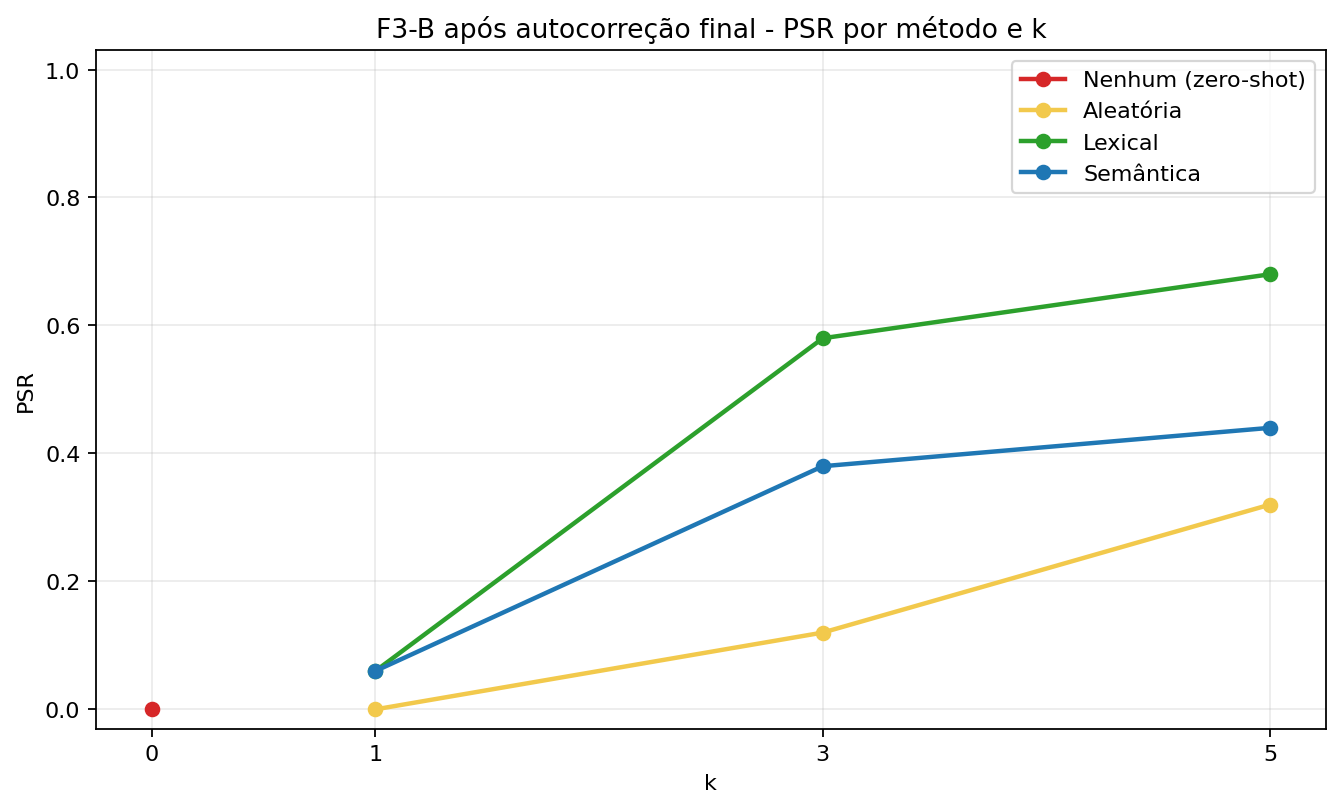

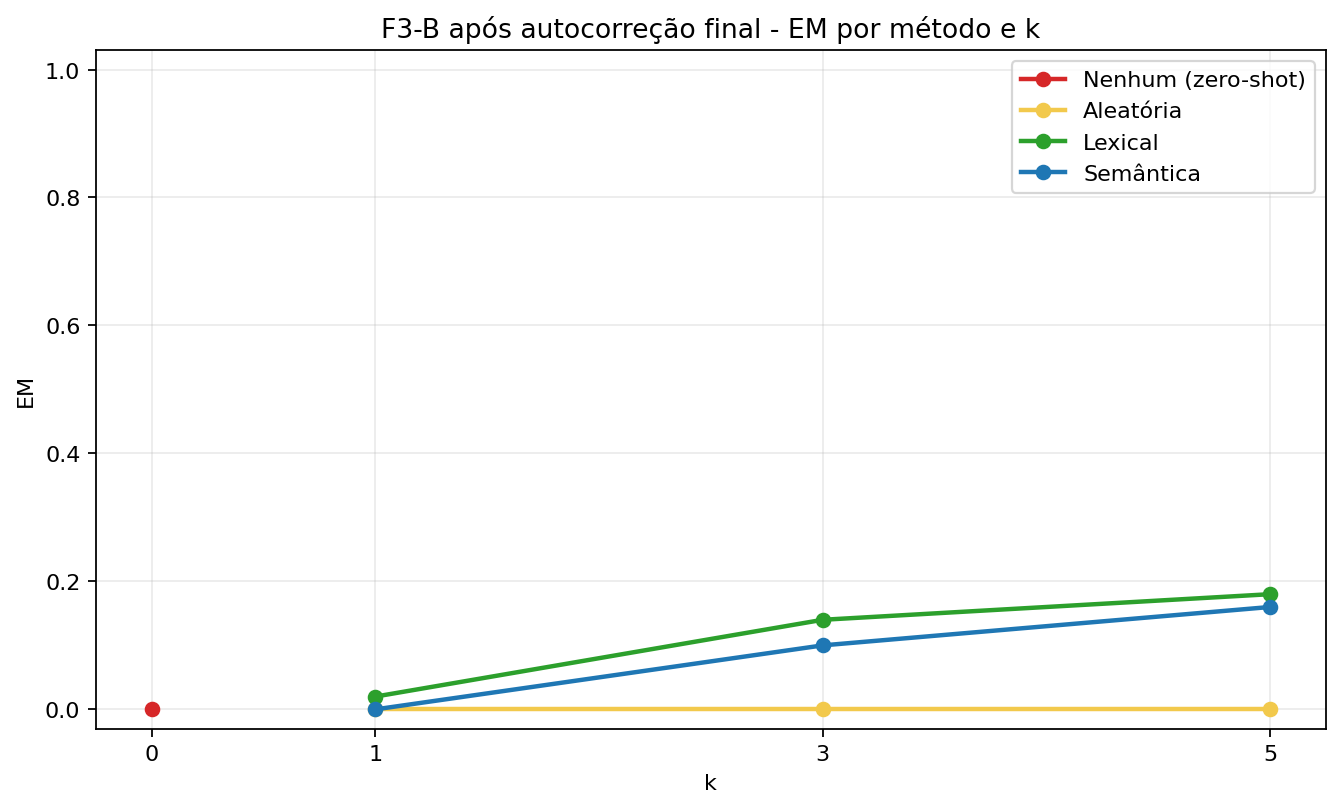

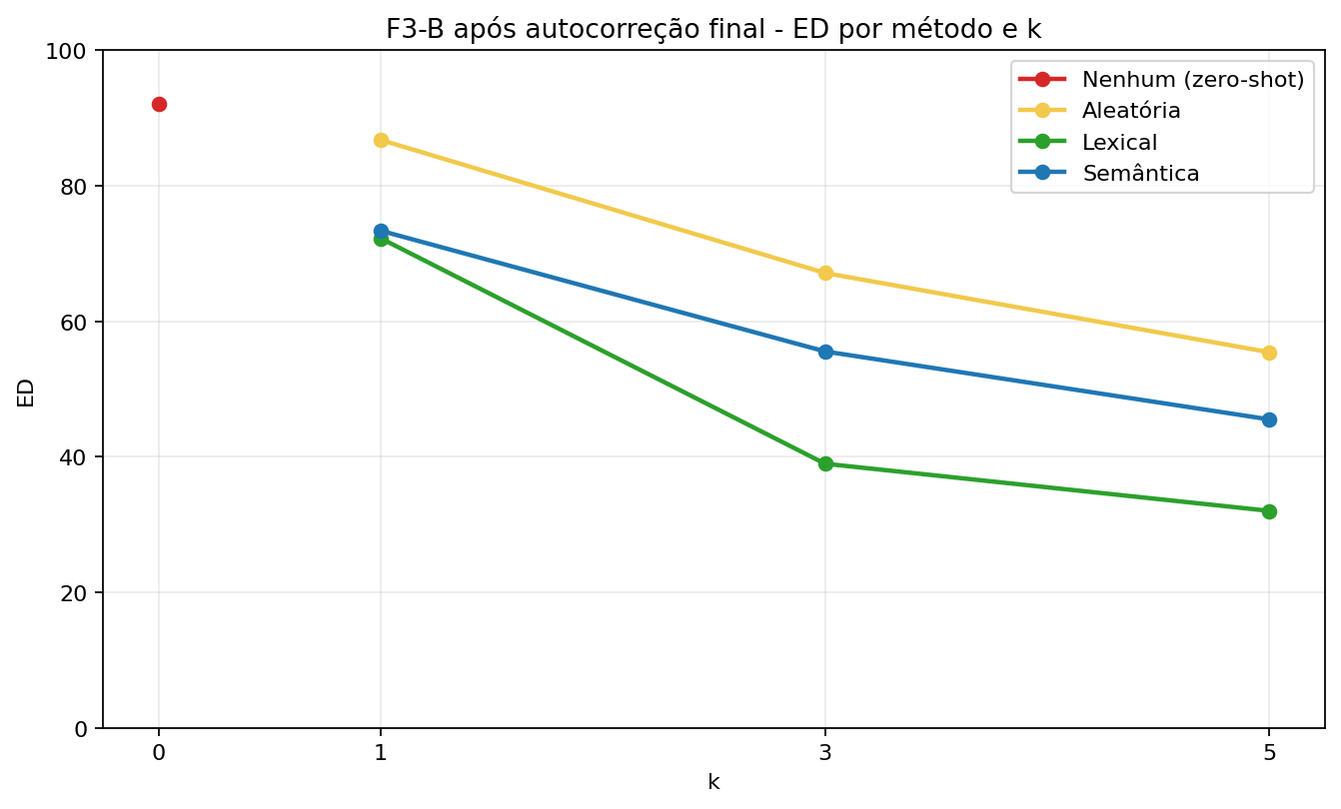

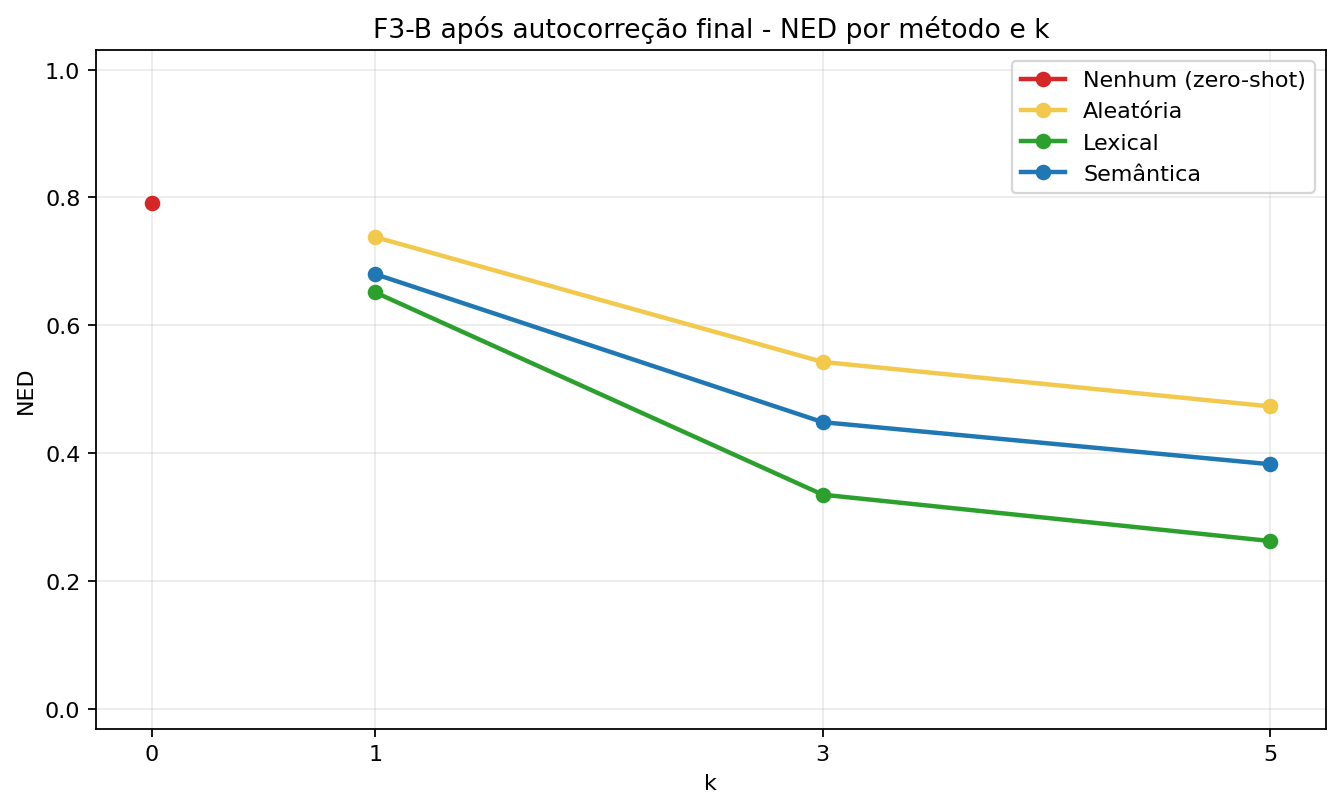

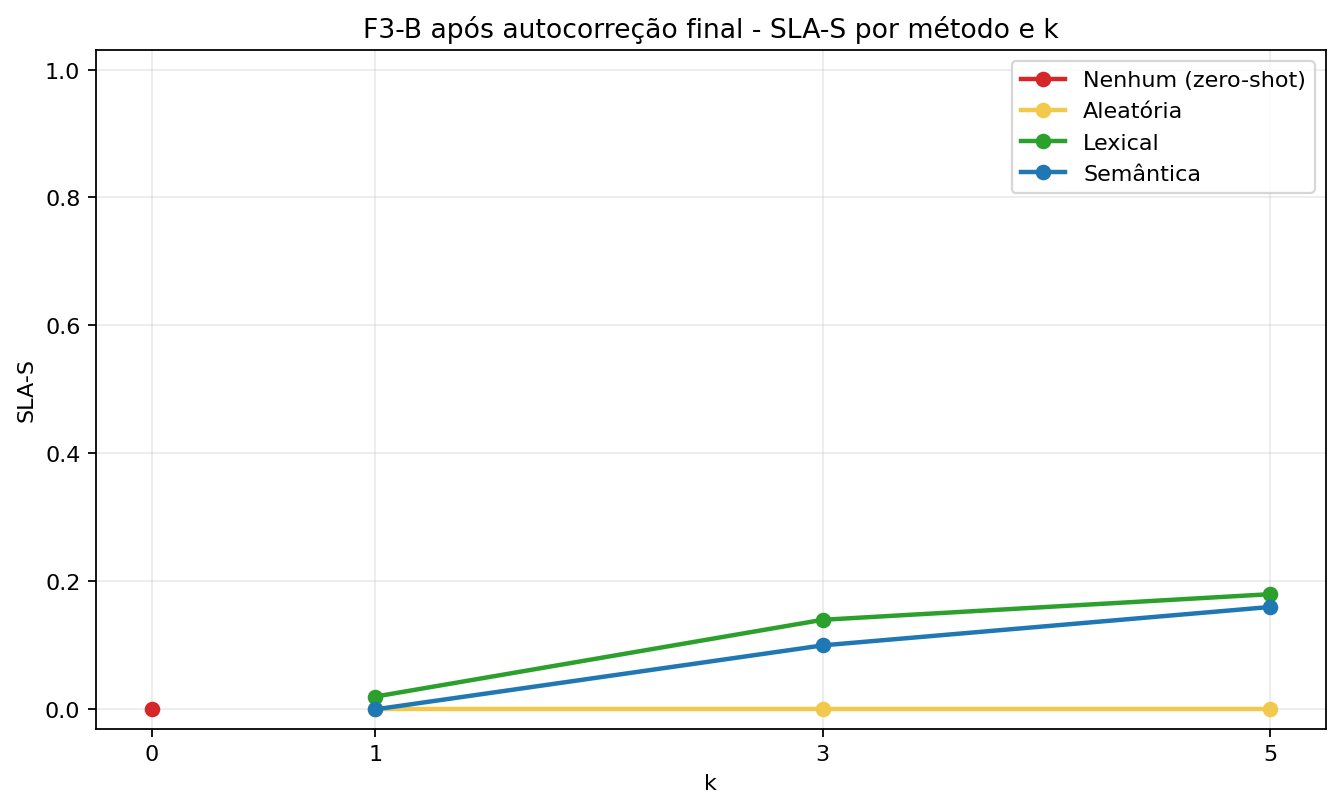

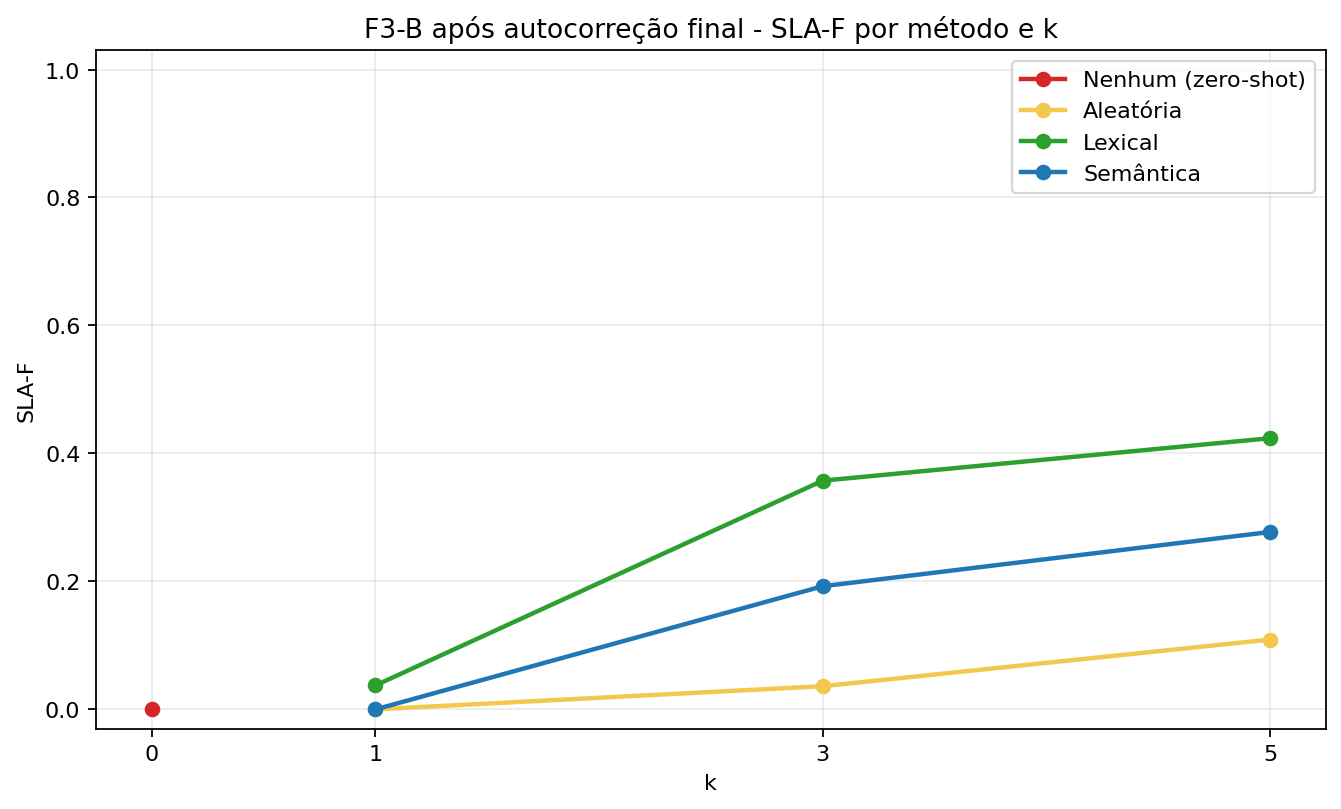

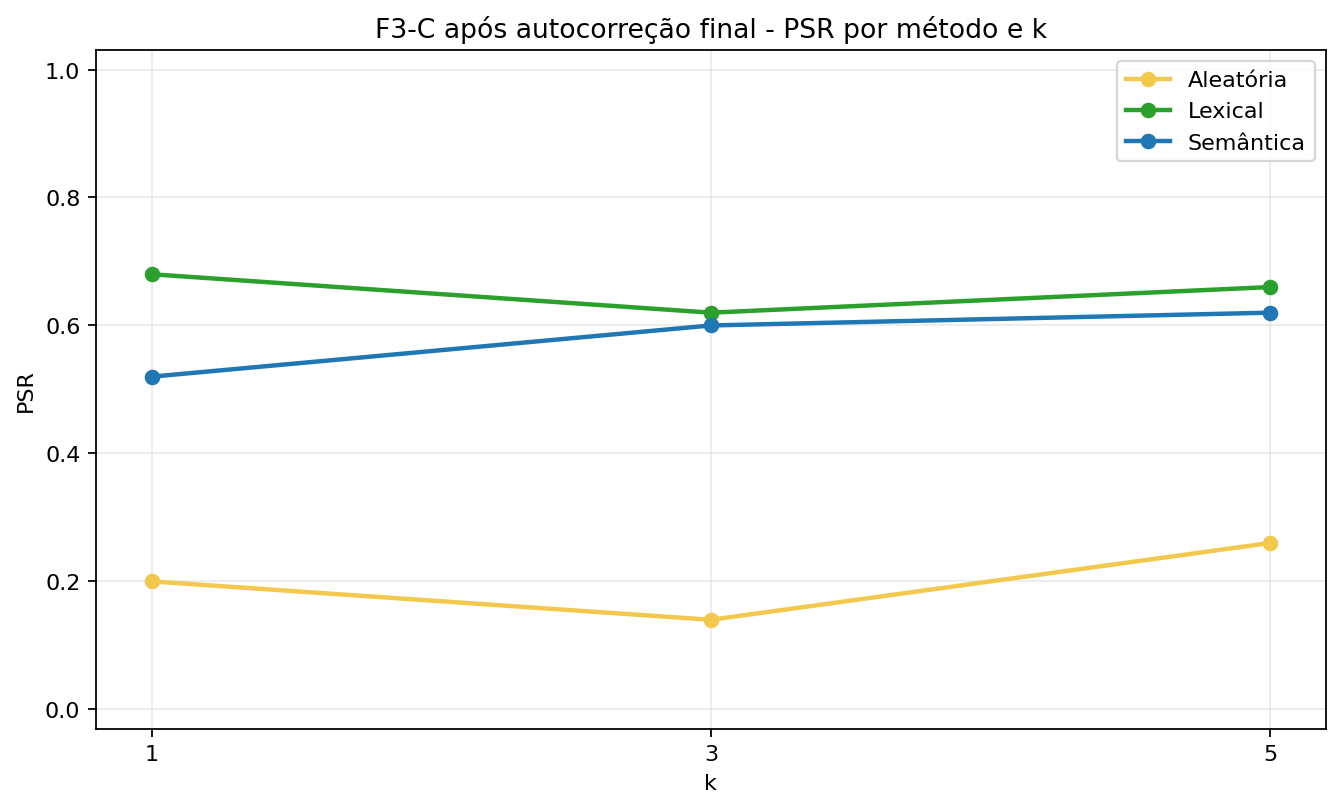

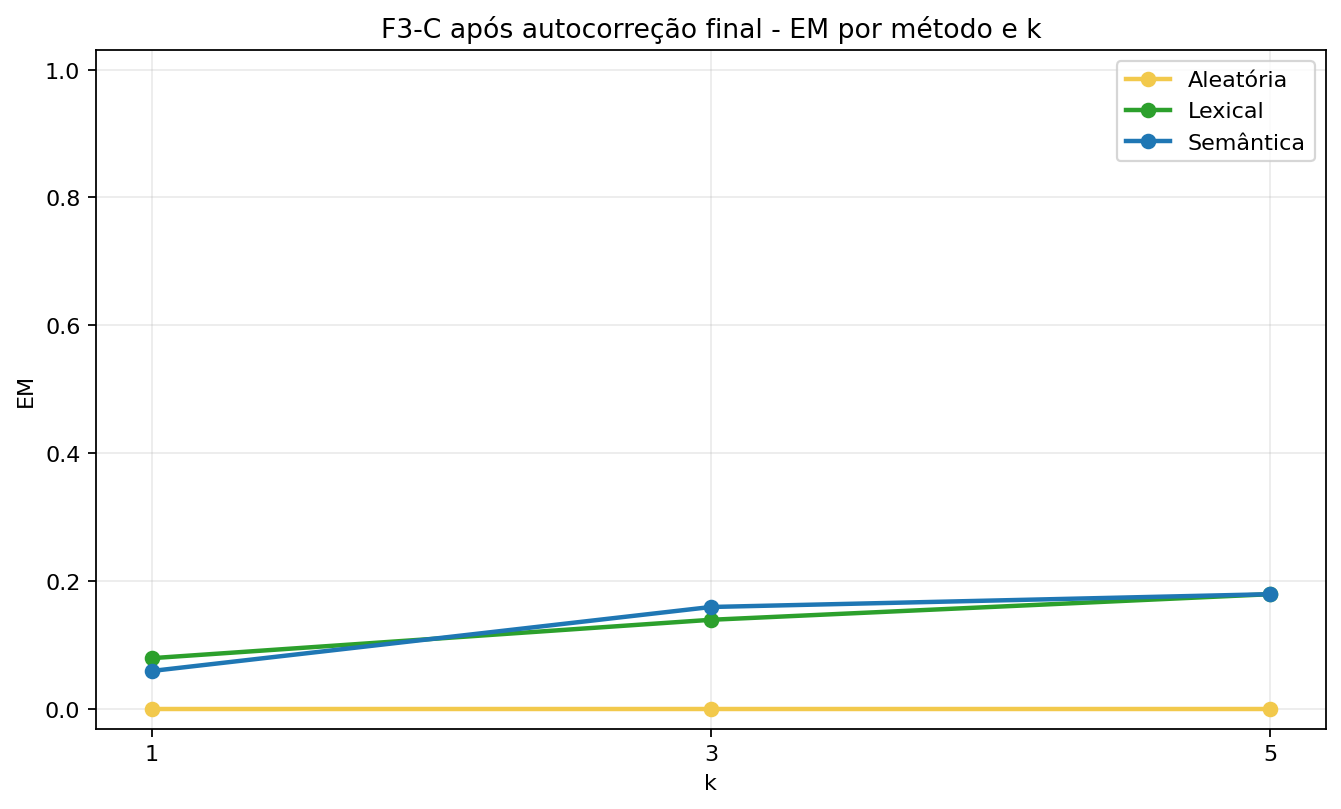

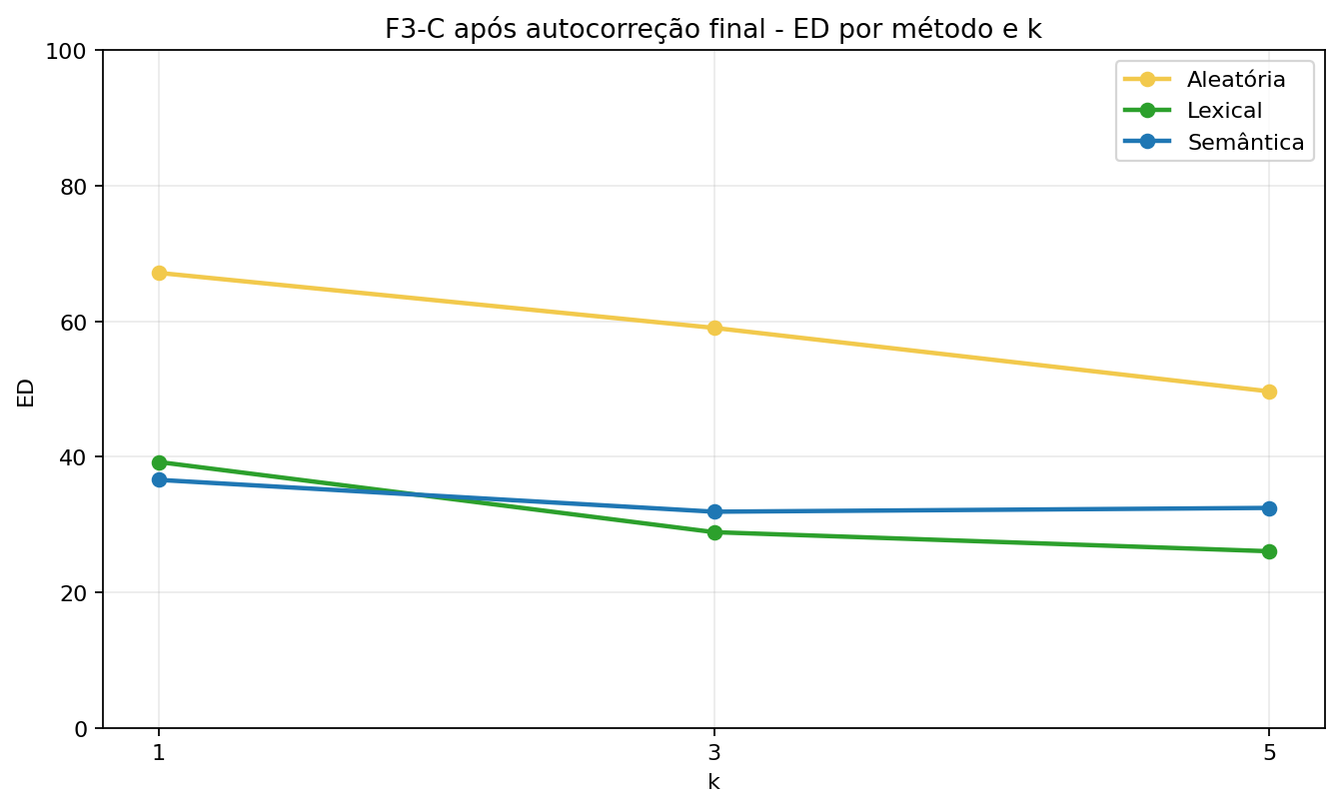

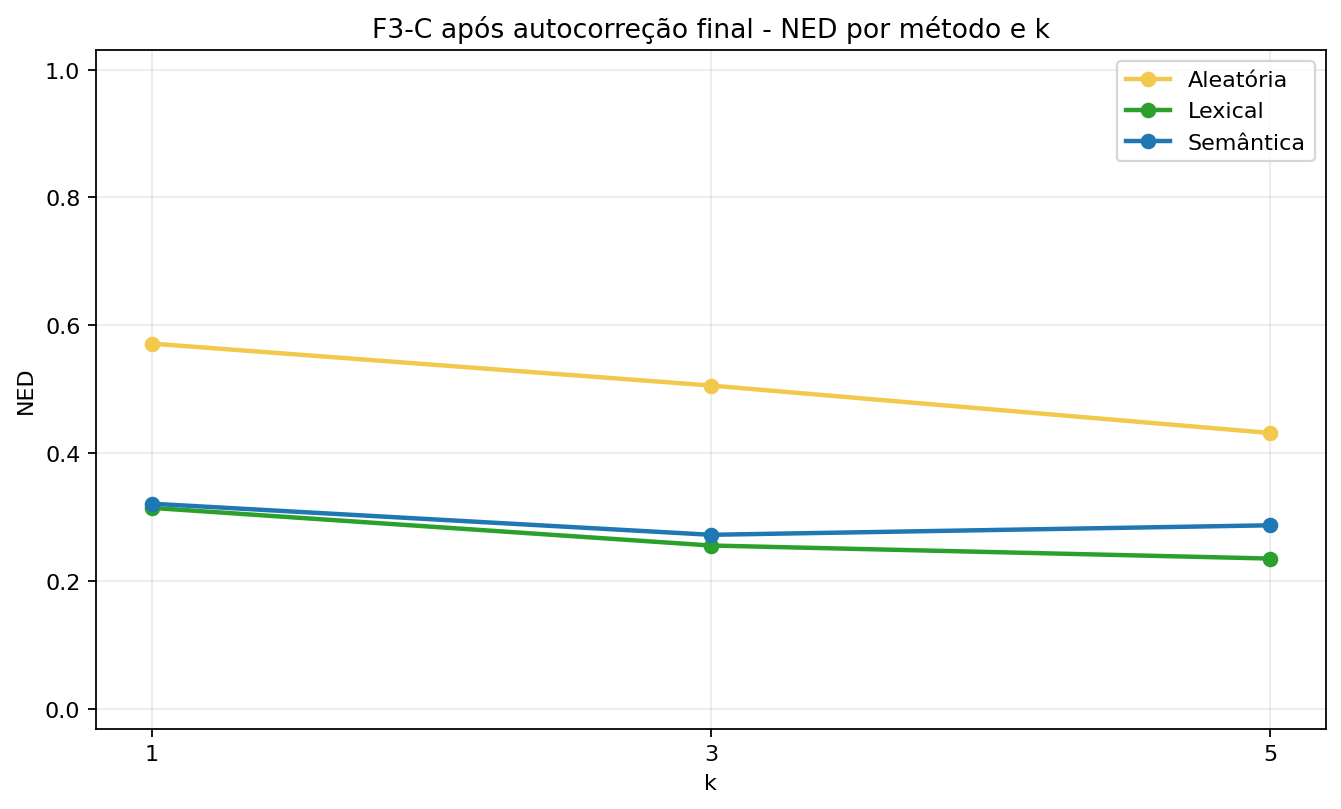

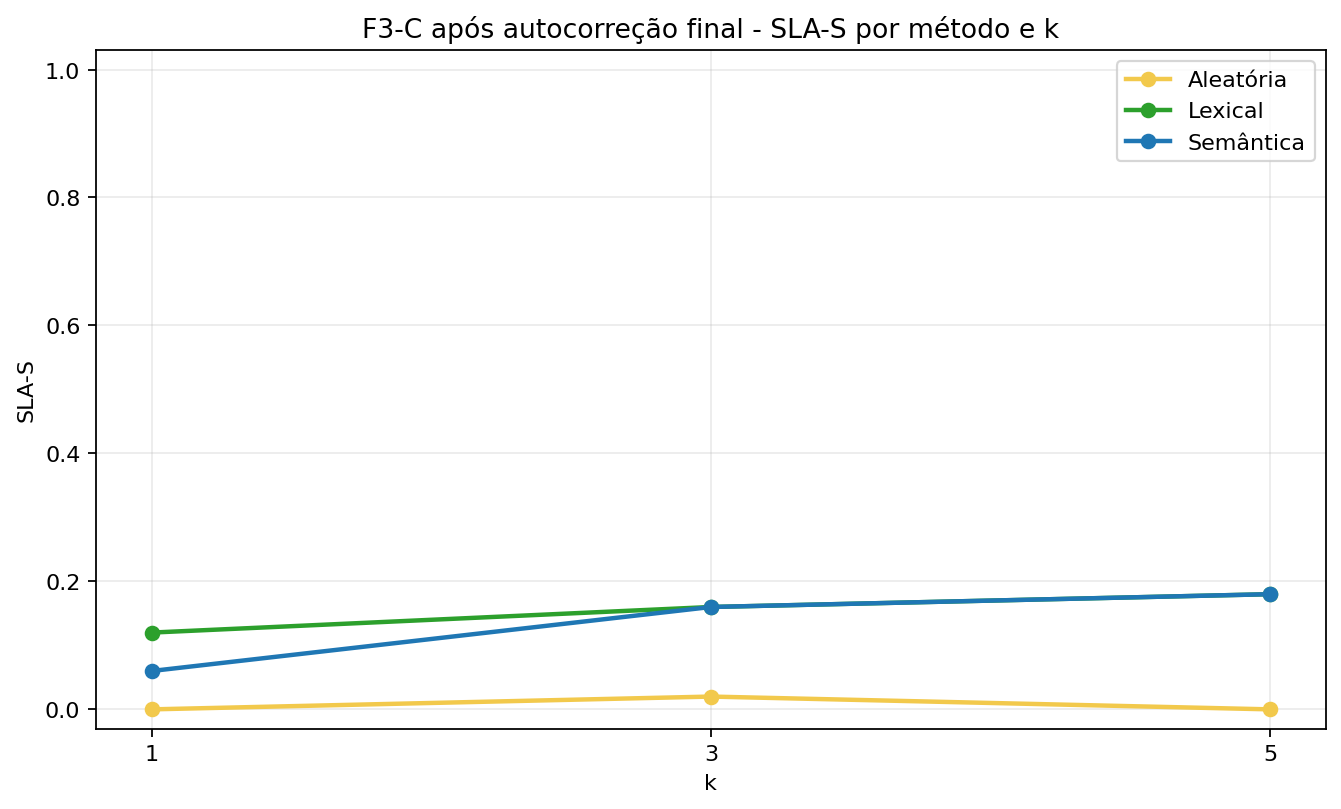

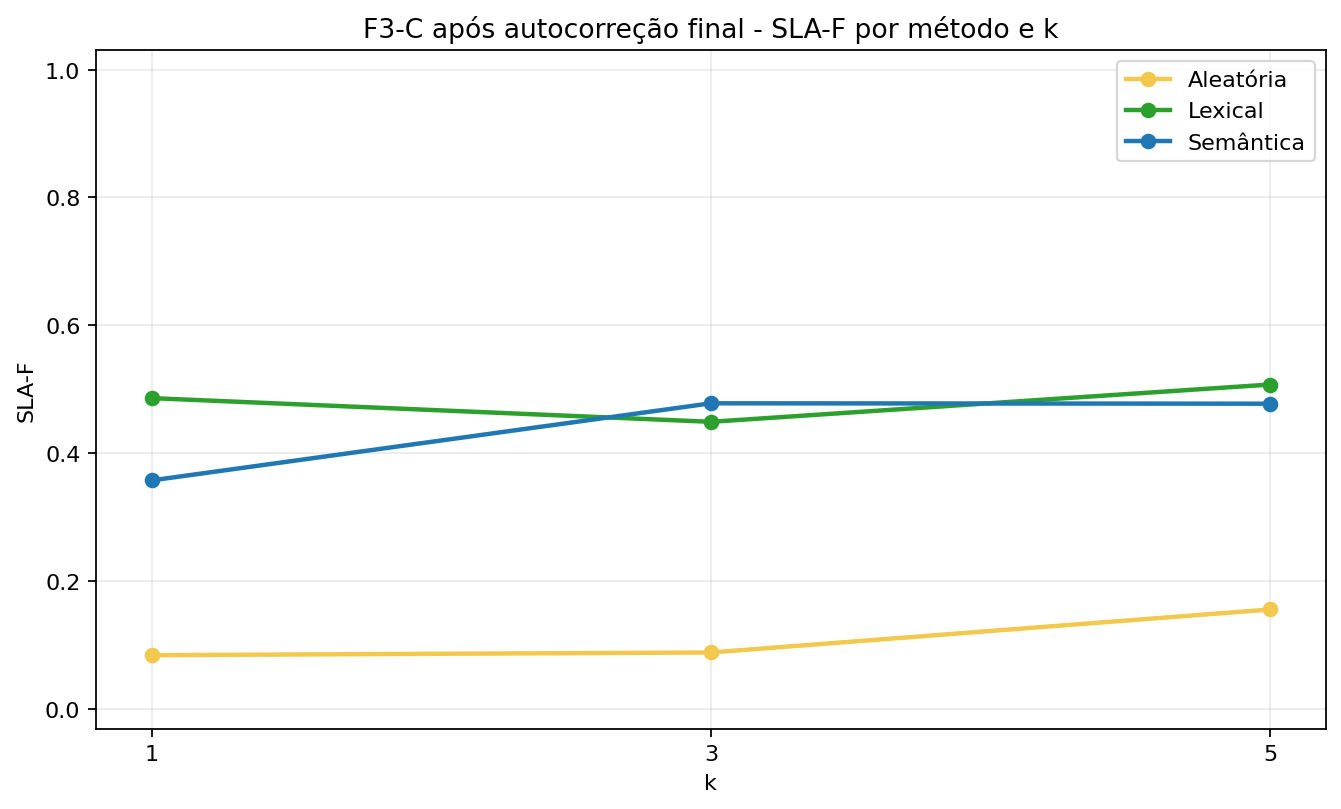

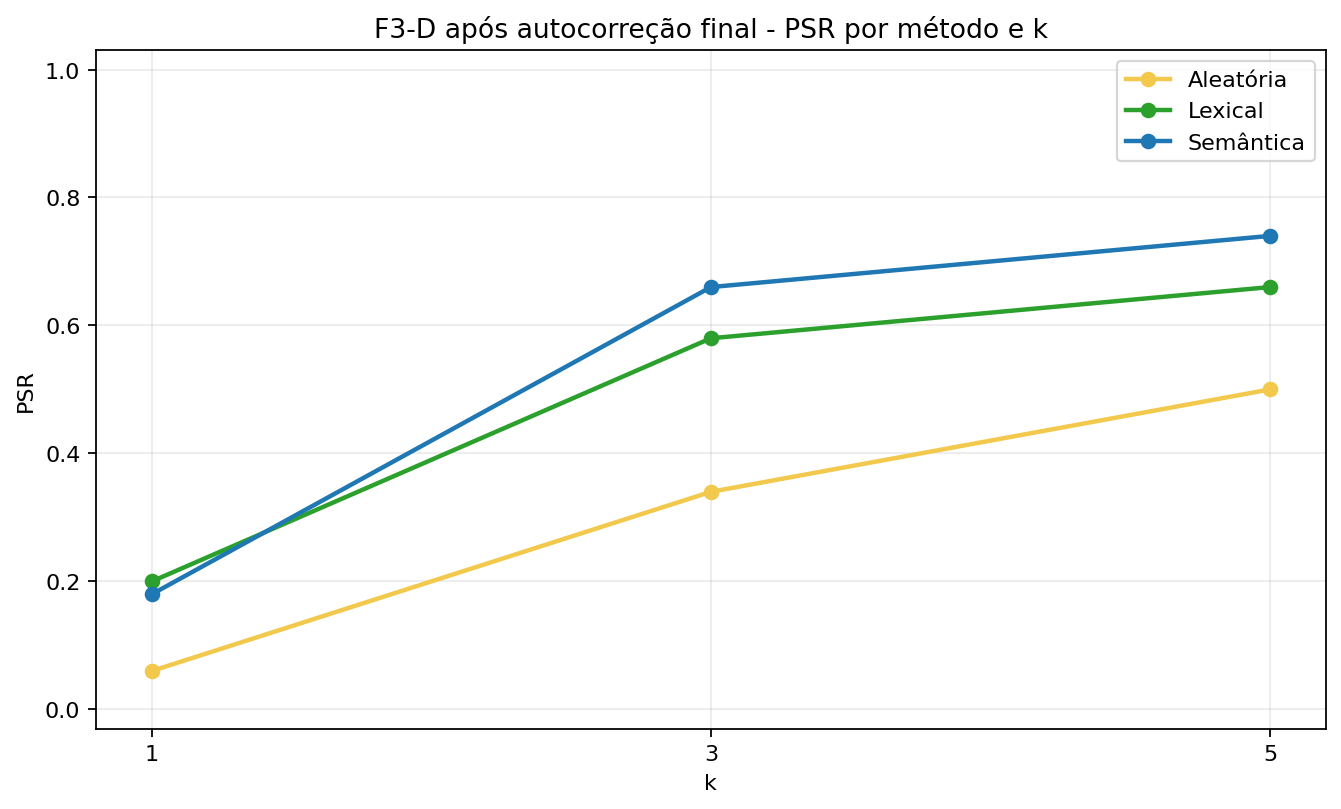

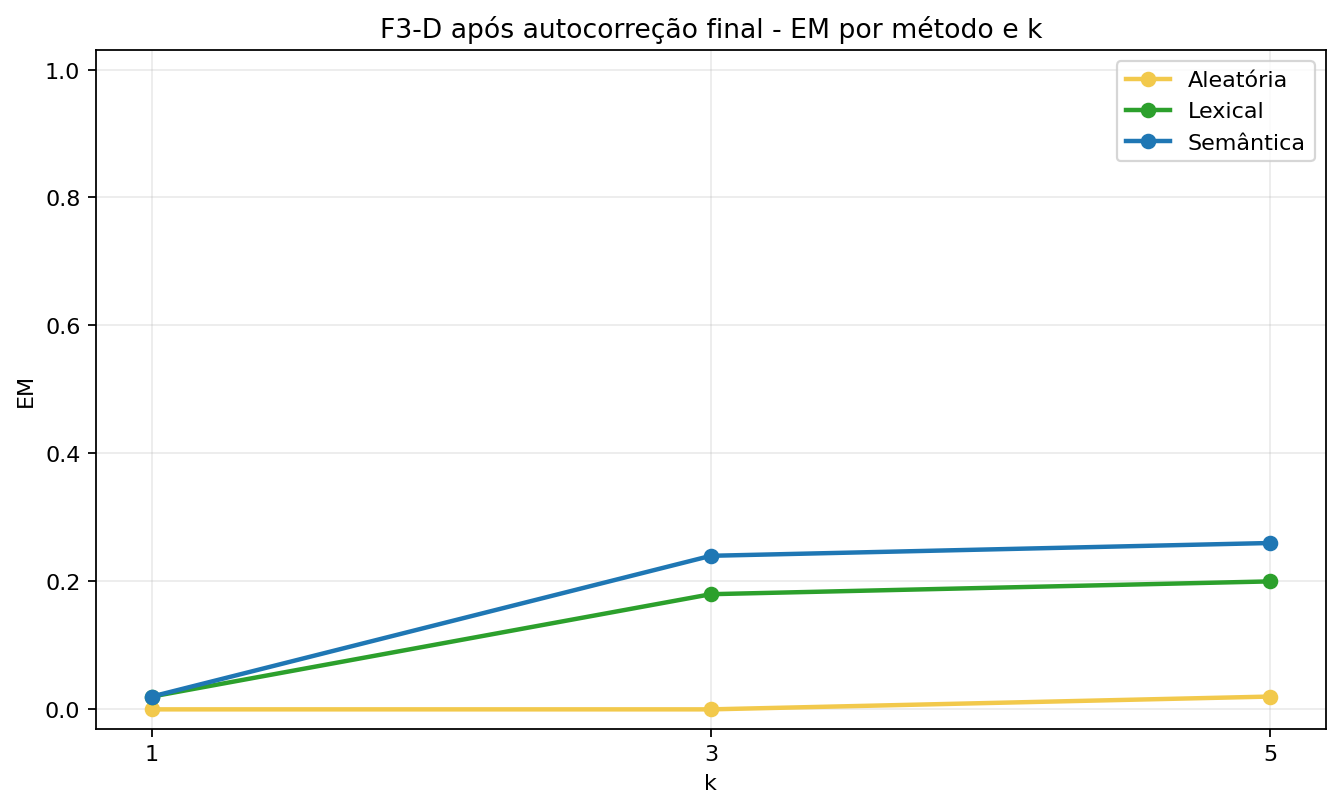

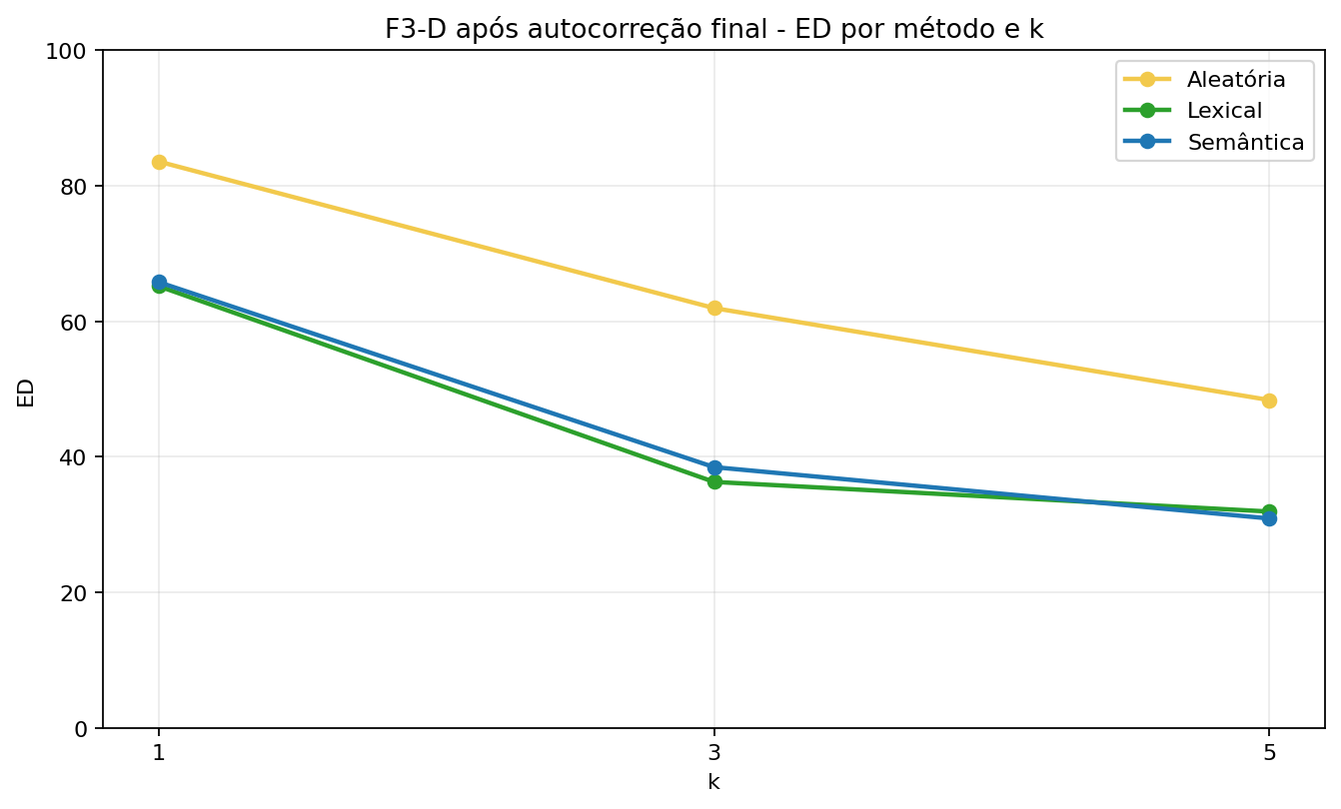

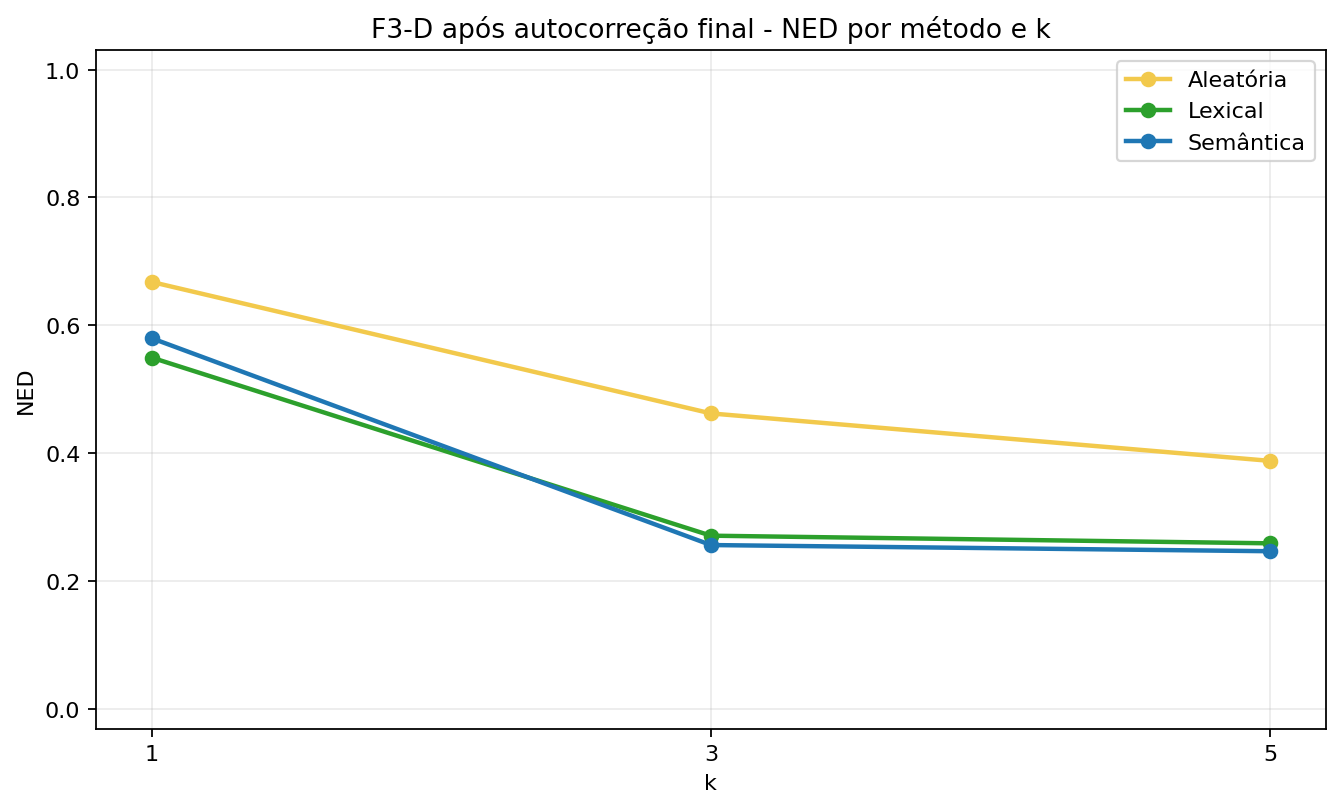

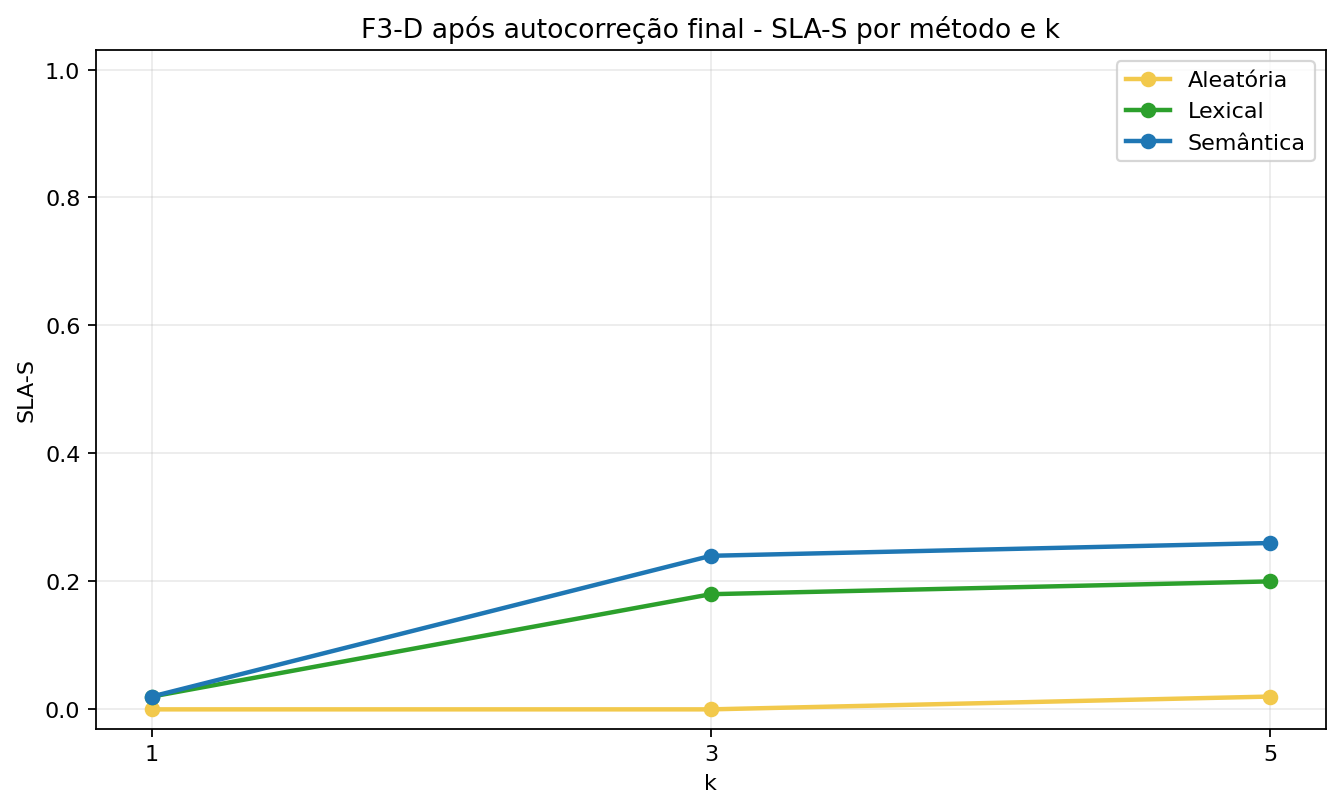

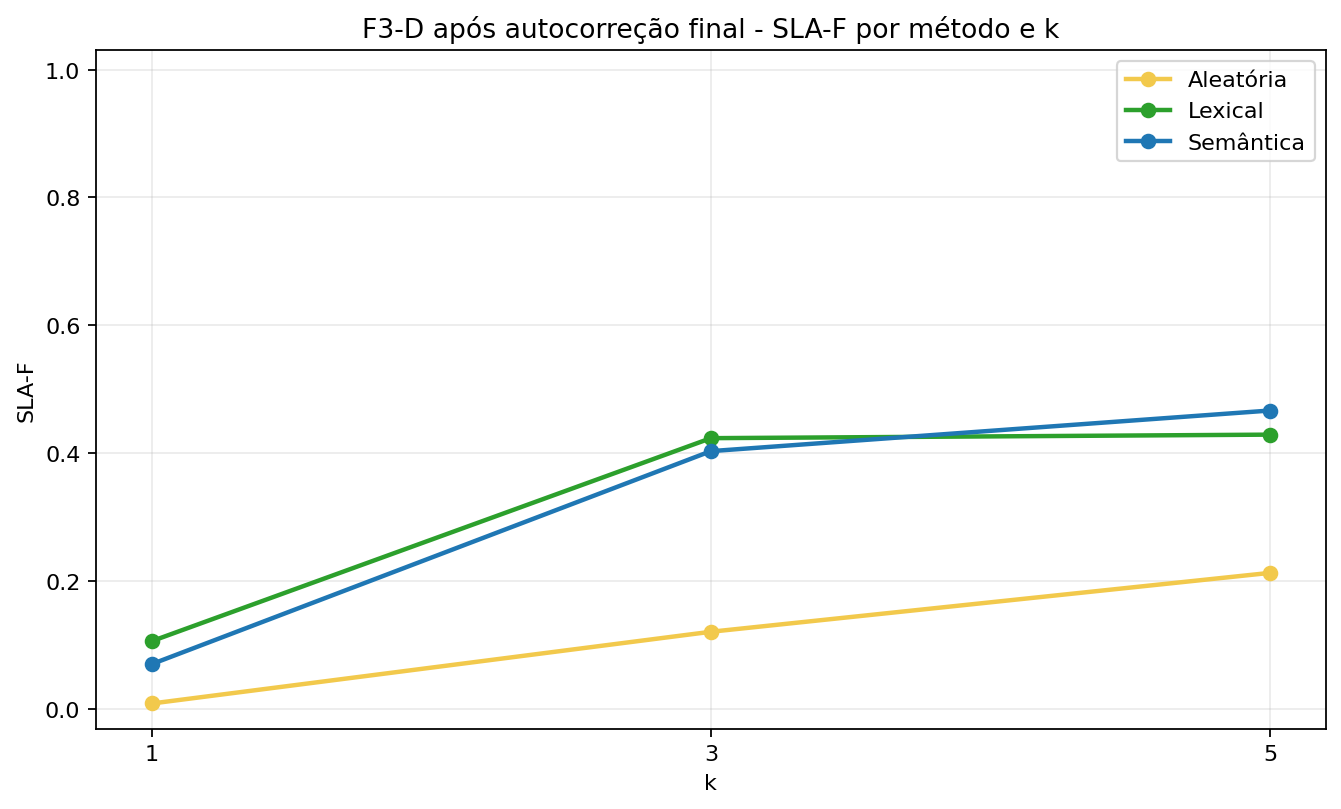

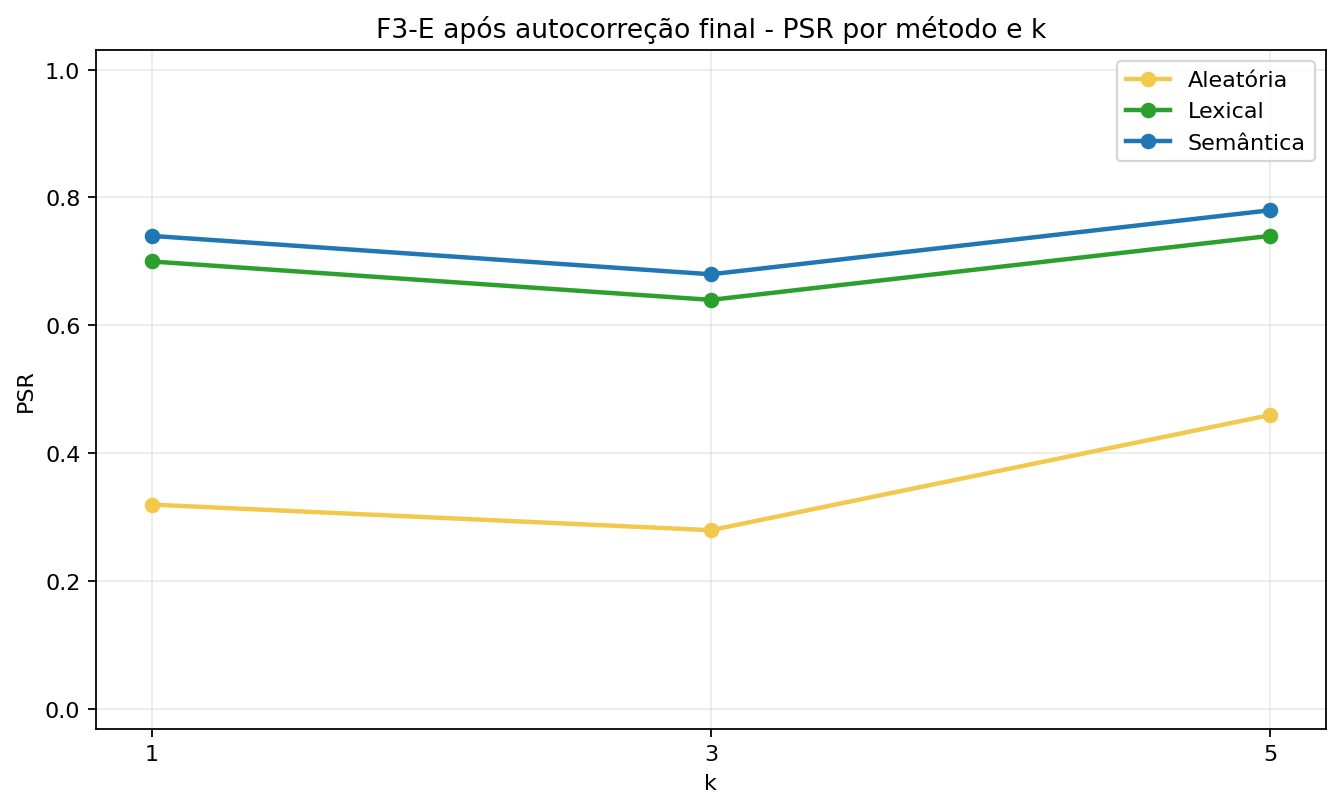

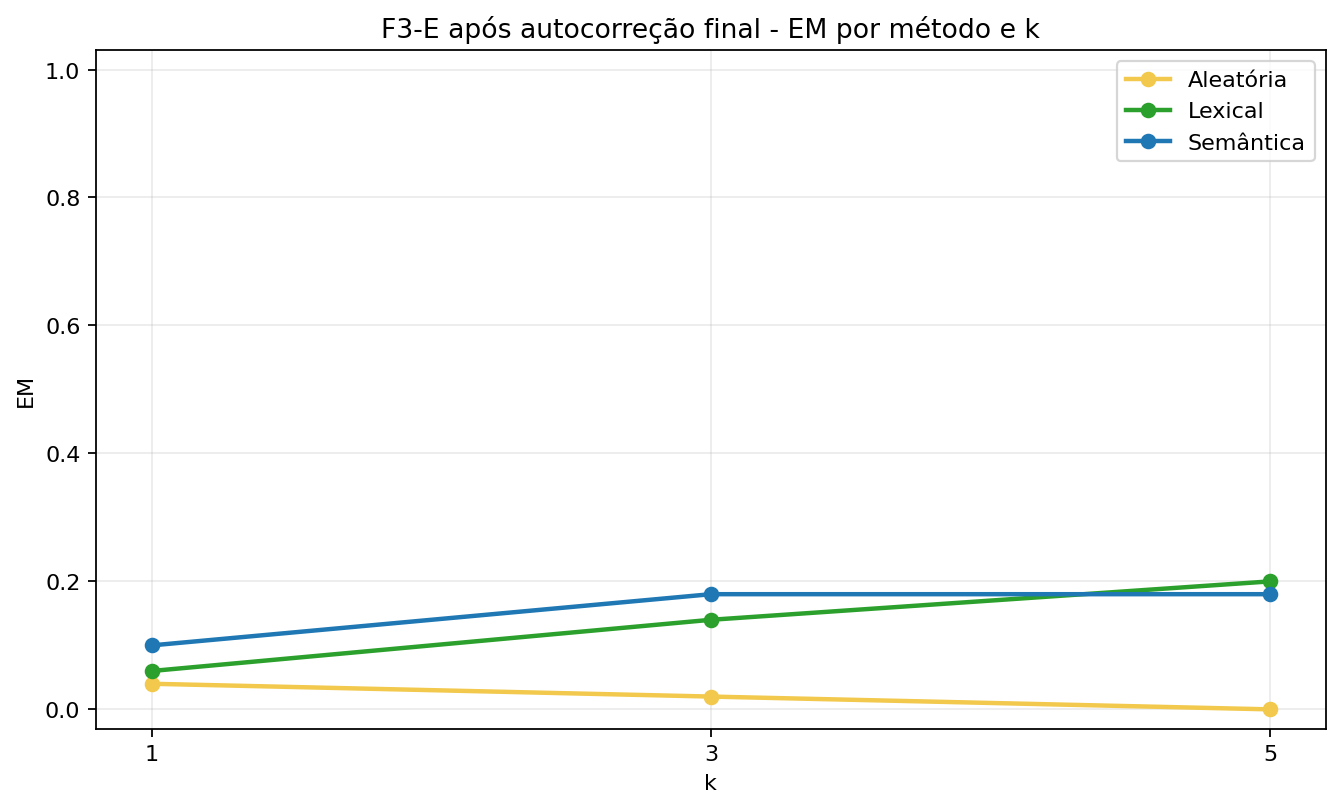

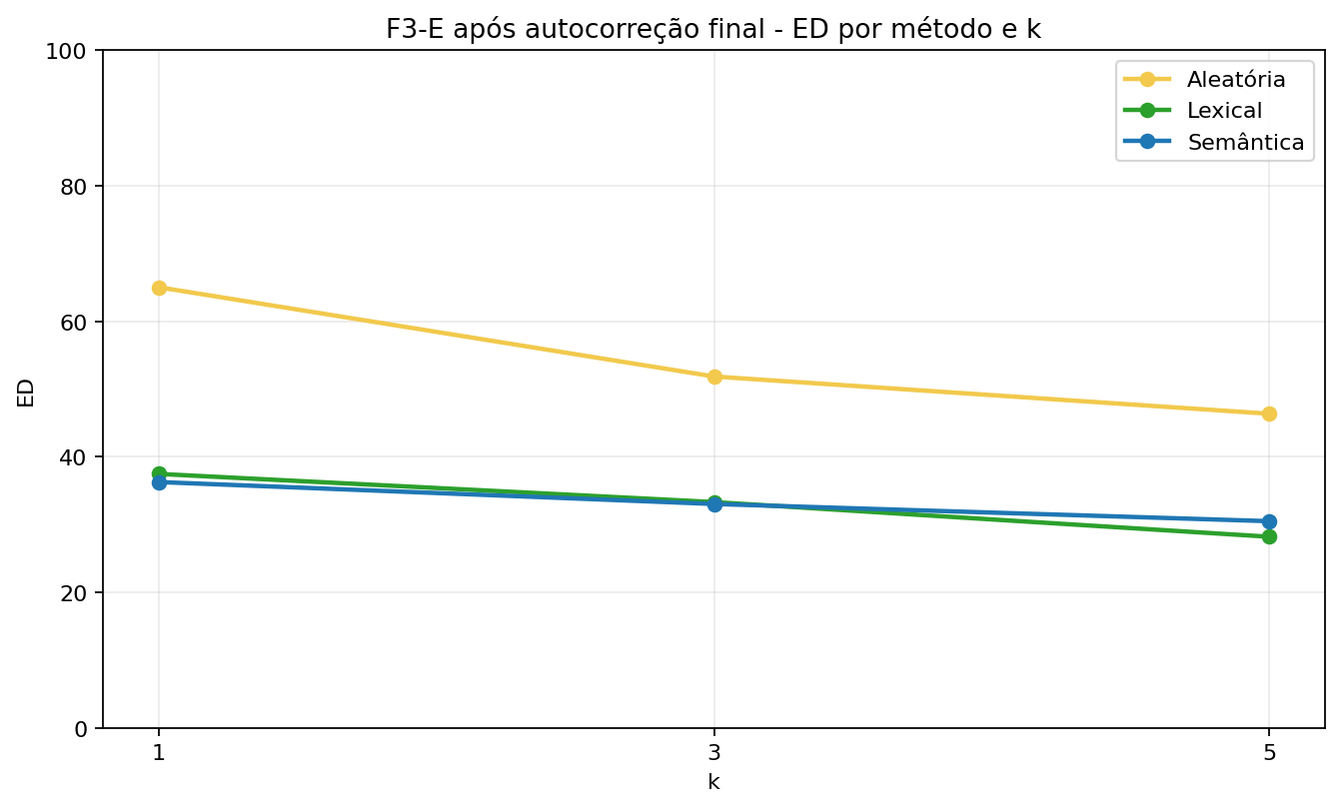

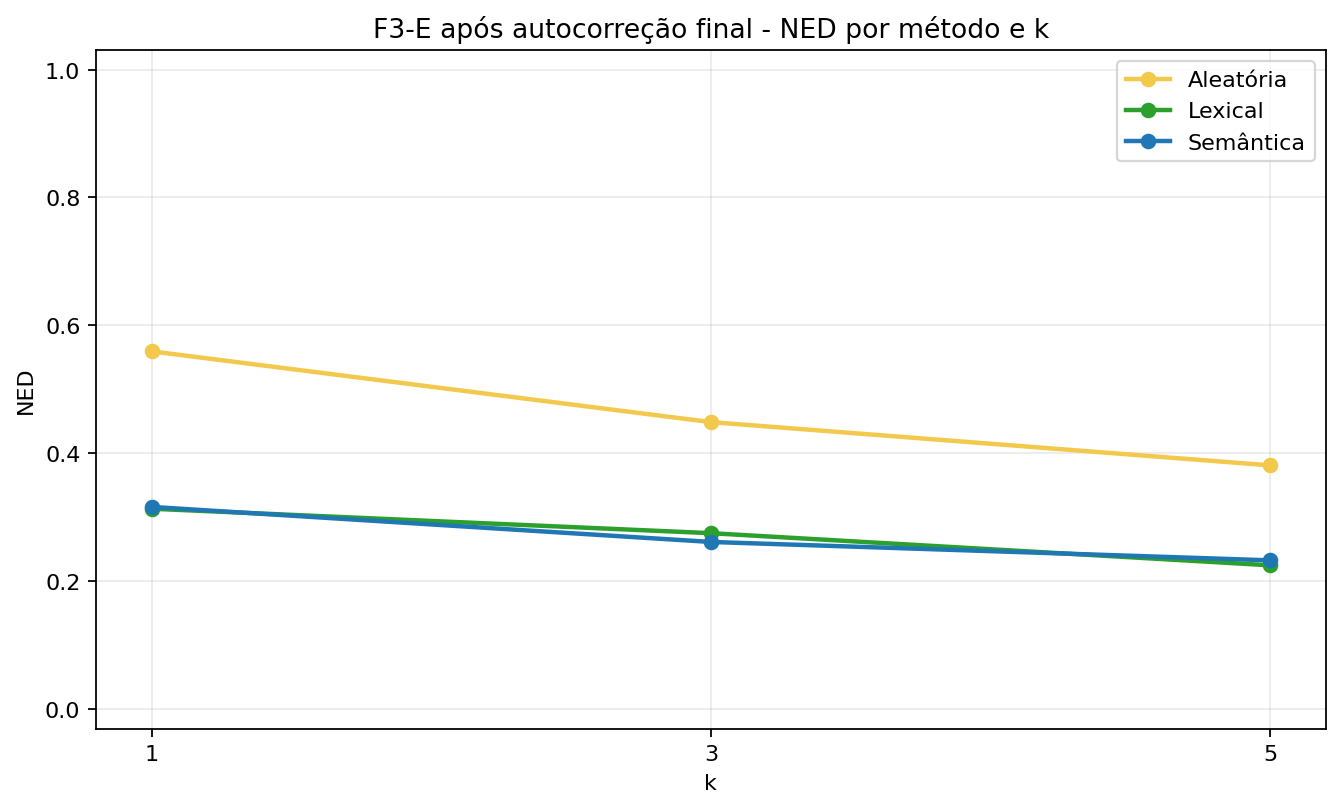

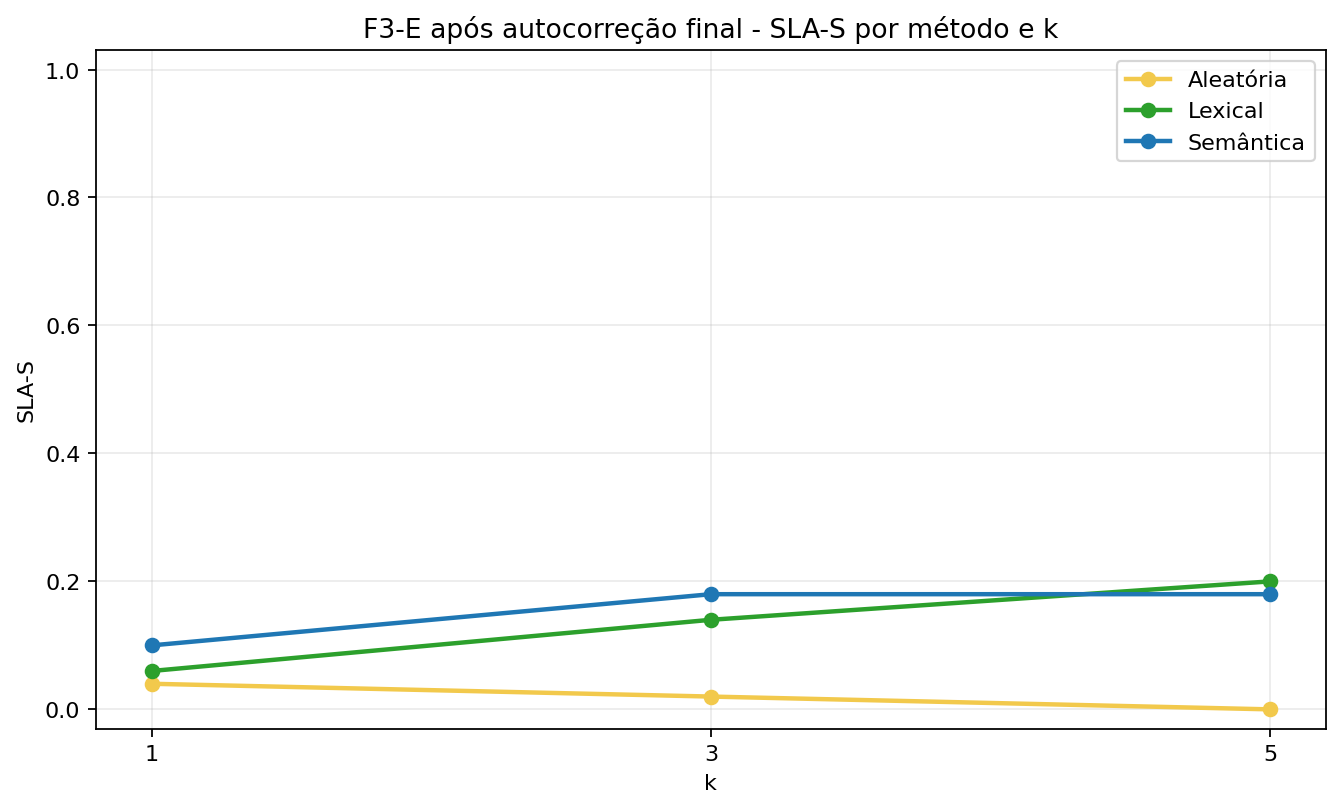

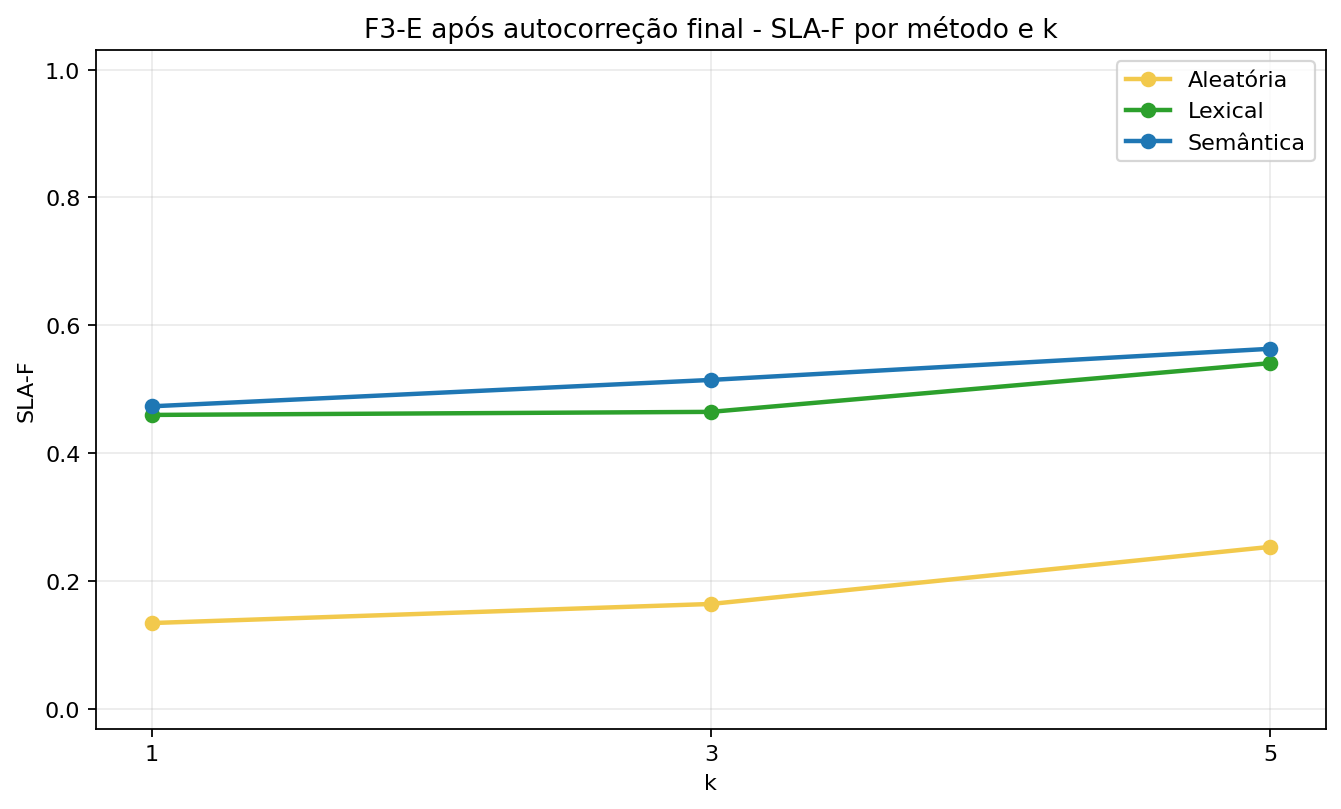

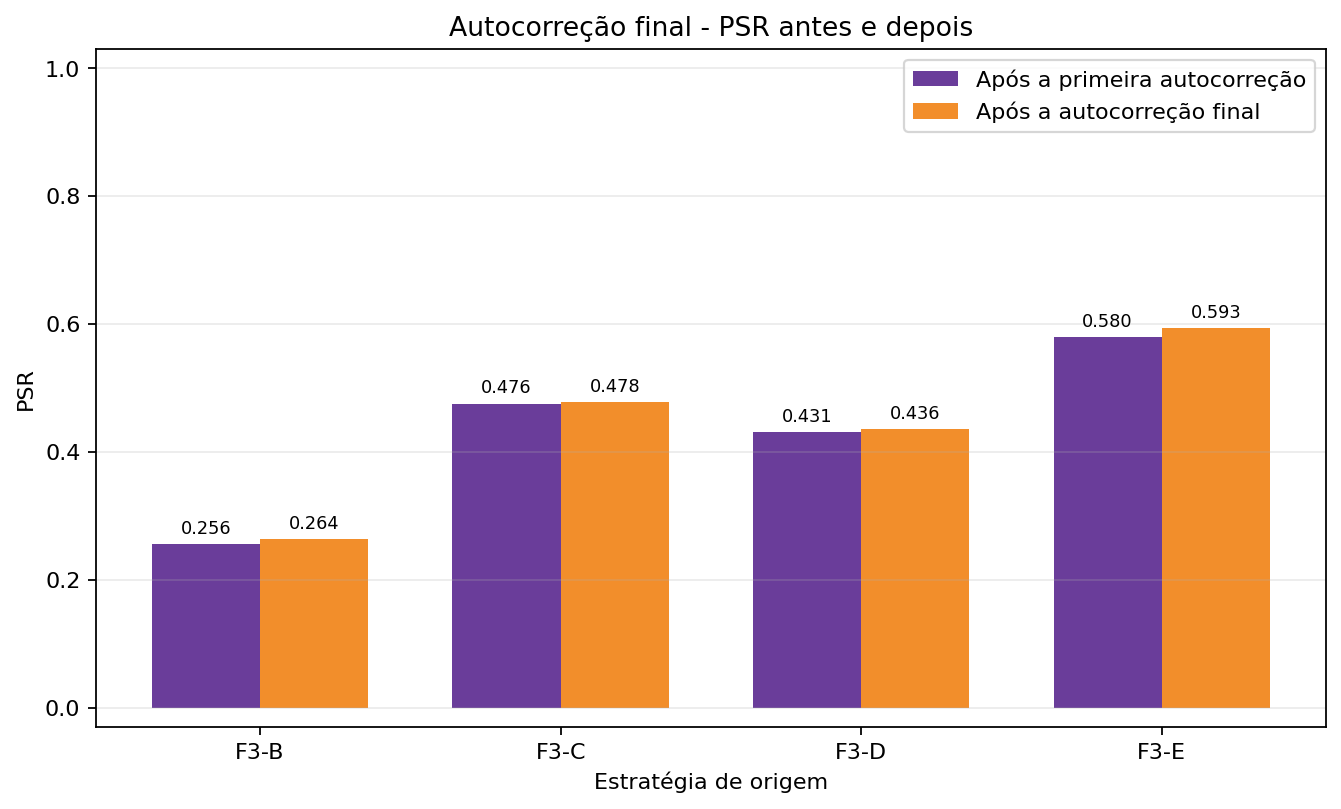

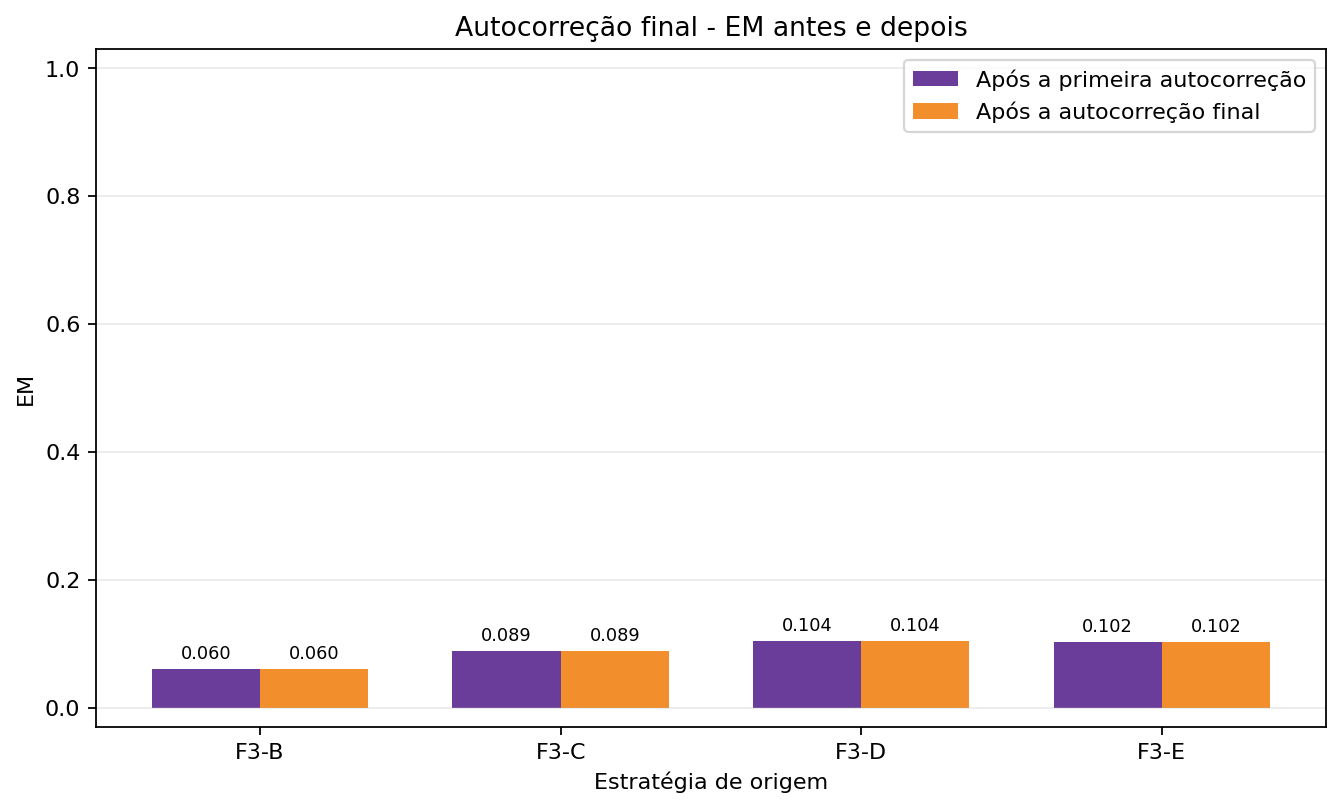

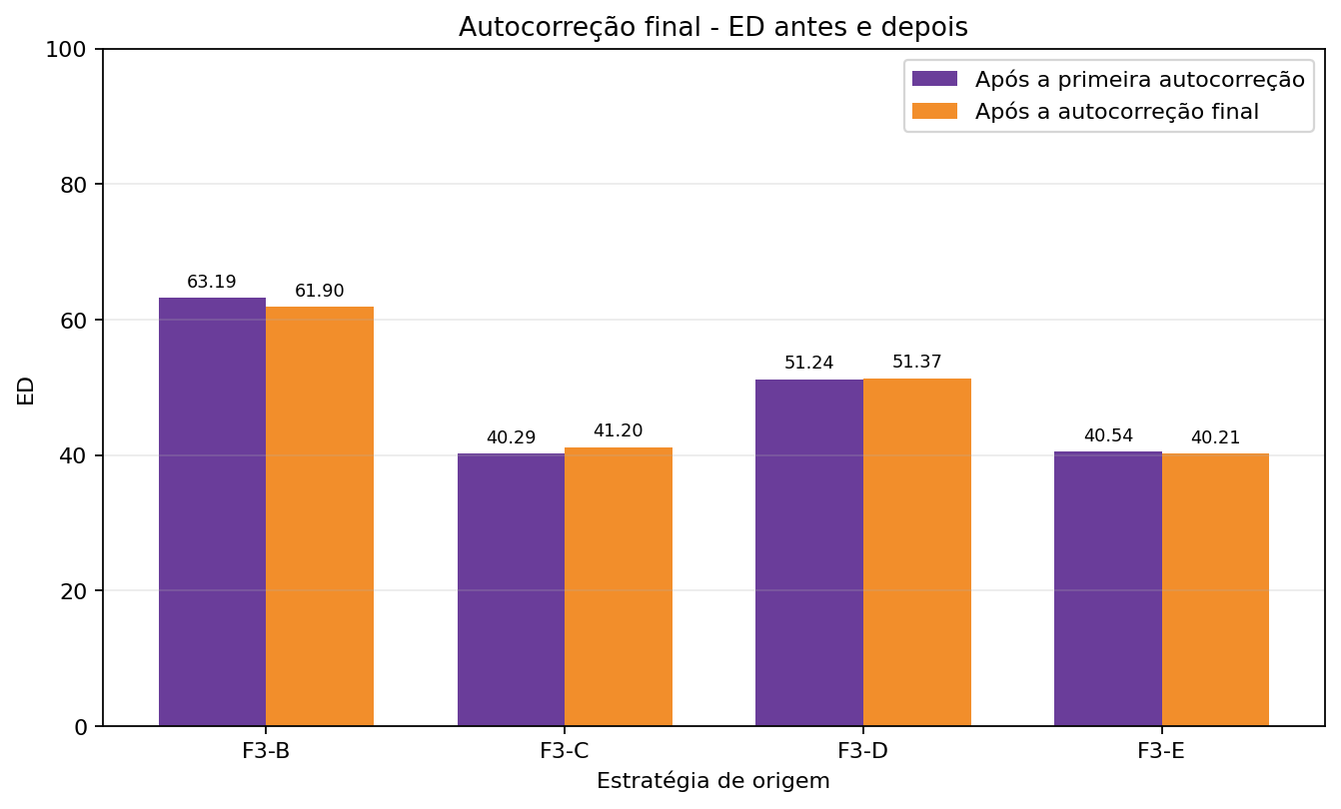

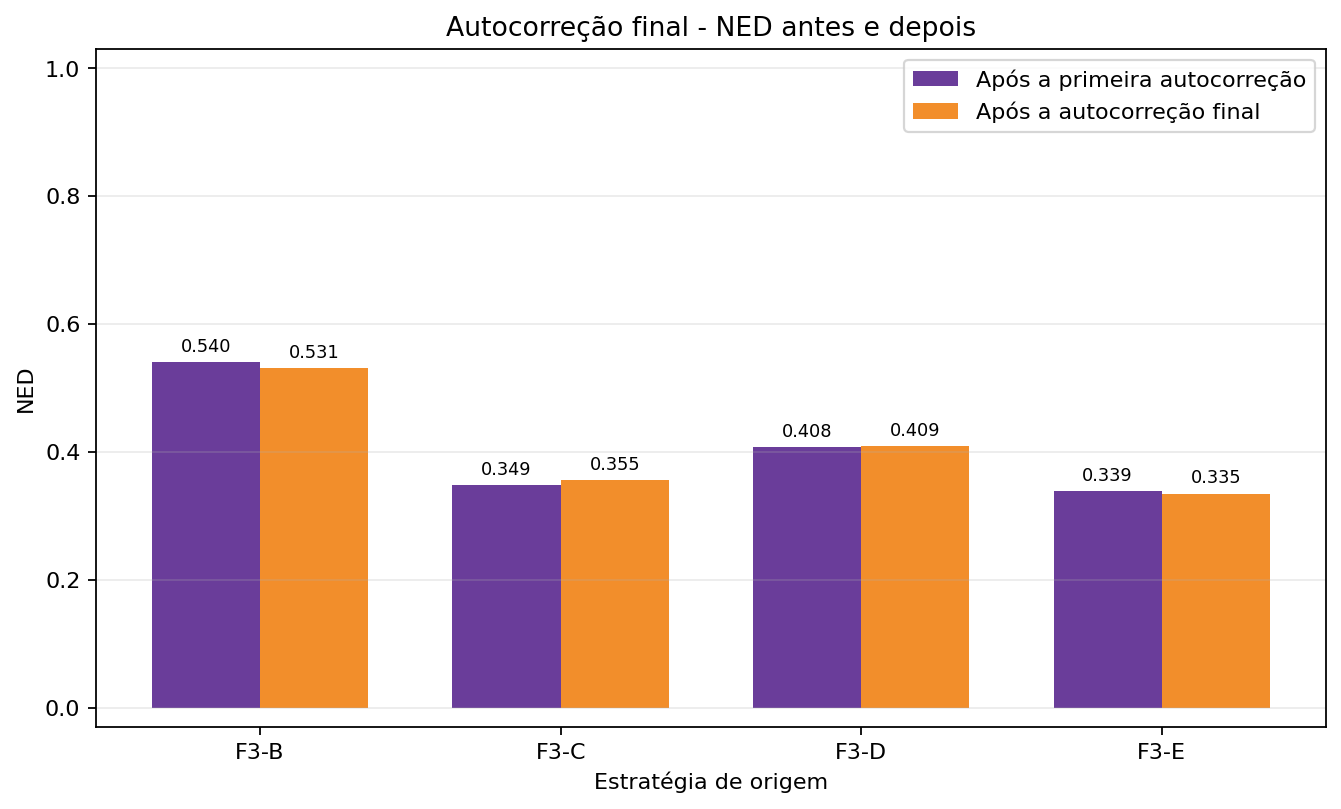

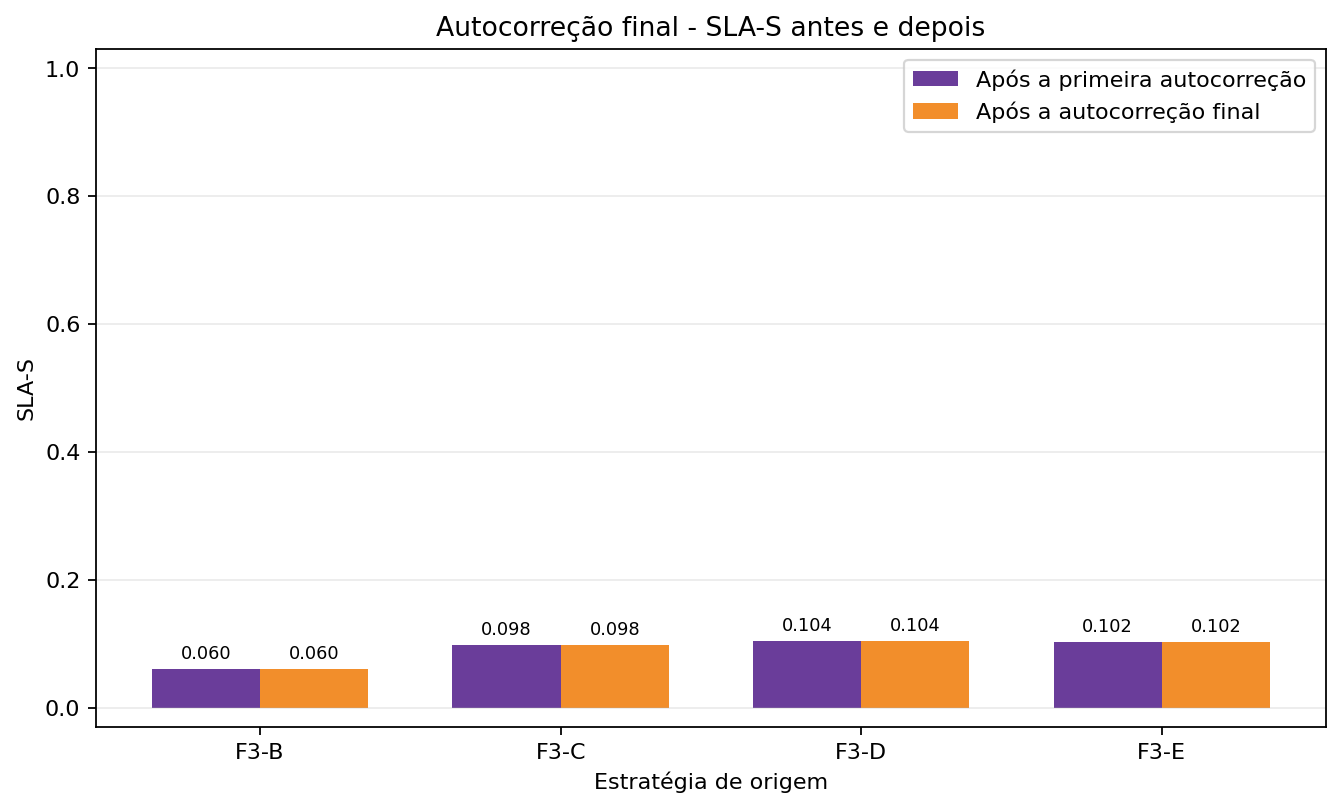

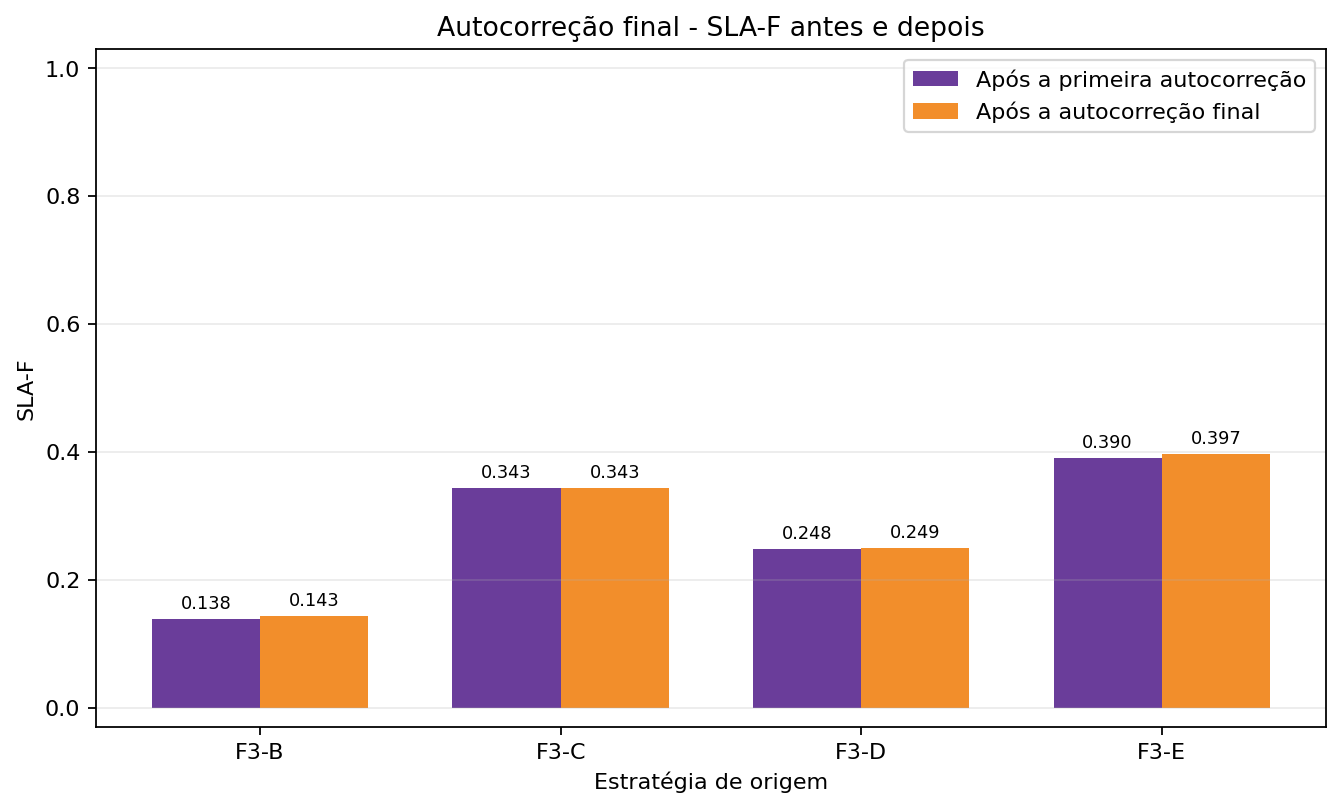

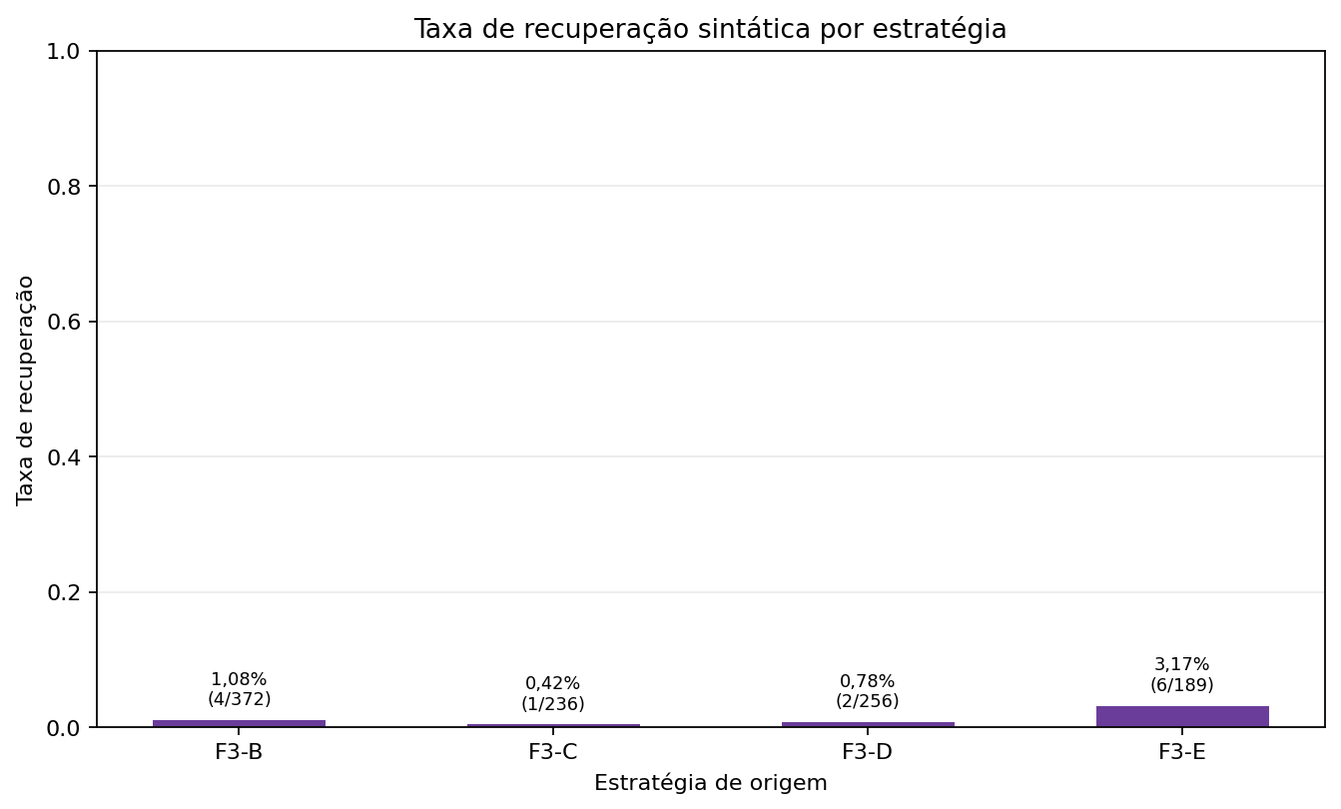

Bloco 9 concluído.
Condições resumidas: 37
Gráficos finais por estratégia: 24
Gráficos comparativos: 6
Gráficos de recuperação: 1
Total de gráficos: 31
Dimensão de todos os gráficos: 1341 × 809 pixels
Padrão visual igual ao utilizado em F3-A, F3-B, F3-C, F3-D e F3-E
Escalas gráficas fixas e padronizadas
Status: OK


In [9]:
# ----------------------------------------------------------
# 9.0 Compatibilidade com a sessão atual
# ----------------------------------------------------------

# Estes caminhos também existem no Bloco 1 da versão completa.
# As verificações abaixo permitem substituir somente os Blocos 9 e 10
# em uma sessão que já executou a versão anterior do notebook.

if "STRATEGY_COMPARISON_PATH" not in globals():
    STRATEGY_COMPARISON_PATH = (
        PACOTE_DIR
        / "f3_autocorrecao_final_comparison_by_strategy.csv"
    )

if "RECOVERY_SUMMARY_PATH" not in globals():
    RECOVERY_SUMMARY_PATH = (
        PACOTE_DIR
        / "f3_autocorrecao_final_recovery_by_strategy.csv"
    )

if "ROTULOS_COLUNAS" in globals():
    ROTULOS_COLUNAS.update({
        "syntax_recovery_rate": "taxa de recuperação sintática",
        "syntax_valid_before": "validade sintática antes",
        "syntax_valid_after": "validade sintática depois",
        "em_before": "EM antes",
        "em_after": "EM depois",
        "ed_before": "ED antes",
        "ed_after": "ED depois",
        "ned_before": "NED antes",
        "ned_after": "NED depois",
        "sla_s_before": "SLA-S antes",
        "sla_s_after": "SLA-S depois",
        "sla_f_before": "SLA-F antes",
        "sla_f_after": "SLA-F depois",
    })


# ----------------------------------------------------------
# 9.1 Resumos por condição e por fold
# ----------------------------------------------------------

summary_df = (
    results_df
    .groupby(
        [
            "strategy",
            "selection_method",
            "selection_label",
            "k",
        ],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
        syntax_valid=("syntax_valid", "sum"),
        autocorrection_applied=("autocorrection_applied", "sum"),
        elapsed_autocorrection_seconds=(
            "elapsed_autocorrection_seconds",
            "mean",
        ),
    )
    .reset_index()
)
summary_df["_ordem_metodo"] = (
    summary_df["selection_method"].map(ORDEM_METODOS_MAPA)
)
summary_df = (
    summary_df
    .sort_values(["strategy", "k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
summary_df.to_csv(SUMMARY_PATH, index=False, encoding="utf-8")

summary_fold_df = (
    results_df
    .groupby(
        [
            "strategy",
            "fold",
            "selection_method",
            "selection_label",
            "k",
        ],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
        syntax_valid=("syntax_valid", "sum"),
    )
    .reset_index()
)
summary_fold_df["_ordem_metodo"] = (
    summary_fold_df["selection_method"].map(ORDEM_METODOS_MAPA)
)
summary_fold_df = (
    summary_fold_df
    .sort_values(["strategy", "fold", "k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
summary_fold_df.to_csv(SUMMARY_FOLD_PATH, index=False, encoding="utf-8")


# ----------------------------------------------------------
# 9.2 Ganhos e análise por exemplo
# ----------------------------------------------------------

gains_df = (
    comparison_df
    .groupby(
        [
            "strategy",
            "selection_method",
            "selection_label",
            "k",
        ],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        eligible=("eligible_for_final_autocorrection", "sum"),
        psr_before=("psr_before", "mean"),
        psr_after=("psr_after", "mean"),
        em_before=("em_before", "mean"),
        em_after=("em_after", "mean"),
        ed_before=("ed_before", "mean"),
        ed_after=("ed_after", "mean"),
        ned_before=("ned_before", "mean"),
        ned_after=("ned_after", "mean"),
        sla_s_before=("sla_s_before", "mean"),
        sla_s_after=("sla_s_after", "mean"),
        sla_f_before=("sla_f_before", "mean"),
        sla_f_after=("sla_f_after", "mean"),
        syntax_recovered=("syntax_recovered", "sum"),
    )
    .reset_index()
)
for metric in METRICAS:
    if metric == "ed":
        gains_df[f"{metric}_gain"] = (
            gains_df[f"{metric}_before"] - gains_df[f"{metric}_after"]
        )
    else:
        gains_df[f"{metric}_gain"] = (
            gains_df[f"{metric}_after"] - gains_df[f"{metric}_before"]
        )
gains_df["_ordem_metodo"] = (
    gains_df["selection_method"].map(ORDEM_METODOS_MAPA)
)
gains_df = (
    gains_df
    .sort_values(["strategy", "k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
gains_df.to_csv(GAINS_PATH, index=False, encoding="utf-8")

analysis_example_df = (
    comparison_df
    .groupby(["strategy", "id"])
    .agg(
        records=("id", "count"),
        eligible=("eligible_for_final_autocorrection", "sum"),
        psr_before=("psr_before", "mean"),
        psr_after=("psr_after", "mean"),
        syntax_recovered=("syntax_recovered", "sum"),
    )
    .reset_index()
    .sort_values(["strategy", "id"])
)
analysis_example_df.to_csv(
    ANALYSIS_EXAMPLE_PATH,
    index=False,
    encoding="utf-8",
)

execution_audit_df = (
    pd.DataFrame(generation_records)
    .groupby("strategy")
    .agg(
        requested=("id", "count"),
        prompt_tokens=("prompt_tokens", "sum"),
        generated_tokens=("generated_tokens", "sum"),
        elapsed_seconds=("elapsed_seconds", "sum"),
    )
    .reset_index()
)
execution_audit_df.to_csv(
    EXECUTION_AUDIT_PATH,
    index=False,
    encoding="utf-8",
)

exibir_tabela(summary_df, "Desempenho final por estratégia, método e k", altura_px=520)
exibir_tabela(gains_df, "Ganhos da autocorreção final", altura_px=520)
exibir_tabela(execution_audit_df, "Custo da autocorreção final por estratégia")



# ----------------------------------------------------------
# 9.3 Comparação agregada e recuperação por estratégia
# ----------------------------------------------------------

strategy_comparison_df = (
    comparison_df
    .groupby("strategy", dropna=False)
    .agg(
        records=("id", "count"),
        eligible=("eligible_for_final_autocorrection", "sum"),
        psr_before=("psr_before", "mean"),
        psr_after=("psr_after", "mean"),
        em_before=("em_before", "mean"),
        em_after=("em_after", "mean"),
        ed_before=("ed_before", "mean"),
        ed_after=("ed_after", "mean"),
        ned_before=("ned_before", "mean"),
        ned_after=("ned_after", "mean"),
        sla_s_before=("sla_s_before", "mean"),
        sla_s_after=("sla_s_after", "mean"),
        sla_f_before=("sla_f_before", "mean"),
        sla_f_after=("sla_f_after", "mean"),
        syntax_valid_before=("psr_before", "sum"),
        syntax_valid_after=("psr_after", "sum"),
        syntax_recovered=("syntax_recovered", "sum"),
    )
    .reset_index()
)

strategy_comparison_df["_ordem_estrategia"] = (
    strategy_comparison_df["strategy"]
    .map({
        strategy: position
        for position, strategy in enumerate(ESTRATEGIAS_ORIGEM)
    })
)
strategy_comparison_df = (
    strategy_comparison_df
    .sort_values("_ordem_estrategia")
    .drop(columns="_ordem_estrategia")
    .reset_index(drop=True)
)

for metric in METRICAS:
    if metric == "ed":
        strategy_comparison_df[f"{metric}_gain"] = (
            strategy_comparison_df[f"{metric}_before"]
            - strategy_comparison_df[f"{metric}_after"]
        )
    else:
        strategy_comparison_df[f"{metric}_gain"] = (
            strategy_comparison_df[f"{metric}_after"]
            - strategy_comparison_df[f"{metric}_before"]
        )

strategy_comparison_df.to_csv(
    STRATEGY_COMPARISON_PATH,
    index=False,
    encoding="utf-8",
)

recovery_summary_df = strategy_comparison_df[[
    "strategy",
    "records",
    "eligible",
    "syntax_recovered",
]].copy()

recovery_summary_df["syntax_recovery_rate"] = np.where(
    recovery_summary_df["eligible"] > 0,
    recovery_summary_df["syntax_recovered"]
    / recovery_summary_df["eligible"],
    0.0,
)

recovery_summary_df.to_csv(
    RECOVERY_SUMMARY_PATH,
    index=False,
    encoding="utf-8",
)

exibir_tabela(
    strategy_comparison_df,
    "Comparação agregada antes e depois da autocorreção final",
    altura_px=520,
)
exibir_tabela(
    recovery_summary_df,
    "Recuperação entre os registros elegíveis por estratégia",
)

# ----------------------------------------------------------
# 9.4 Gráficos com escalas fixas
# ----------------------------------------------------------

import matplotlib.pyplot as plt

LIMITES_EIXO_Y = {
    "psr": (-0.03, 1.03),
    "em": (-0.03, 1.03),
    "ed": (0.0, 100.0),
    "ned": (-0.03, 1.03),
    "sla_s": (-0.03, 1.03),
    "sla_f": (-0.03, 1.03),
}
TICKS_EIXO_Y = {
    "psr": np.arange(0.0, 1.01, 0.2),
    "em": np.arange(0.0, 1.01, 0.2),
    "ed": np.arange(0.0, 100.1, 20.0),
    "ned": np.arange(0.0, 1.01, 0.2),
    "sla_s": np.arange(0.0, 1.01, 0.2),
    "sla_f": np.arange(0.0, 1.01, 0.2),
}

# Mesmo padrão usado nos gráficos oficiais das demais estratégias.
FIGSIZE_PADRAO = (8.5, 5.2)
DPI_PADRAO = 160
LARGURA_EXIBICAO_PX = 850

# Dimensão observada nos gráficos oficiais de F3-A, F3-B, F3-C,
# F3-D e F3-E após o uso de bbox_inches="tight".
DIMENSAO_REFERENCIA_PX = (1341, 809)


def salvar_grafico_padronizado(fig, caminho):
    """Salva o gráfico no mesmo padrão e na mesma dimensão das estratégias."""
    from PIL import Image, ImageOps

    caminho = Path(caminho)

    # Mantém os mesmos parâmetros de renderização usados nas estratégias.
    fig.savefig(
        caminho,
        dpi=DPI_PADRAO,
        bbox_inches="tight",
        facecolor="white",
    )

    # Pequenas diferenças de título ou rótulo podem alterar um ou dois
    # pixels no recorte automático. A etapa abaixo ajusta somente a tela
    # final, preservando a proporção e sem cortar o conteúdo.
    with Image.open(caminho) as imagem:
        imagem_rgb = imagem.convert("RGB")

        resampling = getattr(
            Image,
            "Resampling",
            Image,
        ).LANCZOS

        imagem_contida = ImageOps.contain(
            imagem_rgb,
            DIMENSAO_REFERENCIA_PX,
            method=resampling,
        )

        tela = Image.new(
            "RGB",
            DIMENSAO_REFERENCIA_PX,
            "white",
        )

        deslocamento_x = (
            DIMENSAO_REFERENCIA_PX[0]
            - imagem_contida.width
        ) // 2
        deslocamento_y = (
            DIMENSAO_REFERENCIA_PX[1]
            - imagem_contida.height
        ) // 2

        tela.paste(
            imagem_contida,
            (deslocamento_x, deslocamento_y),
        )
        tela.save(
            caminho,
            format="PNG",
            optimize=True,
        )


def exibir_grafico_padronizado(caminho):
    """Exibe no notebook o PNG já padronizado, sem recorte variável."""
    from IPython.display import Image as IPythonImage
    from IPython.display import display

    display(
        IPythonImage(
            filename=str(caminho),
            width=LARGURA_EXIBICAO_PX,
        )
    )


for metric in METRICAS:
    lower, upper = LIMITES_EIXO_Y[metric]

    valores_verificados = [
        float(summary_df[metric].min()),
        float(summary_df[metric].max()),
        float(strategy_comparison_df[f"{metric}_before"].min()),
        float(strategy_comparison_df[f"{metric}_before"].max()),
        float(strategy_comparison_df[f"{metric}_after"].min()),
        float(strategy_comparison_df[f"{metric}_after"].max()),
    ]

    if min(valores_verificados) < lower or max(valores_verificados) > upper:
        raise ValueError(
            f"A métrica {metric} está fora da escala gráfica padronizada."
        )


# ----------------------------------------------------------
# 9.4.1 Estado final por estratégia, método e k
# ----------------------------------------------------------

GRAPH_PATHS_FINAL = []

for strategy in ESTRATEGIAS_ORIGEM:
    strategy_df = summary_df.loc[
        summary_df["strategy"] == strategy
    ].copy()
    k_values = sorted(
        strategy_df["k"].astype(int).unique().tolist()
    )

    for metric in METRICAS:
        fig, ax = plt.subplots(figsize=FIGSIZE_PADRAO)

        for method in ORDEM_METODOS_EXIBICAO:
            method_df = (
                strategy_df.loc[
                    strategy_df["selection_method"] == method
                ]
                .sort_values("k")
            )

            if method_df.empty:
                continue

            ax.plot(
                method_df["k"],
                method_df[metric],
                marker="o",
                linewidth=2,
                label=ROTULOS_METODOS[method],
                color=CORES_METODOS[method],
            )

        ax.set_title(
            f"{strategy} após autocorreção final - "
            f"{ROTULOS_METRICAS[metric]} por método e k"
        )
        ax.set_xlabel("k")
        ax.set_ylabel(ROTULOS_METRICAS[metric])
        ax.set_xticks(k_values)

        lower, upper = LIMITES_EIXO_Y[metric]
        ax.set_ylim(lower, upper)
        ax.set_yticks(TICKS_EIXO_Y[metric])

        ax.grid(True, alpha=0.25)
        ax.legend()
        fig.tight_layout()

        graph_path = (
            GRAFICOS_DIR
            / (
                "f3_autocorrecao_final_"
                f"{strategy.lower().replace('-', '')}_"
                f"{metric}.png"
            )
        )
        salvar_grafico_padronizado(
            fig,
            graph_path,
        )
        plt.close(fig)
        exibir_grafico_padronizado(graph_path)

        GRAPH_PATHS_FINAL.append(graph_path)


# ----------------------------------------------------------
# 9.4.2 Comparação antes e depois por métrica
# ----------------------------------------------------------

GRAPH_PATHS_COMPARISON = []

estrategias = strategy_comparison_df["strategy"].tolist()
posicoes = np.arange(len(estrategias))
largura = 0.36

for metric in METRICAS:
    valores_antes = (
        strategy_comparison_df[f"{metric}_before"]
        .astype(float)
        .to_numpy()
    )
    valores_depois = (
        strategy_comparison_df[f"{metric}_after"]
        .astype(float)
        .to_numpy()
    )

    fig, ax = plt.subplots(figsize=FIGSIZE_PADRAO)

    barras_antes = ax.bar(
        posicoes - largura / 2,
        valores_antes,
        largura,
        label="Após a primeira autocorreção",
        color="#6A3D9A",
    )
    barras_depois = ax.bar(
        posicoes + largura / 2,
        valores_depois,
        largura,
        label="Após a autocorreção final",
        color="#F28E2B",
    )

    ax.set_title(
        "Autocorreção final - "
        f"{ROTULOS_METRICAS[metric]} antes e depois"
    )
    ax.set_xlabel("Estratégia de origem")
    ax.set_ylabel(ROTULOS_METRICAS[metric])
    ax.set_xticks(posicoes)
    ax.set_xticklabels(estrategias)

    lower, upper = LIMITES_EIXO_Y[metric]
    ax.set_ylim(lower, upper)
    ax.set_yticks(TICKS_EIXO_Y[metric])

    ax.grid(True, axis="y", alpha=0.25)
    ax.legend()

    formato = "%.2f" if metric == "ed" else "%.3f"
    ax.bar_label(
        barras_antes,
        fmt=formato,
        padding=3,
        fontsize=8,
    )
    ax.bar_label(
        barras_depois,
        fmt=formato,
        padding=3,
        fontsize=8,
    )

    fig.tight_layout()

    graph_path = (
        GRAFICOS_DIR
        / f"f3_autocorrecao_final_comparacao_{metric}.png"
    )
    salvar_grafico_padronizado(
        fig,
        graph_path,
    )
    plt.close(fig)
    exibir_grafico_padronizado(graph_path)

    GRAPH_PATHS_COMPARISON.append(graph_path)


# ----------------------------------------------------------
# 9.4.3 Taxa de recuperação sintática entre elegíveis
# ----------------------------------------------------------

rotulos_estrategias = recovery_summary_df["strategy"].tolist()
posicoes = np.arange(len(rotulos_estrategias))
taxa_sintatica = (
    recovery_summary_df["syntax_recovery_rate"]
    .astype(float)
    .to_numpy()
)

fig, ax = plt.subplots(figsize=FIGSIZE_PADRAO)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

barras = ax.bar(
    posicoes,
    taxa_sintatica,
    width=0.55,
    color="#6A3D9A",
)

ax.set_title("Taxa de recuperação sintática por estratégia")
ax.set_xlabel("Estratégia de origem")
ax.set_ylabel("Taxa de recuperação")
ax.set_xticks(posicoes)
ax.set_xticklabels(rotulos_estrategias)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)

for indice, barra in enumerate(barras):
    recuperadas = int(
        recovery_summary_df.loc[indice, "syntax_recovered"]
    )
    elegiveis = int(
        recovery_summary_df.loc[indice, "eligible"]
    )
    percentual = (
        f"{taxa_sintatica[indice] * 100:.2f}%"
        .replace(".", ",")
    )
    ax.annotate(
        f"{percentual}\n({recuperadas}/{elegiveis})",
        (
            barra.get_x() + barra.get_width() / 2,
            barra.get_height(),
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

fig.tight_layout()

RECOVERY_GRAPH_PATH = (
    GRAFICOS_DIR
    / "f3_autocorrecao_final_taxa_recuperacao.png"
)
salvar_grafico_padronizado(
    fig,
    RECOVERY_GRAPH_PATH,
)
plt.close(fig)

# Exibição direta para evitar dependência de função auxiliar
# quando apenas esta parte do Bloco 9 for substituída ou executada.
from IPython.display import Image as IPythonImage
from IPython.display import display

display(
    IPythonImage(
        filename=str(RECOVERY_GRAPH_PATH),
        width=LARGURA_EXIBICAO_PX,
    )
)


# ----------------------------------------------------------
# 9.4.4 Inventário dos gráficos
# ----------------------------------------------------------

GRAPH_PATHS = [
    *GRAPH_PATHS_FINAL,
    *GRAPH_PATHS_COMPARISON,
    RECOVERY_GRAPH_PATH,
]

if len(GRAPH_PATHS_FINAL) != 24:
    raise ValueError(
        "A etapa deve produzir 24 gráficos finais por estratégia."
    )
if len(GRAPH_PATHS_COMPARISON) != 6:
    raise ValueError(
        "A etapa deve produzir 6 gráficos comparativos."
    )
if not RECOVERY_GRAPH_PATH.is_file():
    raise ValueError(
        "O gráfico de recuperação não foi produzido."
    )
if len(GRAPH_PATHS) != 31:
    raise ValueError(
        "A etapa deve produzir 31 gráficos ao todo."
    )

from PIL import Image

dimensoes_graficos = {}
for graph_path in GRAPH_PATHS:
    with Image.open(graph_path) as image:
        dimensoes_graficos[graph_path.name] = image.size

dimensoes_divergentes = {
    nome: dimensao
    for nome, dimensao in dimensoes_graficos.items()
    if dimensao != DIMENSAO_REFERENCIA_PX
}

if dimensoes_divergentes:
    raise ValueError(
        "Há gráficos com dimensão diferente do padrão oficial "
        f"{DIMENSAO_REFERENCIA_PX}: "
        f"{dimensoes_divergentes}"
    )

print("Bloco 9 concluído.")
print(f"Condições resumidas: {len(summary_df)}")
print(f"Gráficos finais por estratégia: {len(GRAPH_PATHS_FINAL)}")
print(f"Gráficos comparativos: {len(GRAPH_PATHS_COMPARISON)}")
print("Gráficos de recuperação: 1")
print(f"Total de gráficos: {len(GRAPH_PATHS)}")
print(
    "Dimensão de todos os gráficos: "
    f"{DIMENSAO_REFERENCIA_PX[0]} × "
    f"{DIMENSAO_REFERENCIA_PX[1]} pixels"
)
print(
    "Padrão visual igual ao utilizado em "
    "F3-A, F3-B, F3-C, F3-D e F3-E"
)
print("Escalas gráficas fixas e padronizadas")
print("Status: OK")

## Bloco 10 - Barreiras finais, manifesto e empacotamento

### Objetivo

Este bloco verifica a execução oficial e cria o pacote operacional da autocorreção final.

### Barreiras finais

O empacotamento exige:

- 1.850 resultados finais;
- 1.053 prompts e gerações;
- 0 erros e 0 duplicações;
- todos os registros compatíveis com o schema;
- preservação integral das saídas que já tinham `PSR=1`;
- aplicação da segunda autocorreção somente aos registros originalmente inválidos;
- 0 vazamentos ou placeholders;
- 31 gráficos: 24 resultados finais, seis comparações pareadas e uma taxa de recuperação sintática.

### Manifesto

O manifesto registra as fontes, hashes, quantidades, custo computacional e ganhos por estratégia. A etapa é descrita explicitamente como experimento complementar e não como F3-F.

### Resultado esperado

O ZIP final contém os artefatos tabulares, prompts, gerações, resultados, gráficos e manifesto, sem checkpoints ou caches transitórios.

In [10]:
# ----------------------------------------------------------
# 10.1 Barreiras finais da execução oficial
# ----------------------------------------------------------

if MODO_TESTE_RAPIDO:
    raise ValueError(
        "O modo de teste rápido não pode produzir o pacote oficial."
    )

if len(baseline_records) != TOTAL_REGISTROS_BASE_ESPERADO:
    raise ValueError("A base de entrada não possui 1.850 registros.")
if len(prompt_records) != TOTAL_ELEGIVEIS_ESPERADO:
    raise ValueError("A execução não possui 1.053 prompts.")
if len(generation_records) != TOTAL_ELEGIVEIS_ESPERADO:
    raise ValueError("A execução não possui 1.053 gerações.")
if len(result_records) != TOTAL_REGISTROS_BASE_ESPERADO:
    raise ValueError("A execução não possui 1.850 resultados finais.")
if results_df["status"].ne("completed").any():
    raise ValueError("Há resultado final não concluído.")

final_keys = list(zip(
    results_df["strategy"],
    results_df["fold"],
    results_df["id"],
    results_df["selection_method"],
    results_df["k"],
))
if len(final_keys) != len(set(final_keys)):
    raise ValueError("Há chaves duplicadas nos resultados finais.")

if int(results_df["autocorrection_applied"].sum()) != TOTAL_ELEGIVEIS_ESPERADO:
    raise ValueError("A autocorreção final não foi aplicada a 1.053 registros.")
if not results_df.loc[
    results_df["autocorrection_applied"],
    "attempt",
].eq(3).all():
    raise ValueError("Há autocorreção final sem attempt=3.")

for column in [
    "pending_placeholders",
    "test_reference_nile_exposed",
    "test_reference_ir_exposed",
    "test_r1_exposed",
    "test_r2_exposed",
    "test_r3_exposed",
    "test_id_in_demonstrations",
]:
    if prompt_audit_df[column].eq(True).any():
        raise ValueError(f"A auditoria final encontrou ocorrências em {column}.")
if not token_audit_df["context_ok"].all():
    raise ValueError("Há prompt fora do limite de contexto.")

if len(GRAPH_PATHS) != 31 or not all(
    Path(path).is_file()
    for path in GRAPH_PATHS
):
    raise ValueError(
        "Os 31 gráficos finais não estão disponíveis."
    )

for path in [
    STRATEGY_COMPARISON_PATH,
    RECOVERY_SUMMARY_PATH,
]:
    if not Path(path).is_file():
        raise FileNotFoundError(path)

schema_failures = []
for index, record in enumerate(result_records):
    errors = list(result_validator.iter_errors(record))
    if errors:
        schema_failures.append((index, errors[0].message))
if schema_failures:
    raise ValueError(
        "Há resultados incompatíveis com o schema: "
        + str(schema_failures[:5])
    )


# ----------------------------------------------------------
# 10.2 Configuração consolidada e manifesto
# ----------------------------------------------------------

strategy_results = []
for strategy in ESTRATEGIAS_ORIGEM:
    subset = comparison_df.loc[comparison_df["strategy"] == strategy]
    strategy_results.append({
        "strategy": strategy,
        "records": int(len(subset)),
        "eligible": int(subset["eligible_for_final_autocorrection"].sum()),
        "syntax_valid_before": int(subset["psr_before"].sum()),
        "syntax_valid_after": int(subset["psr_after"].sum()),
        "syntax_recovered": int(subset["syntax_recovered"].sum()),
    })

final_config = {
    **configuracao_inicial,
    "model_runtime": {
        "source": str(MODEL_SOURCE),
        "source_type": MODEL_SOURCE_TYPE,
        "device": model_device,
        "dtype": model_dtype,
        "context_limit": CONTEXT_LIMIT,
    },
    "inputs": {
        phase: {
            "path": str(source["candidate"]),
            "source_type": source["source_type"],
            "manifest_sha256": source["manifest_sha256"],
        }
        for phase, source in sources.items()
    },
    "observed": {
        "base_records": len(baseline_records),
        "eligible_records": len(eligible_plan_records),
        "prompts": len(prompt_records),
        "generations": len(generation_records),
        "final_results": len(result_records),
        "still_syntax_invalid": int((results_df["psr"] == 0).sum()),
        "syntax_recovered": int(comparison_df["syntax_recovered"].sum()),
        "strategy_results": strategy_results,
        "tokens": {
            "min": int(token_audit_df["prompt_tokens"].min()),
            "max": int(token_audit_df["prompt_tokens"].max()),
            "max_reserved": int(token_audit_df["reserved_tokens"].max()),
        },
        "graphs": {
            "final_by_strategy_method_k": 24,
            "before_after_by_metric": 6,
            "recovery_rate": 1,
            "total": 31,
        },
    },
}
write_json(final_config, CONFIG_PATH)

clean_runtime_caches(ETAPA_DIR)

package_files = [
    CONFIG_PATH,
    INPUT_AUDIT_PATH,
    SOURCE_SUMMARY_PATH,
    BASELINE_PATH,
    PLANO_PATH,
    PROMPTS_PATH,
    TOKEN_AUDIT_PATH,
    PROMPT_AUDIT_PATH,
    GENERATIONS_PATH,
    RESULTS_JSONL_PATH,
    RESULTS_CSV_PATH,
    SUMMARY_PATH,
    SUMMARY_FOLD_PATH,
    COMPARISON_PATH,
    GAINS_PATH,
    INVALID_PATH,
    ANALYSIS_EXAMPLE_PATH,
    EXECUTION_AUDIT_PATH,
    STRATEGY_COMPARISON_PATH,
    RECOVERY_SUMMARY_PATH,
    *GRAPH_PATHS,
]

for path in package_files:
    if not Path(path).is_file():
        raise FileNotFoundError(path)

file_inventory = []
for path in sorted(package_files, key=lambda item: str(item)):
    path = Path(path)
    if path.parent == GRAFICOS_DIR:
        relative = f"graficos/{path.name}"
    else:
        relative = path.name
    file_inventory.append({
        "file": relative,
        "size_bytes": int(path.stat().st_size),
        "sha256": sha256_file(path),
    })

manifest = {
    "phase": FASE,
    "description": (
        "Segunda autocorreção complementar das saídas Nile que permaneceram "
        "sintaticamente inválidas em F3-B, F3-C, F3-D e F3-E; não constitui "
        "uma nova estratégia experimental."
    ),
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset": DATASET,
    "inputs": final_config["inputs"],
    "experimental_design": {
        "source_strategies": ESTRATEGIAS_ORIGEM,
        "source_variants": VARIANTE_ORIGEM,
        "excluded_strategy": "F3-A",
        "exclusion_reason": (
            "As saídas inválidas da F3-A já foram processadas pela F3-B."
        ),
        "eligibility_rule": "PSR = 0 após a primeira autocorreção",
        "base_records": TOTAL_REGISTROS_BASE_ESPERADO,
        "eligible_records": TOTAL_ELEGIVEIS_ESPERADO,
        "final_variant": VARIANTE_FINAL,
        "attempt_for_corrected_records": 3,
    },
    "model": final_config["model_runtime"],
    "metrics": METRICAS,
    "method": {
        "do_sample": DO_SAMPLE,
        "seed": SEED_GLOBAL,
        "max_new_tokens_nile": MAX_NEW_TOKENS_NILE,
        "checkpoint_resume": True,
        "prompt_audit_by_provenance": True,
        "reference_leakage_records": 0,
    },
    "results": final_config["observed"],
    "visual_analysis": {
        "fixed_scales": {
            "psr": [0, 1],
            "em": [0, 1],
            "ed": [0, 100],
            "ned": [0, 1],
            "sla_s": [0, 1],
            "sla_f": [0, 1],
            "recovery_rate": [0, 1],
        },
        "final_by_strategy_method_k": 24,
        "before_after_by_metric": 6,
        "recovery_rate": 1,
        "total_graphs": 31,
    },
    "environment": {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "torch": package_version("torch"),
        "transformers": package_version("transformers"),
        "jsonschema": package_version("jsonschema"),
    },
    "files": file_inventory,
}
write_json(manifest, MANIFEST_PATH)


# ----------------------------------------------------------
# 10.3 Criação e verificação do ZIP final
# ----------------------------------------------------------

if ZIP_FINAL_PATH.exists():
    ZIP_FINAL_PATH.unlink()

with zipfile.ZipFile(
    ZIP_FINAL_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as package:
    for path in package_files:
        path = Path(path)
        arcname = (
            f"graficos/{path.name}"
            if path.parent == GRAFICOS_DIR
            else path.name
        )
        package.write(path, arcname=arcname)
    package.write(MANIFEST_PATH, arcname="manifest.json")

expected_names = {item["file"] for item in file_inventory} | {"manifest.json"}
with zipfile.ZipFile(ZIP_FINAL_PATH, "r") as package:
    actual_names = set(package.namelist())
    if actual_names != expected_names:
        missing = sorted(expected_names - actual_names)
        extra = sorted(actual_names - expected_names)
        raise ValueError(
            f"Estrutura do ZIP divergente. Ausentes={missing}; extras={extra}"
        )
    packaged_manifest = json.loads(package.read("manifest.json"))
    if packaged_manifest.get("phase") != FASE:
        raise ValueError("O manifesto empacotado pertence a outra fase.")

final_summary_df = pd.DataFrame([
    {"item": "registros de entrada", "value": len(baseline_records)},
    {"item": "autocorreções finais", "value": len(generation_records)},
    {"item": "resultados finais", "value": len(result_records)},
    {"item": "validade sintática recuperada", "value": int(comparison_df["syntax_recovered"].sum())},
    {"item": "gráficos finais por estratégia", "value": 24},
    {"item": "gráficos comparativos", "value": 6},
    {"item": "gráfico de recuperação sintática", "value": 1},
    {"item": "total de gráficos", "value": len(GRAPH_PATHS)},
    {"item": "arquivos no ZIP", "value": len(expected_names)},
    {"item": "tamanho do ZIP em bytes", "value": int(ZIP_FINAL_PATH.stat().st_size)},
    {"item": "SHA-256 do ZIP", "value": sha256_file(ZIP_FINAL_PATH)},
])
exibir_tabela(final_summary_df, "Empacotamento final")

print("Bloco 10 concluído.")
print(f"Pacote final: {ZIP_FINAL_PATH}")
print(f"Arquivos no ZIP: {len(expected_names)}")
print("F3-A não foi incluída e nenhuma estratégia nova foi criada.")
print("Status: OK")

item,valor
registros de entrada,1850
autocorreções finais,1053
resultados finais,1850
validade sintática recuperada,13
gráficos finais por estratégia,24
gráficos comparativos,6
gráfico de recuperação sintática,1
total de gráficos,31
arquivos no ZIP,52
tamanho do ZIP em bytes,7788431


Bloco 10 concluído.
Pacote final: /kaggle/working/f3_autocorrecao_final.zip
Arquivos no ZIP: 52
F3-A não foi incluída e nenhuma estratégia nova foi criada.
Status: OK
